# Building a Systematic Fund


In [1]:
from __future__ import annotations
import gc
import hashlib
import itertools
import json
import math
import platform
import warnings
from dataclasses import replace
from pathlib import Path as path
from typing import Mapping as mapping, Sequence as sequence
import cvxpy as cp
from cycler import cycler
import hmmlearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels.api as sm
from hmmlearn.hmm import GaussianHMM as gaussian_hmm
from IPython.display import display
from lightgbm import LGBMRegressor as lgbm_regressor
from scipy.optimize import linear_sum_assignment
from sklearn.base import clone
from sklearn.covariance import LedoitWolf as ledoit_wolf
from sklearn.decomposition import PCA as pca
from sklearn.linear_model import Ridge as ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler as standard_scaler
from quantfinlab.backtest.portfolio import (
    run_many_weights_backtests,
    run_weights_backtest,
)

from quantfinlab.dataio import read_sec_facts, read_sec_metadata
from quantfinlab.dataio.panel import (
    load_yfinance_panel,
    prices_to_returns_panel,
    read_equity_history)
from quantfinlab.dataio.macro import load_macro_factors, load_nfci, macro_availability_table
from quantfinlab.dataio.rates import load_par_yield_curve, risk_free_returns
from quantfinlab.fundamentals import (
    analysis as fundamental_math,
    classify_duration_facts,
    issuer_universe,
    monthly_statement_values,
    periodic_forms,
    reconstruct_quarters,
    scoring as score_math,
    select_filing_facts,
    statement_concepts,
    statement_reconstruction_checks)
from quantfinlab.ml.features import build_cross_asset_feature_block, build_fci_feature_block, drawdown_level, realized_vol, skip_return, total_return
from quantfinlab.ml.uncertainty import confidence_adjusted_mu
from quantfinlab.plotting import (
    fundamentals as fundamental_plots,
    portfolio as portfolio_plots)
from quantfinlab.plotting.portfolio import plot_rolling_sharpe
from quantfinlab.portfolio import (
    covariance,
    expected_returns,
    optimizers,
    selection)

from quantfinlab.portfolio.covariance import estimate_covariance
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.hrp import nco_mv_weight_frame
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.portfolio.selection import calc_drawdown, performance_metrics as library_performance_metrics
from quantfinlab.reports import risk_report
from quantfinlab.risk import rolling_beta as library_rolling_beta, rolling_volatility as library_rolling_volatility
from quantfinlab.portfolio.expected_returns import bayes_stein_mu, build_scaled_mu_from_raw
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='Solution may be inaccurate.*', category=UserWarning)
pd.options.display.max_columns = 60
pd.options.display.width = 160
palette = ['#069AF3', '#FE420F', '#00008B', '#008080', '#CC79A7', '#9614fa', '#DC143C', '#7BC8F6', '#0072B2', '#04D8B2', '#800080', '#FF8072']
plt.rcParams['axes.prop_cycle'] = cycler(color=palette)
plt.rcParams.update({'figure.figsize': (6, 3), 'figure.dpi': 200, 'savefig.dpi': 300, 'axes.grid': True, 'grid.alpha': 0.2, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.titlesize': 12, 'axes.labelsize': 12, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 7})


In [2]:
root = path.cwd().resolve()
if not (root / 'quantfinlab').exists():
    root = root.parent
data = root / 'data'
market_path = data / 'sp500_market_data.parquet'
fundamentals_path = data / 'sp500_fundamentals.parquet'
treasury_path = data / 'us_treasury_yields.csv'
macro_path = data / 'us_macro_factors.csv'
nfci_path = data / 'nfci.csv'
factor_path = data / 'fama_french_us_5_factors.csv'
warmup_start = pd.Timestamp('2005-01-01')
backtest_start = pd.Timestamp('2013-01-01')
top_n_values = (15, 50, 100)
lookback = 189
minimum_observations = 177
maximum_weight = 0.20
mean_variance_lambda = 10.0
turnover_penalty_bps = 10.0
random_state = 22
annualization = 252
horizon = 42
research_start = pd.Timestamp('2019-01-01')
research_end = pd.Timestamp('2026-12-31')
signal_start = pd.Timestamp('2013-01-01')
trading_cost_bps = 10.0
borrow_cost_annual = 0.02
fund_lookback = 252
fund_minimum_observations = 63
fund_weight_bounds = (0.25, 0.75)
etf_groups = {'us_extension': ['IWM'], 'developed': ['EFA', 'EWJ', 'EWU', 'EWG', 'EWC', 'EWA', 'EWH', 'EWS'], 'emerging': ['EEM', 'EWZ', 'EWW', 'EWT', 'EWY', 'EZA', 'FXI', 'EPI'], 'rates': ['SHY', 'IEF', 'TLT', 'TIP', 'AGG'], 'credit': ['LQD', 'HYG', 'EMB', 'BKLN'], 'real_assets': ['GLD', 'SLV', 'DBC', 'DBA', 'DBB', 'USO', 'VNQ'], 'currencies': ['UUP', 'FXY', 'FXE']}
etf_assets = list(dict.fromkeys((asset for members in etf_groups.values() for asset in members)))
etf_to_group = {asset: group for group, members in etf_groups.items() for asset in members}
market_broad_features = ('spy_r_63', 'spy_vol_21', 'spy_vol_63', 'spy_drawdown_252', 'market_breadth_63', 'cross_sectional_dispersion_63', 'rolling_avg_corr_63', 'risk_defensive_spread_63', 'tlt_ief_63', 'tlt_shy_63', 'curve_10y_2y', 'curve_10y_3m', 'treasury_3m', 'treasury_3m_change_21', 'treasury_5y', 'treasury_5y_change_21', 'treasury_10y', 'treasury_10y_change_21', 'dollar_return_63', 'gold_return_63', 'commodity_return_63', 'breadth_21', 'breadth_63', 'dispersion_21', 'dispersion_63', 'rolling_avg_corr_126', 'gld_spy_126', 'dbc_ief_126', 'avg_vol_change_63')
regime_alignment_signs = {'spy_r_63': 1.0, 'spy_vol_63': -1.0, 'spy_drawdown_252': 1.0, 'market_breadth_63': 1.0, 'rolling_avg_corr_63': -1.0, 'risk_defensive_spread_63': 1.0}
forbidden_regime_tokens = ('fci', 'nfci', 'gdp', 'inflation', 'growth', 'policy', 'stress')
s1_features = ('market_cap', 'return_5', 'return_21', 'return_42', 'return_63', 'return_126', 'return_252', 'momentum_6_1', 'momentum_12_1', 'volatility_21', 'volatility_63', 'volatility_126', 'volatility_189', 'drawdown_126', 'drawdown_252', 'ma_distance_200', 'beta_spy_189', 'corr_spy_189', 'residual_momentum_63', 'log_dollar_volume_63', 'market_breadth_63', 'cross_sectional_dispersion_63', 'rank_return_21', 'industry_relative_return_21', 'rank_return_63', 'industry_relative_return_63', 'rank_return_126', 'industry_relative_return_126', 'rank_momentum_6_1', 'industry_relative_momentum_6_1', 'rank_momentum_12_1', 'industry_relative_momentum_12_1', 'rank_volatility_63', 'industry_relative_volatility_63', 'rank_residual_momentum_63', 'industry_relative_residual_momentum_63', 'rank_log_dollar_volume_63', 'industry_relative_log_dollar_volume_63', 'selection_score', 'profitability_score', 'cash_or_stability_score', 'efficiency_score', 'valuation_score', 'severe_warning_count', 'warning_penalty', 'log_market_cap', 'fundamental_score_average', 'fundamental_score_minimum', 'warning_burden')
s1_parameters = {'alpha': 0.9, 'lookback': 189, 'half_life': 63.0, 'forecast_strength': 1.0, 'cvar_penalty': 0.075, 'maximum_individual_short': 0.05, 'short_candidates': 25, 'covariance_shrinkage': 0.25, 'tail_strength': 1.5, 'regime_weighted': False, 'long_gross_min': 0.85, 'short_gross_min': 0.0, 'short_gross_max': 0.3}
s1_architecture = {'covariance_method': 'LedoitWolf', 'prior_method': 'bayes_stein', 'prior_weight': 0.3, 'forecast_mu_method': 'rank_scaled', 'forecast_weight': 0.7, 'forecast_target_sharpe': 0.7, 'forecast_mu_cap': 0.25, 'scenario_method': 'filtered', 'scenario_mean_shift': 1.0, 'coherent_tail_conditioning': True, 'short_selector': 'composite', 'short_fundamental_weight': 1.0, 'short_forecast_weight': 0.0, 'short_momentum_weight': 0.0, 'short_momentum_gate': 1.0, 'long_forecast_gate': 'none', 'long_floor': 0.01, 'long_cap': 0.2, 'long_gross_max': 0.9, 'stock_short_cap': 0.05, 'spy_hedge_cap': 0.4, 'spy_hedge_mode': 'optimizer_cap', 'gross_leverage_cap': 1.6, 'cash_cap': 0.75, 'turnover_penalty_bps': 10.0}
s2_parameters = {'reference': 'MV', 'view_covariance_method': 'OAS', 'allocation_covariance_method': 'EWMA', 'allocation_ewma_lambda': 0.97, 'stock_min': 0.5, 'stock_max': 0.9, 'etf_cap': 0.4, 'etf_per_name_cap': 0.25, 'etf_min_history': 756, 'spy_short_limit': 0.4, 'gross_leverage_cap': 1.4, 'target_beta': 0.3, 'beta_penalty_strength': 1.0, 'vol_target': 0.13, 'reader_vol_cap': 0.13, 'anchor_penalty': 5.0, 'stock_tilt_cap': 0.2, 'prior_stock_weight': 0.5, 'anchor_stock_weight': 0.9, 'initial_stock_weight': 0.9, 'risk_aversion': 2.0, 'q_strength': 1.0, 'regime_increment_scale': 1.0, 'tau': 0.05, 'view_confidence': 0.05, 'omega_window': 60, 'omega_shrinkage': 0.5, 'omega_scale': 0.5, 'omega_state_weighting': False, 'turnover_penalty_bps': 10.0, 'orthogonalize': False}
selected_views = {'inflation_hedge': {'label': 'Inflation hedge', 'q_method': 'structural_state_interaction', 'q_scale': 2.0}, 'credit_cycle': {'label': 'Credit cycle', 'q_method': 'structural_state_interaction', 'q_scale': 1.0}}
predictor_columns = tuple((f'predictor_{index:02d}' for index in range(1, 17)))
print({'python': platform.python_version(), 'pandas': pd.__version__, 'sklearn': sklearn.__version__, 'hmmlearn': hmmlearn.__version__, 'research_label': '2019–2026 research-fitted portfolio with walk-forward signals'})
fixed_configuration = pd.DataFrame([{'component': 'General', 'setting': 'research label', 'value': '2019–2026 fixed architecture; walk-forward signals'}, {'component': 'Forecast', 'setting': 'model / features / refit', 'value': 'LightGBM / 49 raw features / quarterly expanding'}, {'component': 'Top level', 'setting': 'allocation / rebalance / cost', 'value': '252-day inverse-volatility risk parity / monthly / 10 bps'}, *[{'component': 'Strategy 1', 'setting': key, 'value': value} for key, value in s1_parameters.items()], *[{'component': 'Strategy 1 architecture', 'setting': key, 'value': value} for key, value in s1_architecture.items()], {'component': 'Regime', 'setting': 'model / refit / posterior', 'value': '2-state 5-PC diagonal market-only HMM / quarterly / causal filter'}, *[{'component': 'Strategy 2', 'setting': key, 'value': value} for key, value in s2_parameters.items()], *[{'component': 'BL view', 'setting': specification['label'], 'value': f"{specification['q_method']}; Q scale {specification['q_scale']}"} for specification in selected_views.values()]])
display(fixed_configuration)


{'python': '3.11.0', 'pandas': '3.0.0', 'sklearn': '1.8.0', 'hmmlearn': '0.3.3', 'research_label': '2019–2026 research-fitted portfolio with walk-forward signals'}


,component,setting,value
0,General,research label,2019–2026 fixed architecture; walk-forward sig...
1,Forecast,model / features / refit,LightGBM / 49 raw features / quarterly expanding
2,Top level,allocation / rebalance / cost,252-day inverse-volatility risk parity / month...
3,Strategy 1,alpha,0.9
4,Strategy 1,lookback,189
...,...,...,...
70,Strategy 2,omega_state_weighting,False
71,Strategy 2,turnover_penalty_bps,10.0
72,Strategy 2,orthogonalize,False
73,BL view,Inflation hedge,structural_state_interaction; Q scale 2.0


## Data


In [3]:
equity_data = read_equity_history(
    market_path,
    start=warmup_start,
    columns=[
        "date",
        "ticker",
        "adj_close",
        "volume",
        "is_sp500_member",
        "snapshot_date",
        "industry",
        "market_cap",
    ],
    drop_partial_last_date=True,
    validate=True,
)
market_data = equity_data["market"]
adj_close = equity_data["adj_close"]
adj_close_filled = equity_data["adj_close_filled"]
volume = equity_data["volume"]
stock_returns = equity_data["returns"].astype(float)
date_map = equity_data["date_map"].copy()
signal_date_map = date_map.copy()
latest_market_date = pd.Timestamp(stock_returns.index.max())
next_business_date = latest_market_date + pd.offsets.BDay(1)
completed_month_end = next_business_date.to_period("M") != latest_market_date.to_period("M")
if (
    completed_month_end
    and latest_market_date not in set(pd.to_datetime(signal_date_map["decision_date"]))
):
    live_signal_row = pd.DataFrame({
        "decision_date": [latest_market_date],
        "execution_date": [pd.NaT],
        "execution_lag_days": [np.nan],
    })
    signal_date_map = pd.concat(
        [signal_date_map, live_signal_row],
        ignore_index=True,
    ).sort_values("decision_date", ignore_index=True)

etf_panels = load_yfinance_panel(
    data / "core_cross_asset_etfs.csv",
    fields=("close", "volume"),
    tickers=["SPY", *etf_assets],
    start=warmup_start,
)
etf_close = etf_panels["close"].ffill(limit=3)
etf_volume = etf_panels["volume"]
etf_returns = prices_to_returns_panel(
    etf_close,
    kind="simple",
    ffill_limit=3,
).astype(float)

treasury = load_par_yield_curve(treasury_path, source="us_treasury")
common_dates = stock_returns.index.union(etf_returns.index)
rf_daily = risk_free_returns(treasury["3M"], common_dates).fillna(0.0)
macro = load_macro_factors(macro_path, start="1990-01-01")
nfci_raw = load_nfci(nfci_path)

macro_source_audit = macro_availability_table(macro).reset_index().rename(
    columns={"index": "series"}
)
macro_source_audit.insert(0, "source", "US macro factors")
nfci_source_audit = macro_availability_table(nfci_raw).reset_index().rename(
    columns={"index": "series"}
)
nfci_source_audit.insert(0, "source", "Chicago Fed NFCI")
macro_source_audit = pd.concat(
    [macro_source_audit, nfci_source_audit],
    ignore_index=True,
)


In [4]:
sec_data = read_sec_metadata(
    fundamentals_path,
    include_concepts=False,
    include_mappings=True,
    validate=True,
)

monthly_issuers = issuer_universe(
    market_data,
    sec_data["mappings"],
    signal_date_map,
    exclude_reits=True,
)

required_concepts = sorted(
    {
        concept
        for statement_group in statement_concepts.values()
        for candidates in statement_group.values()
        for concept in candidates
    }
)

sec_facts = read_sec_facts(
    fundamentals_path,
    concepts=required_concepts,
    ciks=monthly_issuers["cik"].unique(),
    forms=periodic_forms,
    period_start=warmup_start,
    validate=True,
)

classified_facts = classify_duration_facts(sec_facts)

latest_facts = select_filing_facts(classified_facts)

_, quarter_candidates = reconstruct_quarters(latest_facts)


In [5]:
monthly_statements = monthly_statement_values(
    classified_facts,
    monthly_issuers,
    cache=None,
    force=True,
)

statement_checks = statement_reconstruction_checks(
    quarter_candidates,
    monthly_statements,
)

fundamental_metrics = monthly_issuers.merge(
    monthly_statements,
    on=["decision_date", "cik"],
    how="left",
    validate="one_to_one",
)

del monthly_statements

gc.collect()


0

In [6]:
fundamental_metrics = fundamental_math.statement_metrics(
    fundamental_metrics
)

fundamental_metrics = fundamental_math.profitability_growth_metrics(
    fundamental_metrics
)

fundamental_metrics = fundamental_math.strength_efficiency_metrics(
    fundamental_metrics
)

fundamental_metrics = fundamental_math.financial_company_metrics(
    fundamental_metrics
)

fundamental_metrics = fundamental_math.diagnostic_model_metrics(
    fundamental_metrics
)

## Fundamental scores and Top-15 selection


In [7]:
corporate_rows = fundamental_metrics['score_family'].eq('corporate')
financial_rows = fundamental_metrics['score_family'].eq('financial')

score_configs = {
    "corporate": score_math.corporate_score,
    "financial": score_math.financial_score,
}

score_metrics = sorted(
    {
        metric_name
        for score_config in score_configs.values()
        for block_metrics in score_config["blocks"].values()
        for metric_name in block_metrics
    }
)

lower_is_better = sorted(
    {
        metric_name
        for score_config in score_configs.values()
        for metric_name in score_config["lower_is_better"]
    }
)

metric_scores = score_math.metric_percentile_scores(
    fundamental_metrics,
    score_metrics,
    lower_is_better=lower_is_better,
    peer_weight=0.70,
    minimum_peers=10,
    winsor_limits=(0.01, 0.99),
)

fundamental_scores = pd.concat(
    [
        fundamental_metrics,
        metric_scores,
    ],
    axis=1,
)

corporate_block_scores = score_math.block_scores(
    fundamental_scores,
    score_math.corporate_score["blocks"],
    prefix="corporate",
).where(corporate_rows, axis=0)

financial_block_scores = score_math.block_scores(
    fundamental_scores,
    score_math.financial_score["blocks"],
    prefix="financial",
).where(financial_rows, axis=0)

fundamental_scores = pd.concat(
    [
        fundamental_scores,
        corporate_block_scores,
        financial_block_scores,
    ],
    axis=1,
)

corporate_base = score_math.family_composite_score(
    fundamental_scores,
    corporate_block_scores,
    score_math.corporate_score,
)

financial_base = score_math.family_composite_score(
    fundamental_scores,
    financial_block_scores,
    score_math.financial_score,
)

fundamental_scores = pd.concat(
    [
        fundamental_scores,
        corporate_base,
        financial_base,
    ],
    axis=1,
)

fundamental_scores["base_score"] = fundamental_scores["corporate_base_score"].combine_first(
    fundamental_scores["financial_base_score"]
)

fundamental_scores["piotroski_penalty"] = score_math.piotroski_penalty(
    fundamental_scores,
)

fundamental_scores["red_flag_penalty"] = score_math.red_flag_penalty(
    fundamental_scores,
)

total_penalty = fundamental_scores["piotroski_penalty"] + fundamental_scores["red_flag_penalty"]

fixed_uncapped = fundamental_scores["base_score"] - total_penalty

family_keys = [
    fundamental_scores["decision_date"],
    fundamental_scores["score_family"],
]

fundamental_scores["fixed_score"] = fixed_uncapped.groupby(family_keys).rank(pct=True) * 100.0

price_signals = score_math.price_signal_frame(
    adj_close_filled,
    decision_dates=signal_date_map["decision_date"],
    horizons=(1, 3, 6, 12),
    momentum_horizons=(3, 6, 12),
    skip_recent_months=1,
)

fundamental_scores = fundamental_scores.join(
    price_signals,
    on=["decision_date", "ticker"],
)

score_weights = {}

adaptive_parts = []

for company_type, score_config in score_configs.items():
    block_columns = [
        f"{company_type}_{block_name}_score" for block_name in score_config["block_weights"]
    ]
    weight_history = score_math.walkforward_block_weights(
        fundamental_scores,
        block_columns,
        score_config["block_weights"],
        family=company_type,
        horizons=(3, 6, 12),
        horizon_weights=(0.25, 0.50, 0.25),
        window=36,
        minimum_periods=12,
        adaptive_share=0.75,
        weight_cap=0.35,
    )
    score_weights[company_type] = weight_history
    adaptive_parts.append(
        score_math.adaptive_family_score(
            fundamental_scores,
            fundamental_scores,
            weight_history,
            score_config,
            penalties=total_penalty,
        )
    )

adaptive_values = pd.concat(adaptive_parts)

adaptive_values = adaptive_values.groupby(level=0).first().reindex(fundamental_scores.index)

fundamental_scores["adaptive_base_score"] = adaptive_values["adaptive_base_score"]

fundamental_scores["uncapped_score"] = adaptive_values["uncapped_score"]

fundamental_scores["final_score"] = adaptive_values["final_score"]

selection_values = score_math.definitive_selection_score(
    fundamental_scores,
    fundamental_column="final_score",
    momentum_column="momentum_6_1",
    momentum_weight=0.10,
)

fundamental_scores = pd.concat(
    [
        fundamental_scores,
        selection_values,
    ],
    axis=1,
)

del metric_scores, corporate_block_scores, financial_block_scores

del corporate_base, financial_base, adaptive_parts, adaptive_values

del selection_values

gc.collect()

fundamental_scores["score_rank"] = fundamental_scores.groupby("decision_date")[
    "selection_score"
].rank(ascending=False, method="first")

fundamental_scores["profitability_score"] = fundamental_scores[
    "corporate_profitability_score"
].combine_first(fundamental_scores["financial_profitability_score"])

fundamental_scores["efficiency_score"] = fundamental_scores[
    "corporate_efficiency_score"
].combine_first(fundamental_scores["financial_efficiency_score"])

fundamental_scores["valuation_score"] = fundamental_scores[
    "corporate_valuation_score"
].combine_first(fundamental_scores["financial_valuation_return_score"])

fundamental_scores["cash_or_stability_score"] = fundamental_scores[
    "corporate_cash_quality_score"
].combine_first(fundamental_scores["financial_stability_score"])


In [8]:
prediction_columns = [
    "selection_score",
    "final_score",
    "fixed_score",
    "profitability_score",
    "cash_or_stability_score",
    "efficiency_score",
    "valuation_score",
]

score_validation = score_math.rank_ic_table(
    fundamental_scores,
    score_columns=prediction_columns,
    horizons=(1, 3, 6, 12),
    top_fraction=0.20,
)

bucket_returns = score_math.bucket_return_table(
    fundamental_scores,
    score_column="selection_score",
    horizons=(1, 3, 6, 12),
    buckets=5,
)

stock_selections = score_math.select_stocks(
    fundamental_scores,
    top_n=top_n_values,
    score_column="selection_score",
    start=backtest_start,
)

universes = score_math.investment_universes(
    monthly_issuers,
    stock_selections,
    stock_returns,
    date_map,
    top_n=top_n_values,
    lookback=lookback,
    minimum_observations=minimum_observations,
    minimum_assets=10,
    prices=adj_close_filled,
)

del monthly_issuers

gc.collect()


0

,ticker,entity_name,score_family,industry,market_cap,final_score,momentum_score,selection_score
selection_rank,,,,,,,,
1.000000,MU,MICRON TECHNOLOGY INC,corporate,SEMICONDUCTORS & RELATED DEVICES,"$929,524,478,155",99.2,99.0,99.2
2.000000,VLO,VALERO ENERGY CORP/TX,corporate,PETROLEUM REFINING,"$90,092,500,790",100.0,90.0,99.0
3.000000,FTNT,"Fortinet, Inc.",corporate,"COMPUTER PERIPHERAL EQUIPMENT, NEC","$118,824,923,864",98.2,95.2,97.9
4.000000,WDC,WESTERN DIGITAL CORP,corporate,COMPUTER STORAGE DEVICES,"$187,796,621,511",96.2,98.5,96.5
5.000000,SNDK,Sandisk Corp,corporate,COMPUTER STORAGE DEVICES,"$179,903,874,203",95.2,100.0,95.7
6.000000,APP,AppLovin Corp,corporate,"SERVICES-COMPUTER PROGRAMMING, DATA PROCESSING, ETC.","$133,138,792,547",99.5,61.4,95.7
7.000000,SYF,Synchrony Financial,financial,FINANCE SERVICES,"$24,659,856,261",100.0,51.5,95.1
8.000000,CF,"CF Industries Holdings, Inc.",corporate,AGRICULTURAL CHEMICALS,"$19,232,849,187",96.5,76.7,94.5
9.000000,VRT,Vertiv Holdings Co,corporate,"ELECTRONIC COMPONENTS, NEC","$93,001,595,771",94.2,94.5,94.3


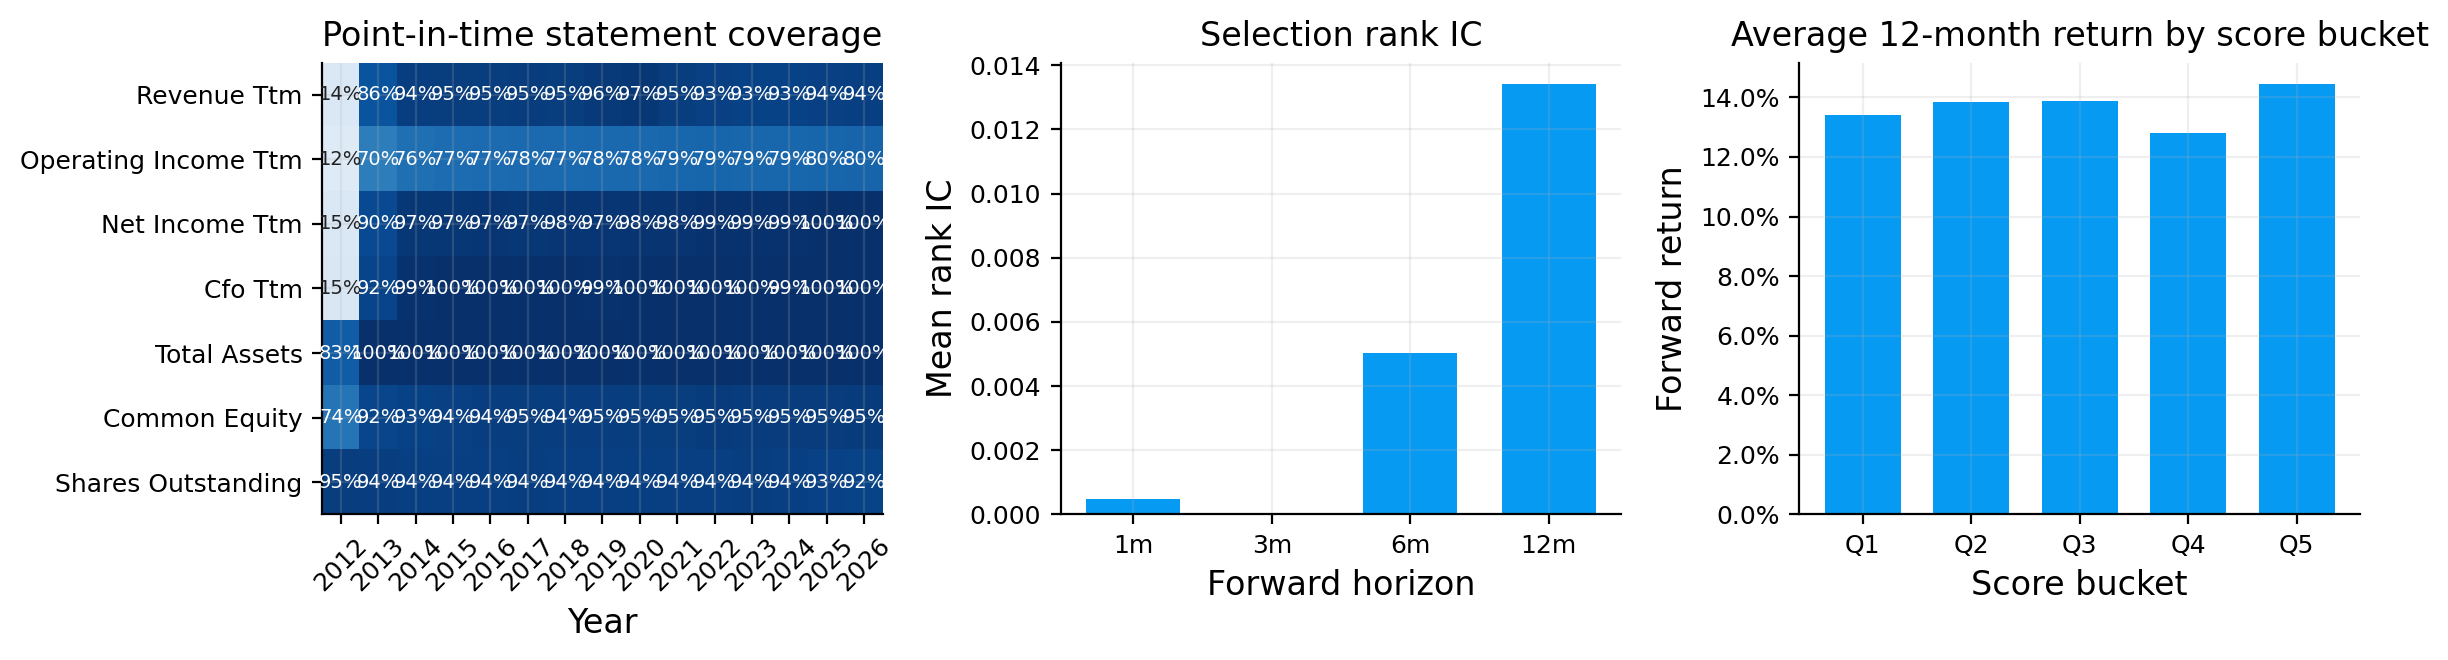

In [9]:
latest_selection_date = stock_selections["decision_date"].max()
latest_top15 = stock_selections[
    stock_selections["decision_date"].eq(latest_selection_date)
    & stock_selections["top_n"].eq(15)
].sort_values("selection_rank")
display(
    latest_top15[
        [
            "selection_rank",
            "ticker",
            "entity_name",
            "score_family",
            "industry",
            "market_cap",
            "final_score",
            "momentum_score",
            "selection_score",
        ]
    ].set_index("selection_rank")
    .style.format({
        "market_cap": "${:,.0f}",
        "final_score": "{:.1f}",
        "momentum_score": "{:.1f}",
        "selection_score": "{:.1f}",
    }).set_caption(f"Latest Top 15 · {latest_selection_date:%B %Y}")
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
fundamental_plots.plot_statement_coverage(
    statement_checks["coverage"],
    ax=axes[0],
)
fundamental_plots.plot_rank_ic(
    score_validation,
    score="selection_score",
    ax=axes[1],
)
fundamental_plots.plot_bucket_returns(
    bucket_returns,
    horizon=12,
    ax=axes[2],
)
plt.tight_layout()
plt.show()


## Forecast and state features


In [10]:
def _month_member_rows(market: pd.DataFrame, decision_dates: pd.DatetimeIndex) -> pd.DataFrame:
    rows = market[market['date'].isin(decision_dates) & market['is_sp500_member'].fillna(False)][['date', 'ticker', 'industry', 'market_cap']].copy()
    return rows.rename(columns={'date': 'decision_date'}).drop_duplicates(['decision_date', 'ticker'], keep='last').reset_index(drop=True)

def _wide_at_rows(panel: pd.DataFrame, member_rows: pd.DataFrame, name: str) -> pd.Series:
    long = panel.reindex(index=pd.DatetimeIndex(member_rows['decision_date'].unique())).rename_axis('decision_date').stack(future_stack=True).rename(name)
    long.index = long.index.set_names(['decision_date', 'ticker'])
    keys = pd.MultiIndex.from_frame(member_rows[['decision_date', 'ticker']])
    return long.reindex(keys).reset_index(drop=True)

def _future_stock_labels(prices: pd.DataFrame, returns: pd.DataFrame, spy_return: pd.Series, member_rows: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """Create labels only; these columns are never allowed into BL signals."""
    future_raw = prices.shift(-horizon).div(prices).sub(1.0)
    spy_future = (1.0 + spy_return.fillna(0.0)).rolling(horizon, min_periods=horizon).apply(np.prod, raw=True).shift(-horizon).sub(1.0)
    spy_variance = spy_return.rolling(189, min_periods=177).var()
    beta = returns.rolling(189, min_periods=177).cov(spy_return).div(spy_variance, axis=0)
    residual = future_raw.sub(beta.mul(spy_future, axis=0))
    idiosyncratic = returns.sub(beta.mul(spy_return, axis=0))
    idiosyncratic_sigma = idiosyncratic.rolling(189, min_periods=177).std(ddof=1).mul(np.sqrt(horizon))
    output = member_rows[['decision_date', 'ticker', 'industry']].copy()
    output[f'future_raw_{horizon}'] = _wide_at_rows(future_raw, member_rows, f'future_raw_{horizon}')
    output[f'future_market_residual_{horizon}'] = _wide_at_rows(residual, member_rows, f'future_market_residual_{horizon}')
    output[f'idio_sigma_{horizon}'] = _wide_at_rows(idiosyncratic_sigma, member_rows, f'idio_sigma_{horizon}')
    sector_median = output.groupby(['decision_date', 'industry'], dropna=False)[f'future_market_residual_{horizon}'].transform('median')
    output[f'future_sector_residual_{horizon}'] = output[f'future_market_residual_{horizon}'] - sector_median
    scaled = output[f'future_sector_residual_{horizon}'].div(output[f'idio_sigma_{horizon}'].replace(0.0, np.nan))
    output[f'target_{horizon}'] = scaled.groupby(output['decision_date']).rank(pct=True).mul(2.0).sub(1.0)
    price_index = pd.DatetimeIndex(prices.index)
    positions = price_index.searchsorted(pd.DatetimeIndex(output['decision_date']), side='left')
    label_positions = np.minimum(positions + int(horizon), len(price_index) - 1)
    label_end = pd.Series(price_index[label_positions], index=output.index)
    label_end[positions + int(horizon) >= len(price_index)] = pd.NaT
    output[f'label_end_{horizon}'] = label_end
    return output.drop(columns=['industry'])


In [11]:
def build_stock_research_table(
    market_bundle: mapping,
    etf_close: pd.DataFrame,
    fundamental_scores: pd.DataFrame,
    *,
    annualization,
    horizon,
) -> pd.DataFrame:
    """Build the stock forecast table from raw market data and in-memory scores."""
    market = market_bundle['market']
    prices = market_bundle['adj_close_filled'].astype(float)
    returns = market_bundle['returns'].astype(float)
    volume = market_bundle['volume'].astype(float)
    decision_dates = pd.DatetimeIndex(market_bundle['date_map']['decision_date'])
    members = _month_member_rows(market, decision_dates)
    spy_close = etf_close['SPY'].reindex(prices.index.union(etf_close.index)).sort_index().ffill().reindex(prices.index)
    spy_return = spy_close.pct_change(fill_method=None).fillna(0.0)
    panels: dict[str, pd.DataFrame] = {}
    for window in (5, 21, 42, 63, 126, 252):
        panels[f'return_{window}'] = total_return(prices, window)
    panels['momentum_6_1'] = skip_return(prices, 126, 21)
    panels['momentum_12_1'] = skip_return(prices, 252, 21)
    for window in (21, 63, 126, 189):
        panels[f'volatility_{window}'] = realized_vol(returns, window, annualization)
    panels['drawdown_126'] = drawdown_level(prices, 126)
    panels['drawdown_252'] = drawdown_level(prices, 252)
    panels['ma_distance_200'] = prices.div(prices.rolling(200, min_periods=126).mean()).sub(1.0)
    spy_variance = spy_return.rolling(189, min_periods=177).var()
    beta = returns.rolling(189, min_periods=177).cov(spy_return).div(spy_variance, axis=0)
    panels['beta_spy_189'] = beta
    panels['corr_spy_189'] = returns.rolling(189, min_periods=177).corr(spy_return)
    panels['residual_momentum_63'] = panels['return_63'].sub(beta.mul(total_return(spy_close, 63), axis=0))
    dollar_volume = prices.mul(volume)
    panels['log_dollar_volume_63'] = np.log1p(dollar_volume.rolling(63, min_periods=42).mean())
    features = members.copy()
    for name, panel in panels.items():
        features[name] = _wide_at_rows(panel, members, name)
    features['market_breadth_63'] = features['return_63'].gt(0.0).groupby(features['decision_date']).transform('mean')
    features['cross_sectional_dispersion_63'] = features.groupby('decision_date')['return_63'].transform('std')
    relative_columns = ['return_21', 'return_63', 'return_126', 'momentum_6_1', 'momentum_12_1', 'volatility_63', 'residual_momentum_63', 'log_dollar_volume_63']
    for column in relative_columns:
        features[f'rank_{column}'] = features.groupby('decision_date')[column].rank(pct=True)
        features[f'industry_relative_{column}'] = features[column] - features.groupby(['decision_date', 'industry'], dropna=False)[column].transform('median')
    score_columns = ['decision_date', 'ticker', 'selection_score', 'profitability_score', 'cash_or_stability_score', 'efficiency_score', 'valuation_score', 'severe_warning_count', 'warning_penalty']
    scores = fundamental_scores.loc[:, score_columns].copy()
    features = features.merge(
        scores,
        on=['decision_date', 'ticker'],
        how='left',
        validate='one_to_one',
    )
    labels = _future_stock_labels(prices, returns, spy_return, members, horizon)
    features = features.merge(labels, on=['decision_date', 'ticker'], how='left', validate='one_to_one')
    return features.sort_values(['decision_date', 'ticker']).reset_index(drop=True)


In [12]:
def build_state_research_table(
    etf_close: pd.DataFrame,
    etf_returns: pd.DataFrame,
    treasury: pd.DataFrame,
    stock_features: pd.DataFrame,
    macro: pd.DataFrame,
    nfci_raw: pd.DataFrame,
    *,
    annualization,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build leakage-safe state features and a reader-facing source audit."""
    macro_audit = macro_availability_table(macro).reset_index().rename(columns={'index': 'series'})
    macro_audit.insert(0, 'source', 'US macro factors')
    nfci_audit = macro_availability_table(nfci_raw).reset_index().rename(columns={'index': 'series'})
    nfci_audit.insert(0, 'source', 'Chicago Fed NFCI')
    source_audit = pd.concat([macro_audit, nfci_audit], ignore_index=True)
    nfci_visible = nfci_raw.shift(1)
    cross = build_cross_asset_feature_block(etf_close, etf_returns, assets=[asset for asset in etf_close.columns if asset != 'SPY'], cash_ticker='SHY', benchmark_ticker='SPY')
    fci = build_fci_feature_block(macro, nfci_visible, index=etf_close.index, release_lag_months=1)
    aligned_treasury = treasury.reindex(etf_close.index.union(treasury.index)).sort_index().ffill().reindex(etf_close.index)
    state_daily = pd.concat([cross, fci], axis=1)
    for tenor in ('3M', '2Y', '5Y', '10Y', '30Y'):
        if tenor in aligned_treasury:
            state_daily[f'treasury_{tenor.lower()}'] = aligned_treasury[tenor]
            state_daily[f'treasury_{tenor.lower()}_change_21'] = aligned_treasury[tenor].diff(21)
    if {'10Y', '2Y'}.issubset(aligned_treasury.columns):
        state_daily['curve_10y_2y'] = aligned_treasury['10Y'] - aligned_treasury['2Y']
    if {'10Y', '3M'}.issubset(aligned_treasury.columns):
        state_daily['curve_10y_3m'] = aligned_treasury['10Y'] - aligned_treasury['3M']
    state_daily['spy_vol_21'] = realized_vol(etf_returns['SPY'], 21, annualization)
    state_daily['spy_vol_63'] = realized_vol(etf_returns['SPY'], 63, annualization)
    state_daily['spy_drawdown_252'] = drawdown_level(etf_close['SPY'], 252)
    state_daily['dollar_return_63'] = total_return(etf_close['UUP'], 63)
    state_daily['gold_return_63'] = total_return(etf_close['GLD'], 63)
    state_daily['commodity_return_63'] = total_return(etf_close['DBC'], 63)
    stock_context = stock_features.groupby('decision_date')[['market_breadth_63', 'cross_sectional_dispersion_63']].first().sort_index()
    decision_dates = pd.DatetimeIndex(stock_context.index)
    state = state_daily.reindex(state_daily.index.union(decision_dates)).sort_index().ffill().reindex(decision_dates).join(stock_context, how='left')
    state.index.name = 'decision_date'
    state = state.reset_index()
    forbidden = [column for column in state if column.startswith(('future_', 'target_')) or column.endswith(('_21_forward', '_42_forward'))]
    assert not forbidden, f'forward outcomes entered state data: {forbidden}'
    return (state, source_audit)


In [13]:
market_bundle = {
    "market": market_data,
    "adj_close": adj_close,
    "adj_close_filled": adj_close_filled,
    "volume": volume,
    "returns": stock_returns,
    "date_map": signal_date_map,
}
stock_features = build_stock_research_table(
    market_bundle,
    etf_close,
    fundamental_scores,
    annualization=annualization,
    horizon=horizon,
)
stock_features["decision_date"] = pd.to_datetime(
    stock_features["decision_date"]
)
stock_features["label_end_42"] = pd.to_datetime(
    stock_features["label_end_42"]
)
state_research, state_source_audit = build_state_research_table(
    etf_close,
    etf_returns,
    treasury,
    stock_features,
    macro,
    nfci_raw,
    annualization=annualization,
)
top15_selections = stock_selections[
    stock_selections["top_n"].eq(15)
].copy()
top15_selections["decision_date"] = pd.to_datetime(
    top15_selections["decision_date"]
)
inputs = {
    "market": market_bundle,
    "stock_returns": stock_returns,
    "etf_close": etf_close,
    "etf_returns": etf_returns,
    "etf_volume": etf_volume,
    "treasury": treasury,
    "rf_daily": rf_daily,
    "stock_features": stock_features,
    "state_research": state_research,
    "macro_source_audit": macro_source_audit,
    "selections": top15_selections,
}
common_data_end = min(
    pd.Timestamp(stock_returns.index.max()),
    pd.Timestamp(etf_returns.index.max()),
)


In [14]:
def decision_map(inputs: mapping, *, signal_start) -> pd.DataFrame:
    dates = pd.DatetimeIndex(sorted(inputs['selections'].loc[inputs['selections']['decision_date'].ge(signal_start), 'decision_date'].unique()))
    mapping = inputs['market']['date_map'].copy()
    mapping['decision_date'] = pd.to_datetime(mapping['decision_date'])
    mapping['execution_date'] = pd.to_datetime(mapping['execution_date'])
    return mapping[mapping['decision_date'].isin(dates)].drop_duplicates('decision_date').sort_values('decision_date').reset_index(drop=True)

def return_panel_with_cash(inputs: mapping) -> pd.DataFrame:
    cached = inputs.get('_combined_return_panel')
    if cached is not None:
        return cached
    index = inputs['stock_returns'].index.union(inputs['etf_returns'].index).sort_values()
    common_data_end = min(pd.Timestamp(inputs['stock_returns'].index.max()), pd.Timestamp(inputs['etf_returns'].index.max()))
    index = index[index <= common_data_end]
    returns = inputs['stock_returns'].reindex(index).copy()
    for asset in inputs['etf_returns'].columns:
        if asset not in returns:
            returns[asset] = inputs['etf_returns'][asset].reindex(index)
    returns['CASH'] = inputs['rf_daily'].reindex(index).fillna(0.0)
    if isinstance(inputs, dict):
        inputs['_combined_return_panel'] = returns
    return returns
decision_dates = decision_map(inputs, signal_start=signal_start)['decision_date']

def top15_for_date(inputs: mapping, date: pd.Timestamp) -> pd.DataFrame:
    rows = inputs['selections'][inputs['selections']['decision_date'].eq(date)].copy()
    return rows.sort_values('selection_rank').head(15)


In [15]:
data_inventory = pd.DataFrame([{'dataset': 'S&P 500 market panel', 'first_date': inputs['stock_returns'].index.min(), 'last_date': inputs['stock_returns'].index.max(), 'observations': len(inputs['market']['market']), 'series_count': inputs['stock_returns'].shape[1], 'timing_rule': 'historical membership; decision-date snapshot'}, {'dataset': 'Cross-asset ETFs', 'first_date': inputs['etf_returns'].index.min(), 'last_date': inputs['etf_returns'].index.max(), 'observations': len(inputs['etf_returns']), 'series_count': inputs['etf_returns'].shape[1], 'timing_rule': 'close-to-close; monthly decision date'}, {'dataset': 'US macro factors', 'first_date': pd.to_datetime(inputs['macro_source_audit'].loc[inputs['macro_source_audit']['source'].eq('US macro factors'), 'first_date']).min(), 'last_date': pd.to_datetime(inputs['macro_source_audit'].loc[inputs['macro_source_audit']['source'].eq('US macro factors'), 'last_date']).max(), 'observations': int(inputs['macro_source_audit'].loc[inputs['macro_source_audit']['source'].eq('US macro factors'), 'observations'].max()), 'series_count': int(inputs['macro_source_audit']['source'].eq('US macro factors').sum()), 'timing_rule': 'one-month publication lag; latest-vintage caveat'}, {'dataset': 'Chicago Fed NFCI', 'first_date': pd.to_datetime(inputs['macro_source_audit'].loc[inputs['macro_source_audit']['source'].eq('Chicago Fed NFCI'), 'first_date']).min(), 'last_date': pd.to_datetime(inputs['macro_source_audit'].loc[inputs['macro_source_audit']['source'].eq('Chicago Fed NFCI'), 'last_date']).max(), 'observations': int(inputs['macro_source_audit'].loc[inputs['macro_source_audit']['source'].eq('Chicago Fed NFCI'), 'observations'].max()), 'series_count': int(inputs['macro_source_audit']['source'].eq('Chicago Fed NFCI').sum()), 'timing_rule': 'one monthly decision-row lag'}])
display(data_inventory)
print(f"stock features: {len(inputs['stock_features']):,} rows, {inputs['stock_features']['decision_date'].min().date()} to {inputs['stock_features']['decision_date'].max().date()}")
print(f'monthly decisions: {len(decision_dates)}, {decision_dates.min().date()} to {decision_dates.max().date()}')


,dataset,first_date,last_date,observations,series_count,timing_rule
0,S&P 500 market panel,2005-01-04,2026-07-31,3226676,666,historical membership; decision-date snapshot
1,Cross-asset ETFs,2005-01-04,2026-07-31,5427,37,close-to-close; monthly decision date
2,US macro factors,1990-01-31,2026-06-30,438,57,one-month publication lag; latest-vintage caveat
3,Chicago Fed NFCI,1971-01-31,2026-07-31,667,1,one monthly decision-row lag


stock features: 103,548 rows, 2005-01-31 to 2026-07-31
monthly decisions: 163, 2013-01-31 to 2026-07-31


## Forecast model


In [16]:
def add_safe_stock_features(data: pd.DataFrame) -> pd.DataFrame:
    output = data.copy()
    output['log_market_cap'] = np.log1p(pd.to_numeric(output['market_cap'], errors='coerce').clip(lower=0.0))
    score_columns = ['selection_score', 'profitability_score', 'cash_or_stability_score', 'efficiency_score', 'valuation_score']
    output['fundamental_score_average'] = output[score_columns].mean(axis=1, skipna=True)
    output['fundamental_score_minimum'] = output[score_columns].min(axis=1, skipna=True)
    output['warning_burden'] = pd.to_numeric(output['severe_warning_count'], errors='coerce').fillna(0.0) + pd.to_numeric(output['warning_penalty'], errors='coerce').fillna(0.0)
    return output

def lightgbm_forecaster(*, random_state) -> lgbm_regressor:
    return lgbm_regressor(objective='regression_l2', n_estimators=450, learning_rate=0.03, num_leaves=15, min_child_samples=50, colsample_bytree=0.7, subsample=0.85, reg_alpha=0.1, reg_lambda=1.0, max_depth=-1, random_state=random_state, n_jobs=-1, verbosity=-1)

def purged_quarterly_lightgbm_predictions(data: pd.DataFrame, *, horizon, random_state, s1_features, signal_start) -> tuple[pd.DataFrame, pd.DataFrame]:
    missing = sorted(set(s1_features).difference(data.columns))
    if missing:
        raise KeyError(f'missing fixed LightGBM features: {missing}')
    forbidden = [column for column in s1_features if column.startswith(('future_', 'target_', 'label_end_')) or column in {'decision_date', 'ticker', 'industry'}]
    if forbidden:
        raise AssertionError(f'forbidden LightGBM features: {forbidden}')
    features = data.loc[:, list(s1_features)].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
    dates = pd.DatetimeIndex(sorted(data.loc[data['decision_date'].ge(signal_start), 'decision_date'].unique()))
    refits = pd.DatetimeIndex(pd.Series(dates, index=dates.to_period('Q')).groupby(level=0).min().tolist())
    prediction_rows = []
    audit_rows = []
    for index, refit_date in enumerate(refits):
        next_refit = refits[index + 1] if index + 1 < len(refits) else dates.max() + pd.offsets.MonthEnd(1)
        prediction_dates = dates[(dates >= refit_date) & (dates < next_refit)]
        train_mask = data['label_end_42'].lt(refit_date) & data['target_42'].notna()
        test_mask = data['decision_date'].isin(prediction_dates)
        train_index = data.index[train_mask]
        test_index = data.index[test_mask]
        if len(train_index) < 5000 or len(test_index) == 0:
            continue
        estimator = clone(lightgbm_forecaster(random_state=random_state))
        estimator.fit(features.loc[train_index, list(s1_features)], data.loc[train_index, 'target_42'].astype(float))
        prediction = estimator.predict(features.loc[test_index, list(s1_features)])
        frame = data.loc[test_index, ['decision_date', 'ticker', 'label_end_42', 'target_42', 'future_raw_42', 'future_sector_residual_42']].copy()
        frame['forecast_score'] = prediction
        frame['forecast_horizon'] = horizon
        frame['model_refit_date'] = refit_date
        prediction_rows.append(frame)
        audit_rows.append({'refit_date': refit_date, 'training_start': data.loc[train_index, 'decision_date'].min(), 'training_target_end': data.loc[train_index, 'label_end_42'].max(), 'training_rows': len(train_index), 'prediction_rows': len(test_index), 'prediction_start': prediction_dates.min(), 'prediction_end': prediction_dates.max()})
    if not prediction_rows:
        raise RuntimeError('no quarterly LightGBM predictions were generated')
    predictions = pd.concat(prediction_rows, ignore_index=True)
    audit = pd.DataFrame(audit_rows)
    if not (audit['training_target_end'] < audit['refit_date']).all():
        raise AssertionError('quarterly LightGBM purge failed')
    return (predictions, audit)
inputs['stock_features'] = add_safe_stock_features(inputs['stock_features'])
raw_stock_forecasts, forecast_refit_audit = purged_quarterly_lightgbm_predictions(inputs['stock_features'], horizon=horizon, random_state=random_state, s1_features=s1_features, signal_start=signal_start)


In [17]:
def calibrate_forecast_distribution(raw: pd.DataFrame, feature_data: pd.DataFrame, *, horizon) -> pd.DataFrame:
    required = ['decision_date', 'ticker', 'label_end_42', 'idio_sigma_42', 'industry']
    data = raw.drop(columns=['label_end_42', 'industry'], errors='ignore').merge(feature_data[required].drop_duplicates(['decision_date', 'ticker']), on=['decision_date', 'ticker'], how='left', validate='one_to_one').sort_values(['decision_date', 'ticker']).reset_index(drop=True)
    output = []
    for date, current in data.groupby('decision_date', sort=True):
        current = current.copy()
        completed = data[data['label_end_42'].lt(date) & data['forecast_score'].notna() & data['future_sector_residual_42'].notna()].tail(30000)
        current_scale = current['idio_sigma_42'].clip(lower=0.02)
        if len(completed) < 1000:
            prediction = np.zeros(len(current), dtype=float)
            lower_deviation = -1.6 * current_scale.to_numpy(dtype=float)
            upper_deviation = 1.6 * current_scale.to_numpy(dtype=float)
        else:
            target = completed['future_sector_residual_42'].astype(float)
            lower, upper = target.quantile([0.01, 0.99])
            clipped_target = target.clip(lower=lower, upper=upper)
            model = ridge(alpha=10.0)
            model.fit(completed[['forecast_score']], clipped_target)
            fitted = model.predict(completed[['forecast_score']])
            prediction = model.predict(current[['forecast_score']])
            historical_scale = completed['idio_sigma_42'].clip(lower=0.02)
            standardized_error = (completed['future_sector_residual_42'].to_numpy(dtype=float) - fitted) / historical_scale.to_numpy(dtype=float)
            q_low, q_high = pd.Series(standardized_error).quantile([0.1, 0.9])
            lower_deviation = float(q_low) * current_scale.to_numpy(dtype=float)
            upper_deviation = float(q_high) * current_scale.to_numpy(dtype=float)
        current['mu_hat'] = prediction
        current['q10_deviation'] = lower_deviation
        current['q90_deviation'] = upper_deviation
        current['q10_total_recal'] = current['mu_hat'] + current['q10_deviation']
        current['q90_total_recal'] = current['mu_hat'] + current['q90_deviation']
        current['q50'] = current['mu_hat']
        current['forecast_width'] = current['q90_deviation'] - current['q10_deviation']
        monthly_median_width = max(float(current['forecast_width'].median()), 1e-06)
        current['forecast_confidence'] = (1.0 / (1.0 + current['forecast_width'].clip(lower=0.0) / monthly_median_width)).clip(0.05, 0.95)
        current['conservative_mu'] = current['mu_hat']
        current['forecast_uncertainty'] = current['forecast_width'] / 2.0
        current['forecast_horizon'] = horizon
        output.append(current)
    return pd.concat(output, ignore_index=True)
stock_forecasts = calibrate_forecast_distribution(raw_stock_forecasts, inputs['stock_features'], horizon=horizon)
inputs['stock_forecasts'] = stock_forecasts


In [18]:
completed_forecasts = stock_forecasts[stock_forecasts['decision_date'].ge(research_start) & stock_forecasts['target_42'].notna()].copy()
monthly_forecast_ic = completed_forecasts.groupby('decision_date').apply(lambda frame: frame['forecast_score'].corr(frame['target_42'], method='spearman'), include_groups=False).dropna()
completed_forecasts['forecast_bucket'] = np.ceil(completed_forecasts.groupby('decision_date')['forecast_score'].rank(pct=True, method='first') * 5.0).clip(1, 5).astype(int)
forecast_bucket_table = completed_forecasts.groupby('forecast_bucket').agg(observations=('ticker', 'size'), mean_sector_residual_42=('future_sector_residual_42', 'mean'), mean_raw_return_42=('future_raw_42', 'mean'))
forecast_quality = pd.Series({'mean monthly rank IC': monthly_forecast_ic.mean(), 'positive-IC month fraction': monthly_forecast_ic.gt(0.0).mean(), '2019–2022 rank IC': monthly_forecast_ic.loc['2019':'2022'].mean(), '2023–2026 rank IC': monthly_forecast_ic.loc['2023':'2026'].mean(), 'realized q10–q90 coverage': completed_forecasts['future_sector_residual_42'].between(completed_forecasts['q10_total_recal'], completed_forecasts['q90_total_recal']).mean()}, name='LightGBM forecast')
display(forecast_quality.to_frame().style.format('{:.3f}'))
display(forecast_bucket_table.style.format({'observations': '{:,.0f}', 'mean_sector_residual_42': '{:.3%}', 'mean_raw_return_42': '{:.3%}'}))
display(forecast_refit_audit.tail(12))


,LightGBM forecast
mean monthly rank IC,0.033
positive-IC month fraction,0.629
2019–2022 rank IC,0.032
2023–2026 rank IC,0.034
realized q10–q90 coverage,0.796


,observations,mean_sector_residual_42,mean_raw_return_42
forecast_bucket,,,
1,"8,318",-0.223%,2.424%
2,"8,362",0.007%,2.446%
3,"8,361",-0.075%,2.169%
4,"8,362",0.070%,2.294%
5,"8,393",0.266%,2.551%


,refit_date,training_start,training_target_end,training_rows,prediction_rows,prediction_start,prediction_end
43,2023-10-31,2006-05-31,2023-09-28,80627,1444,2023-10-31,2023-12-29
44,2024-01-31,2006-05-31,2024-01-02,82061,1448,2024-01-31,2024-03-28
45,2024-04-30,2006-05-31,2024-04-02,83497,1455,2024-04-30,2024-06-28
46,2024-07-31,2006-05-31,2024-07-01,84936,1462,2024-07-31,2024-09-30
47,2024-10-31,2006-05-31,2024-10-30,86865,1464,2024-10-31,2024-12-31
48,2025-01-31,2006-05-31,2025-01-02,87832,1467,2025-01-31,2025-03-31
49,2025-04-30,2006-05-31,2025-04-02,89288,1469,2025-04-30,2025-06-30
50,2025-07-31,2006-05-31,2025-07-01,90748,1483,2025-07-31,2025-09-30
51,2025-10-31,2006-05-31,2025-10-29,92710,1490,2025-10-31,2025-12-31
52,2026-01-30,2006-05-31,2026-01-02,93699,1498,2026-01-30,2026-03-31


## Forecast Mean-CVaR


In [19]:
def robust_zscore(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors='coerce')
    median = float(values.median()) if values.notna().any() else 0.0
    mad = float((values - median).abs().median())
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < 1e-10:
        scale = float(values.std(ddof=0))
    if not np.isfinite(scale) or scale < 1e-10:
        return pd.Series(0.0, index=values.index)
    return ((values.fillna(median) - median) / scale).clip(-3.0, 3.0)

def stock_snapshot(inputs: mapping, date: pd.Timestamp) -> pd.DataFrame:
    forecasts = inputs['stock_forecasts']
    features = inputs['stock_features']
    current_forecasts = forecasts[forecasts['decision_date'].eq(date)].copy()
    columns = ['decision_date', 'ticker', 'industry', 'market_cap', 'selection_score', 'profitability_score', 'cash_or_stability_score', 'efficiency_score', 'valuation_score', 'severe_warning_count', 'warning_penalty', 'residual_momentum_63', 'rank_log_dollar_volume_63', 'volatility_63', 'beta_spy_189']
    current_features = features.loc[features['decision_date'].eq(date), [column for column in columns if column in features]].copy()
    return current_forecasts.merge(current_features, on=['decision_date', 'ticker'], how='outer', validate='one_to_one')

def recent_forecast_skill(inputs: mapping, date: pd.Timestamp) -> float:
    forecasts = inputs['stock_forecasts']
    completed = forecasts[forecasts['label_end_42'].lt(date) & forecasts['decision_date'].ge(date - pd.DateOffset(months=18)) & forecasts['target_42'].notna()]
    monthly_ic = completed.groupby('decision_date').apply(lambda frame: frame['forecast_score'].corr(frame['target_42'], method='spearman'), include_groups=False).dropna().tail(12)
    return float(np.clip(0.5 + 3.0 * monthly_ic.mean(), 0.35, 0.8)) if not monthly_ic.empty else 0.5

def conservative_stock_signal(inputs: mapping, date: pd.Timestamp, snapshot: pd.DataFrame) -> pd.Series:
    table = snapshot.drop_duplicates('ticker').set_index('ticker')
    direction = 0.7 * robust_zscore(table['forecast_score']) + 0.3 * robust_zscore(table['mu_hat'])
    interval_confidence = pd.to_numeric(table['forecast_confidence'], errors='coerce').fillna(0.0)
    model_confidence = pd.Series(recent_forecast_skill(inputs, date), index=table.index)
    neutral_state_confidence = pd.Series(0.5, index=table.index)
    adjusted = confidence_adjusted_mu(direction, interval_confidence, model_confidence, neutral_state_confidence, floor=0.5, cap=1.0)
    return robust_zscore(adjusted)

def estimate_strategy1_covariance(window: pd.DataFrame, *, annualization) -> pd.DataFrame:
    return estimate_covariance(window, method='LedoitWolf', annualization=annualization, return_df=True)

def stock_expected_returns(inputs: mapping, date: pd.Timestamp, window: pd.DataFrame, snapshot: pd.DataFrame, *, neutral: bool=False, annualization, s1_architecture) -> pd.Series:
    covariance = estimate_strategy1_covariance(window, annualization=annualization)
    rf_window = inputs['rf_daily'].reindex(window.index).fillna(0.0)
    prior = bayes_stein_mu(window, rf_daily=rf_window, cov_ann=covariance, return_series=True)
    if neutral:
        forecast_mu = pd.Series(0.0, index=window.columns)
        forecast_weight = 0.0
    else:
        signal = conservative_stock_signal(inputs, date, snapshot).reindex(window.columns).fillna(0.0)
        forecast_mu = pd.Series(build_scaled_mu_from_raw(signal.to_numpy(dtype=float), covariance, target_sharpe_ann=s1_architecture['forecast_target_sharpe'], mu_cap_ann=s1_architecture['forecast_mu_cap']), index=window.columns)
        forecast_weight = s1_architecture['forecast_weight']
    return s1_architecture['prior_weight'] * prior.reindex(window.columns).fillna(0.0) + forecast_weight * forecast_mu.reindex(window.columns).fillna(0.0)

def choose_short_candidates(inputs: mapping, date: pd.Timestamp, long_tickers: sequence[str], *, s1_architecture, s1_parameters) -> pd.DataFrame:
    snapshot = stock_snapshot(inputs, date)
    if snapshot['ticker'].duplicated().any():
        raise AssertionError(f'duplicate stock snapshot at {date:%Y-%m-%d}')
    large_cap = snapshot.dropna(subset=['market_cap']).sort_values(['market_cap', 'ticker'], ascending=[False, True]).head(200).copy()
    eligible = large_cap[~large_cap['ticker'].isin(long_tickers) & large_cap['forecast_score'].notna() & large_cap['residual_momentum_63'].notna() & large_cap['selection_score'].notna() & large_cap['rank_log_dollar_volume_63'].ge(0.2)].copy()
    quality = [robust_zscore(eligible[column]) for column in ('selection_score', 'profitability_score', 'cash_or_stability_score', 'efficiency_score', 'valuation_score')]
    eligible['fundamental_composite'] = 0.4 * quality[0] + 0.2 * quality[1] + 0.15 * quality[2] + 0.1 * quality[3] + 0.05 * quality[4] - 0.06 * robust_zscore(eligible['severe_warning_count']) - 0.04 * robust_zscore(eligible['warning_penalty'])
    eligible['fundamental_rank'] = eligible['fundamental_composite'].rank(pct=True, method='average')
    eligible['forecast_rank'] = eligible['forecast_score'].rank(pct=True, method='average')
    eligible['momentum_rank'] = eligible['residual_momentum_63'].rank(pct=True, method='average')
    eligible['short_score'] = 1.0 - eligible['fundamental_rank']
    selected = eligible[eligible['momentum_rank'].le(s1_architecture['short_momentum_gate'])].nlargest(s1_parameters['short_candidates'], 'short_score')
    if len(selected) != s1_parameters['short_candidates']:
        raise RuntimeError(f"short selector found {len(selected)} rather than {s1_parameters['short_candidates']} names at {date:%Y-%m-%d}")
    spy = pd.DataFrame([{'decision_date': date, 'ticker': 'SPY', 'short_score': np.inf}])
    return pd.concat([selected, spy], ignore_index=True)


In [20]:
def covariance_shrink_scenarios(scenarios: pd.DataFrame, intensity: float) -> pd.DataFrame:
    if intensity <= 0.0 or len(scenarios) < scenarios.shape[1] + 5:
        return scenarios
    centered = scenarios - scenarios.mean()
    sample = np.cov(centered.to_numpy(dtype=float), rowvar=False, ddof=1)
    target = ledoit_wolf().fit(centered.to_numpy(dtype=float)).covariance_
    blended = (1.0 - intensity) * sample + intensity * target

    def psd_root(matrix: np.ndarray, inverse: bool) -> np.ndarray:
        eigenvalues, eigenvectors = np.linalg.eigh((matrix + matrix.T) / 2.0)
        eigenvalues = np.clip(eigenvalues, 1e-10, None)
        roots = 1.0 / np.sqrt(eigenvalues) if inverse else np.sqrt(eigenvalues)
        return eigenvectors * roots @ eigenvectors.T
    transform = psd_root(sample, True) @ psd_root(blended, False)
    adjusted = centered.to_numpy(dtype=float) @ transform
    return pd.DataFrame(adjusted + scenarios.mean().to_numpy(dtype=float), index=scenarios.index, columns=scenarios.columns)

def filtered_historical_scenarios(daily_returns: pd.DataFrame, historical_volatility: pd.DataFrame, *, current_volatility: pd.Series, forecast_rows: pd.DataFrame, long_assets: sequence[str], short_assets: sequence[str], neutral: bool=False, horizon, s1_architecture, s1_parameters) -> pd.DataFrame:
    raw = daily_returns.copy().fillna(0.0)
    historical_volatility = historical_volatility.reindex_like(raw)
    standardized = raw.div(historical_volatility.clip(lower=0.002)).clip(-8.0, 8.0)
    adjusted_daily = standardized.mul(current_volatility.reindex(raw.columns).clip(lower=0.002), axis=1)
    generated = np.expm1(np.log1p(adjusted_daily.clip(lower=-0.95)).rolling(horizon).sum()).dropna(how='any')
    if generated.empty:
        generated = raw.tail(max(60, horizon)).copy()
    generated = covariance_shrink_scenarios(generated, s1_parameters['covariance_shrinkage'])
    forecast = forecast_rows.drop_duplicates('ticker').set_index('ticker')
    shifted = generated.copy()
    for asset in shifted:
        historical_mean = float(shifted[asset].mean())
        scenario_forecast_mean = 0.0
        if asset in forecast.index:
            forecast_horizon = float(forecast.at[asset, 'forecast_horizon'])
            scenario_forecast_mean = float(forecast.at[asset, 'mu_hat']) * horizon / max(forecast_horizon, 1.0)
        target_mean = historical_mean + (0.0 if neutral else s1_architecture['scenario_mean_shift'] * scenario_forecast_mean)
        deviations = shifted[asset] - historical_mean
        target_width = np.nan
        side = pd.Series(False, index=deviations.index)
        if not neutral and asset in forecast.index and (asset in long_assets):
            target_width = abs(float(forecast.at[asset, 'q10_deviation']))
            side = deviations.lt(0.0)
            empirical_width = abs(float(deviations.quantile(0.1)))
        elif not neutral and asset in forecast.index and (asset in short_assets) and (asset != 'SPY'):
            target_width = abs(float(forecast.at[asset, 'q90_deviation']))
            side = deviations.gt(0.0)
            empirical_width = abs(float(deviations.quantile(0.9)))
        else:
            empirical_width = np.nan
        if np.isfinite(target_width):
            forecast_horizon = float(forecast.at[asset, 'forecast_horizon'])
            target_width *= math.sqrt(horizon / max(forecast_horizon, 1.0))
        if np.isfinite(target_width) and np.isfinite(empirical_width) and (empirical_width > 1e-08):
            ratio = float(np.clip(target_width / empirical_width, 0.5, 2.5))
            deviations.loc[side] *= 1.0 + s1_parameters['tail_strength'] * (ratio - 1.0)
        shifted[asset] = target_mean + deviations
    return shifted

def exponential_scenario_probabilities(scenario_dates: pd.DatetimeIndex, *, s1_parameters) -> np.ndarray:
    age = np.arange(len(scenario_dates) - 1, -1, -1, dtype=float)
    weights = np.exp(-np.log(2.0) * age / s1_parameters['half_life'])
    weights = np.clip(weights, 1e-12, None)
    return weights / weights.sum()


In [21]:
def joint_mean_cvar_weights(scenarios: pd.DataFrame, expected_returns: pd.Series, *, long_assets: sequence[str], short_assets: sequence[str], scenario_weights: sequence[float], previous_weights: pd.Series | None, s1_architecture, s1_parameters) -> pd.Series:
    raw = pd.DataFrame(scenarios).replace([np.inf, -np.inf], np.nan)
    valid = raw.notna().all(axis=1)
    frame = raw.loc[valid]
    assets = list(frame.columns)
    longs = [asset for asset in long_assets if asset in assets]
    shorts = [asset for asset in short_assets if asset in assets and asset not in longs]
    stock_shorts = [asset for asset in shorts if asset != 'SPY']
    long_index = [assets.index(asset) for asset in longs]
    short_index = [assets.index(asset) for asset in stock_shorts]
    spy_index = assets.index('SPY') if 'SPY' in shorts else None
    cash_index = assets.index('CASH')
    probabilities = np.asarray(scenario_weights, dtype=float)[valid.to_numpy()]
    probabilities = np.clip(probabilities, 1e-12, None)
    probabilities /= probabilities.sum()
    previous = pd.Series(0.0, index=assets) if previous_weights is None else previous_weights.reindex(assets).fillna(0.0)
    expected = expected_returns.reindex(assets).fillna(0.0).to_numpy(dtype=float)
    long_floor = float(s1_architecture['long_floor'])
    long_cap = float(s1_architecture['long_cap'])
    stock_short_cap = min(float(s1_architecture['stock_short_cap']), float(s1_parameters['maximum_individual_short']))
    weights = cp.Variable(len(assets))
    eta = cp.Variable()
    slack = cp.Variable(len(frame), nonneg=True)
    losses = -frame.to_numpy(dtype=float) @ weights
    cvar = eta + cp.sum(cp.multiply(probabilities, slack)) / (1.0 - s1_parameters['alpha'])
    objective_expression = s1_parameters['forecast_strength'] * expected @ weights - s1_parameters['cvar_penalty'] * cvar - s1_architecture['turnover_penalty_bps'] / 10000.0 * cp.norm1(weights - previous.to_numpy(dtype=float))
    risky_gross = cp.sum(weights[long_index])
    if short_index:
        risky_gross -= cp.sum(weights[short_index])
    if spy_index is not None:
        risky_gross -= weights[spy_index]
    constraints = [cp.sum(weights) == 1.0, slack >= losses - eta, weights[long_index] >= long_floor, weights[long_index] <= long_cap, cp.sum(weights[long_index]) >= s1_parameters['long_gross_min'], cp.sum(weights[long_index]) <= s1_architecture['long_gross_max'], weights[cash_index] >= 0.0, weights[cash_index] <= s1_architecture['cash_cap'], risky_gross <= s1_architecture['gross_leverage_cap']]
    if short_index:
        constraints.extend([weights[short_index] <= 0.0, weights[short_index] >= -stock_short_cap, -cp.sum(weights[short_index]) <= s1_parameters['short_gross_max'], -cp.sum(weights[short_index]) >= s1_parameters['short_gross_min']])
    if spy_index is not None:
        constraints.extend([weights[spy_index] <= 0.0, weights[spy_index] >= -s1_architecture['spy_hedge_cap']])
    allowed = set(long_index + short_index + ([spy_index] if spy_index is not None else []) + [cash_index])
    unused = [index for index in range(len(assets)) if index not in allowed]
    if unused:
        constraints.append(weights[unused] == 0.0)
    frame_values = frame.to_numpy(dtype=float)
    weight_tolerance = 5e-07
    cvar_tolerance = 5e-07
    optimality_tolerance = 2e-06

    def positive_max(values) -> float:
        array = np.asarray(values, dtype=float).reshape(-1)
        if array.size == 0:
            return 0.0
        if not np.isfinite(array).all():
            return np.inf
        return max(float(array.max()), 0.0)

    def postcheck(weight_values, eta_value, slack_values, solver_objective) -> dict:
        vector = np.asarray(weight_values, dtype=float).reshape(-1)
        slack_array = np.asarray(slack_values, dtype=float).reshape(-1)
        if len(vector) != len(assets) or len(slack_array) != len(frame) or (not np.isfinite(vector).all()) or (not np.isfinite(slack_array).all()) or (not np.isfinite(float(eta_value))):
            return {'pass': False, 'max_violation': np.inf, 'max_weight_violation': np.inf, 'max_cvar_violation': np.inf, 'optimized_cvar': np.nan, 'exact_cvar': np.nan, 'cvar_gap': np.inf, 'solver_objective': np.nan, 'exact_objective': np.nan, 'objective_gap': np.inf, 'violations': {'nonfinite_or_wrong_shape': np.inf}}
        long_values = vector[long_index]
        short_values = vector[short_index]
        spy_value = float(vector[spy_index]) if spy_index is not None else 0.0
        cash_value = float(vector[cash_index])
        long_gross = float(long_values.sum())
        stock_short_gross = float(-short_values.sum())
        exact_risky_gross = long_gross + stock_short_gross - spy_value
        violations = {'budget': abs(float(vector.sum()) - 1.0), 'long_floor': positive_max(long_floor - long_values), 'long_cap': positive_max(long_values - long_cap), 'long_gross_min': max(s1_parameters['long_gross_min'] - long_gross, 0.0), 'long_gross_max': max(long_gross - s1_architecture['long_gross_max'], 0.0), 'short_sign': positive_max(short_values), 'short_name_cap': positive_max(-stock_short_cap - short_values), 'short_gross_min': max(s1_parameters['short_gross_min'] - stock_short_gross, 0.0), 'short_gross_max': max(stock_short_gross - s1_parameters['short_gross_max'], 0.0), 'spy_sign': max(spy_value, 0.0), 'spy_cap': max(-spy_value - s1_architecture['spy_hedge_cap'], 0.0), 'cash_floor': max(-cash_value, 0.0), 'cash_cap': max(cash_value - s1_architecture['cash_cap'], 0.0), 'risky_gross_cap': max(exact_risky_gross - s1_architecture['gross_leverage_cap'], 0.0), 'unused_zero': positive_max(np.abs(vector[unused])) if unused else 0.0}
        loss_values = -frame_values @ vector
        violations['slack_nonnegative'] = positive_max(-slack_array)
        violations['cvar_epigraph'] = positive_max(loss_values - float(eta_value) - slack_array)
        optimized_cvar = float(float(eta_value) + np.dot(probabilities, slack_array) / (1.0 - s1_parameters['alpha']))
        eta_candidates = np.unique(loss_values)
        candidate_cvar = eta_candidates + np.maximum(loss_values[None, :] - eta_candidates[:, None], 0.0) @ probabilities / (1.0 - s1_parameters['alpha'])
        exact_cvar = float(candidate_cvar.min())
        cvar_gap = abs(optimized_cvar - exact_cvar)
        exact_objective = float(s1_parameters['forecast_strength'] * np.dot(expected, vector) - s1_parameters['cvar_penalty'] * exact_cvar - s1_architecture['turnover_penalty_bps'] / 10000.0 * np.abs(vector - previous.to_numpy(dtype=float)).sum())
        solver_objective = float(solver_objective)
        objective_gap = abs(solver_objective - exact_objective)
        weight_violations = [value for name, value in violations.items() if name not in {'slack_nonnegative', 'cvar_epigraph'}]
        max_weight_violation = max(weight_violations, default=0.0)
        max_cvar_violation = max(violations['slack_nonnegative'], violations['cvar_epigraph'])
        return {'pass': bool(max_weight_violation <= weight_tolerance and max_cvar_violation <= cvar_tolerance and (cvar_gap <= optimality_tolerance) and (objective_gap <= optimality_tolerance)), 'max_violation': max(max_weight_violation, max_cvar_violation), 'max_weight_violation': max_weight_violation, 'max_cvar_violation': max_cvar_violation, 'optimized_cvar': optimized_cvar, 'exact_cvar': exact_cvar, 'cvar_gap': cvar_gap, 'solver_objective': solver_objective, 'exact_objective': exact_objective, 'objective_gap': objective_gap, 'violations': violations}

    def certified_result(vector: pd.Series, solver_name: str, status: str, audit: mapping, attempts: sequence[mapping], *, agreement: bool) -> pd.Series:
        vector.attrs.update({'solver_status': status, 'solver_raw_status': status, 'solver_name': solver_name, 'solver_attempt_count': len(attempts) + 1, 'solver_rejected_attempt_count': len(attempts), 'solver_rejected_attempts': json.dumps(list(attempts), sort_keys=True, default=str), 'solver_second_solver_agreement_obtained': agreement, 'solution_postcheck_pass': bool(audit['pass']), 'constraint_max_violation': float(audit['max_violation']), 'constraint_weight_max_violation': float(audit['max_weight_violation']), 'constraint_cvar_max_violation': float(audit['max_cvar_violation']), 'constraint_violations': json.dumps(audit['violations'], sort_keys=True), 'optimized_cvar': float(audit['optimized_cvar']), 'exact_fixed_weight_cvar': float(audit['exact_cvar']), 'cvar_optimality_gap': float(audit['cvar_gap']), 'solver_objective_value': float(audit['solver_objective']), 'recomputed_exact_objective_value': float(audit['exact_objective']), 'objective_recomputation_gap': float(audit['objective_gap'])})
        return vector
    solver_specs = (('CLARABEL', {'max_iter': 1000, 'tol_gap_abs': 1e-09, 'tol_gap_rel': 1e-09, 'tol_feas': 1e-09}), ('OSQP', {'max_iter': 50000, 'eps_abs': 1e-08, 'eps_rel': 1e-08, 'polishing': True}), ('SCS', {'max_iters': 25000, 'eps': 1e-06}))
    installed = set(cp.installed_solvers())
    problem = cp.Problem(cp.Maximize(objective_expression), constraints)
    rejected = []
    inaccurate = []

    def solve_original(*, warm_start: bool) -> pd.Series | None:
        for solver_name, options in solver_specs:
            if solver_name not in installed:
                continue
            label = f'{solver_name}:warm_start' if warm_start else solver_name
            try:
                problem.solve(solver=solver_name, verbose=False, warm_start=warm_start, **options)
            except Exception as error:
                rejected.append({'solver': label, 'status': 'exception', 'error': type(error).__name__})
                continue
            status = str(problem.status)
            if weights.value is None or eta.value is None or slack.value is None or (status not in {'optimal', 'optimal_inaccurate'}):
                rejected.append({'solver': label, 'status': status, 'reason': 'no acceptable primal'})
                continue
            vector = pd.Series(np.asarray(weights.value).reshape(-1), index=assets)
            vector[vector.abs() < 1e-10] = 0.0
            audit = postcheck(vector.to_numpy(dtype=float), eta.value, slack.value, problem.value)
            if not audit['pass']:
                rejected.append({'solver': label, 'status': status, 'reason': 'numeric postcheck failed', 'max_violation': audit['max_violation'], 'cvar_gap': audit['cvar_gap'], 'objective_gap': audit['objective_gap']})
                continue
            if status == 'optimal':
                return certified_result(vector, label, status, audit, rejected, agreement=False)
            for prior in inaccurate:
                if prior['solver'] == solver_name:
                    continue
                weight_gap = float(np.max(np.abs(vector.to_numpy(dtype=float) - prior['weights'])))
                cvar_gap = abs(audit['exact_cvar'] - prior['audit']['exact_cvar'])
                objective_gap = abs(audit['exact_objective'] - prior['audit']['exact_objective'])
                if weight_gap <= 0.0001 and cvar_gap <= optimality_tolerance and (objective_gap <= optimality_tolerance):
                    return certified_result(vector, f"{label}|agreement:{prior['label']}", status, audit, rejected, agreement=True)
            inaccurate.append({'solver': solver_name, 'label': label, 'weights': vector.to_numpy(dtype=float).copy(), 'audit': audit})
        return None
    accepted = solve_original(warm_start=False)
    if accepted is not None:
        return accepted
    seed = pd.Series(0.0, index=assets)
    seed_long = s1_parameters['long_gross_min'] / len(longs)
    if not long_floor <= seed_long <= long_cap:
        raise RuntimeError('deterministic Mean-CVaR seed is infeasible')
    seed.loc[longs] = seed_long
    seed['CASH'] = 1.0 - float(seed.sum())
    seed_losses = -frame_values @ seed.to_numpy(dtype=float)
    weights.value = seed.to_numpy(dtype=float)
    eta.value = float(seed_losses.max())
    slack.value = np.zeros(len(frame), dtype=float)
    accepted = solve_original(warm_start=True)
    if accepted is not None:
        return accepted
    raise RuntimeError('Mean-CVaR failed closed: no original-objective solution passed independent constraint/CVaR/objective recertification.')


In [22]:
def build_strategy1_weights(inputs: mapping, forecasts: pd.DataFrame, *, neutral: bool, annualization, horizon, research_end, research_start, s1_architecture, s1_parameters, signal_start, forecast_refit_audit) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    inputs['stock_forecasts'] = forecasts
    returns = return_panel_with_cash(inputs)
    historical_volatility = returns.drop(columns=['CASH'], errors='ignore').rolling(63, min_periods=42).std(ddof=1).shift(1)
    dates = decision_map(inputs, signal_start=signal_start)['decision_date']
    dates = dates[dates.between(research_start, research_end)]
    refit_audit = forecast_refit_audit.set_index('refit_date')
    rows = {}
    diagnostics = []
    native_rows = []
    previous = None
    for date in dates:
        selection = top15_for_date(inputs, date)
        longs = [ticker for ticker in selection['ticker'].astype(str) if ticker in returns.columns]
        short_frame = choose_short_candidates(inputs, date, longs, s1_architecture=s1_architecture, s1_parameters=s1_parameters)
        shorts = [ticker for ticker in short_frame['ticker'].astype(str) if ticker in returns.columns and ticker not in longs]
        assets = list(dict.fromkeys([*longs, *shorts]))
        window = returns.loc[:date, assets].tail(s1_parameters['lookback'])
        valid = window.notna().sum().ge(s1_parameters['lookback'] - 12)
        window = window.loc[:, valid].fillna(0.0)
        longs = [asset for asset in longs if asset in window]
        shorts = [asset for asset in shorts if asset in window]
        stock_short_assets = [asset for asset in shorts if asset != 'SPY']
        if len(longs) != 15:
            raise RuntimeError(f'expected all 15 Top-15 longs, found {len(longs)} at {date:%Y-%m-%d}')
        if len(stock_short_assets) != s1_parameters['short_candidates'] or 'SPY' not in shorts:
            raise RuntimeError(f'expected 25 stock shorts plus SPY at {date:%Y-%m-%d}')
        assets = [*longs, *shorts]
        window = window.reindex(columns=assets)
        snapshot = stock_snapshot(inputs, date)
        annual_mu = stock_expected_returns(inputs, date, window, snapshot[snapshot['ticker'].isin(assets)], neutral=neutral, annualization=annualization, s1_architecture=s1_architecture)
        expected_horizon = annual_mu * horizon / annualization
        forecast_rows = forecasts[forecasts['decision_date'].eq(date) & forecasts['ticker'].isin(assets)]
        current_volatility = returns.loc[:date, assets].tail(63).std(ddof=1).fillna(window.std(ddof=1))
        scenarios = filtered_historical_scenarios(window, historical_volatility.reindex(index=window.index, columns=assets), current_volatility=current_volatility, forecast_rows=forecast_rows, long_assets=longs, short_assets=shorts, neutral=neutral, horizon=horizon, s1_architecture=s1_architecture, s1_parameters=s1_parameters)
        cash_return = float(np.expm1(horizon * np.log1p(inputs['rf_daily'].loc[:date].tail(21).fillna(0.0).mean())))
        scenarios['CASH'] = cash_return
        expected_horizon['CASH'] = cash_return
        probabilities = exponential_scenario_probabilities(pd.DatetimeIndex(scenarios.index), s1_parameters=s1_parameters)
        weights = joint_mean_cvar_weights(scenarios, expected_horizon, long_assets=longs, short_assets=shorts, scenario_weights=probabilities, previous_weights=previous, s1_architecture=s1_architecture, s1_parameters=s1_parameters)
        rows[pd.Timestamp(date)] = weights
        previous_aligned = pd.Series(0.0, index=weights.index) if previous is None else previous.reindex(weights.index).fillna(0.0)
        turnover = 0.5 * float((weights - previous_aligned).abs().sum() + (0.0 if previous is None else previous.drop(index=weights.index, errors='ignore').abs().sum()))
        long_weights = weights.reindex(longs).fillna(0.0)
        long_gross = float(long_weights.sum())
        stock_short_gross = float(-weights.reindex(stock_short_assets).fillna(0.0).sum())
        spy_short_gross = float(-min(float(weights.get('SPY', 0.0)), 0.0))
        risky_gross = long_gross + stock_short_gross + spy_short_gross
        normalized_long = long_weights / max(long_gross, 1e-12)
        financing_error = float(long_gross + float(weights.get('CASH', 0.0)) - stock_short_gross - spy_short_gross - 1.0)
        forecast_weight_correlation = forecast_rows.drop_duplicates('ticker').set_index('ticker')['forecast_score'].reindex(longs).corr(long_weights, method='spearman')
        diagnostics.append({'decision_date': date, 'long_count': len(longs), 'long_source_count': 15, 'long_forecast_gate': 'none', 'short_candidates': len(shorts), 'allowed_long_assets': json.dumps(longs), 'allowed_stock_short_assets': json.dumps(stock_short_assets), 'spy_hedge_allowed': 'SPY' in shorts, 'certified_long_floor': s1_architecture['long_floor'], 'certified_long_cap': s1_architecture['long_cap'], 'certified_effective_stock_short_cap': s1_architecture['stock_short_cap'], 'certified_short_gross_min': s1_parameters['short_gross_min'], 'certified_short_gross_max': s1_parameters['short_gross_max'], 'certified_long_gross_min': s1_parameters['long_gross_min'], 'certified_long_gross_max': s1_architecture['long_gross_max'], 'certified_gross_leverage_cap': s1_architecture['gross_leverage_cap'], 'certified_cash_cap': s1_architecture['cash_cap'], 'certified_spy_hedge_cap': s1_architecture['spy_hedge_cap'], 'long_gross': long_gross, 'active_long_count': int(long_weights.gt(1e-06).sum()), 'long_hhi': float(normalized_long.pow(2).sum()), 'effective_long_count': float(1.0 / max(normalized_long.pow(2).sum(), 1e-12)), 'minimum_long_weight': float(long_weights.min()), 'maximum_long_weight': float(long_weights.max()), 'stock_short_gross': stock_short_gross, 'maximum_individual_stock_short': float(-weights.reindex(stock_short_assets).fillna(0.0).clip(upper=0.0).min()), 'spy_short_gross': spy_short_gross, 'risky_gross': risky_gross, 'cash': float(weights.get('CASH', 0.0)), 'financing_identity_error': financing_error, 'one_way_turnover': turnover, 'forecast_weight_rank_correlation': float(forecast_weight_correlation), 'solver_status': weights.attrs['solver_status'], 'solver_raw_status': weights.attrs['solver_raw_status'], 'solver_name': weights.attrs['solver_name'], 'solver_attempt_count': weights.attrs['solver_attempt_count'], 'solver_rejected_attempt_count': weights.attrs['solver_rejected_attempt_count'], 'solver_second_solver_agreement_obtained': weights.attrs['solver_second_solver_agreement_obtained'], 'solution_postcheck_pass': weights.attrs['solution_postcheck_pass'], 'constraint_max_violation': weights.attrs['constraint_max_violation'], 'constraint_weight_max_violation': weights.attrs['constraint_weight_max_violation'], 'constraint_cvar_max_violation': weights.attrs['constraint_cvar_max_violation'], 'constraint_violations': weights.attrs['constraint_violations'], 'optimized_cvar': weights.attrs['optimized_cvar'], 'exact_fixed_weight_cvar': weights.attrs['exact_fixed_weight_cvar'], 'cvar_optimality_gap': weights.attrs['cvar_optimality_gap'], 'solver_objective_value': weights.attrs['solver_objective_value'], 'recomputed_exact_objective_value': weights.attrs['recomputed_exact_objective_value'], 'objective_recomputation_gap': weights.attrs['objective_recomputation_gap'], 'neutral_control': neutral})
        if not neutral:
            return_dates = pd.DatetimeIndex(returns.index)
            execution_position = int(return_dates.searchsorted(date, side='right'))
            execution_date = (
                pd.NaT
                if execution_position >= len(return_dates)
                else pd.Timestamp(return_dates[execution_position])
            )
            current_forecast = forecast_rows.drop_duplicates('ticker').set_index('ticker')
            model_refit_date = pd.Timestamp(current_forecast['model_refit_date'].iloc[0])
            training_target_end = pd.Timestamp(refit_audit.at[model_refit_date, 'training_target_end'])
            for side, side_assets in (('long', longs), ('short', stock_short_assets)):
                for asset in side_assets:
                    forecast = current_forecast.loc[asset]
                    native_rows.append({'decision_date': date, 'execution_date': execution_date, 'information_cutoff': date, 'training_target_end': training_target_end, 'asset': asset, 'candidate_side': side, 'expected_return': float(forecast['mu_hat']), 'forecast_uncertainty': float(forecast['forecast_uncertainty']), 'forecast_horizon_days': int(forecast['forecast_horizon']), 'forecast_score': float(forecast['forecast_score']), 'q10_expected_return': float(forecast['q10_total_recal']), 'q90_expected_return': float(forecast['q90_total_recal']), 'optimizer_blended_expected_return_ann': float(annual_mu.get(asset, np.nan)), 'selected_weight': float(weights.get(asset, 0.0)), 'model_refit_date': model_refit_date})
        previous = weights
    weight_frame = pd.DataFrame.from_dict(rows, orient='index').fillna(0.0)
    weight_frame.index = pd.DatetimeIndex(pd.to_datetime(weight_frame.index), name='decision_date')
    weight_frame = weight_frame.sort_index()
    diagnostic_frame = pd.DataFrame(diagnostics)
    diagnostic_frame['decision_date'] = pd.to_datetime(diagnostic_frame['decision_date'])
    diagnostic_frame = diagnostic_frame.sort_values('decision_date').reset_index(drop=True)
    native_frame = pd.DataFrame(native_rows)
    if not native_frame.empty:
        native_frame['decision_date'] = pd.to_datetime(native_frame['decision_date'])
        native_frame = native_frame.sort_values(['decision_date', 'candidate_side', 'asset']).reset_index(drop=True)
    return (weight_frame, diagnostic_frame, native_frame)

def daily_short_gross_from_schedule(returns: pd.DataFrame, weights: pd.DataFrame, result_index: pd.DatetimeIndex) -> pd.Series:
    return_dates = pd.DatetimeIndex(returns.index)
    columns = list(returns.columns)
    schedule = {}
    for decision_date, target in weights.sort_index().iterrows():
        position = int(return_dates.searchsorted(decision_date, side='right'))
        if position < len(return_dates):
            schedule[pd.Timestamp(return_dates[position])] = target.reindex(columns).fillna(0.0).astype(float)
    held = pd.Series(dtype=float)
    daily_gross = {}
    for date in pd.DatetimeIndex(result_index):
        if date in schedule:
            held = schedule[date].copy()
        daily_gross[date] = float(-held.drop(index='CASH', errors='ignore').clip(upper=0.0).sum()) if not held.empty else 0.0
        if held.empty:
            continue
        grossed = held * (1.0 + returns.loc[date].reindex(held.index).fillna(0.0).astype(float))
        value = float(grossed.sum())
        held = grossed / value if value > 0.0 and np.isfinite(value) else pd.Series(dtype=float)
    return pd.Series(daily_gross, name='daily_short_gross', dtype=float).clip(lower=0.0)

def backtest_weights(inputs: mapping, weights: pd.DataFrame, *, annualization, borrow_cost_annual, trading_cost_bps):
    returns = return_panel_with_cash(inputs)
    assets = sorted(set(weights.columns))
    used_returns = returns.reindex(columns=assets).fillna(0.0)
    result = run_weights_backtest(returns=used_returns, weights=weights, cost_bps=trading_cost_bps, long_only=False, normalize=False, weight_timing='next_close')
    short_gross = daily_short_gross_from_schedule(used_returns, weights, pd.DatetimeIndex(result.net_returns.index))
    borrow_cost = short_gross * borrow_cost_annual / annualization
    base_returns = result.net_returns.copy()
    if not base_returns.empty:
        base_returns.iloc[0] = float(result.net_values.iloc[0]) - 1.0
    net_returns = (1.0 + base_returns) * (1.0 - borrow_cost) - 1.0
    return replace(result, net_returns=net_returns, net_values=(1.0 + net_returns).cumprod(), metadata={**result.metadata, 'borrow_cost_annual': borrow_cost_annual, 'borrow_cost_timing': 'daily on reconstructed beginning-of-day short gross'})
neutral_stock_forecasts = stock_forecasts.copy()
neutral_stock_forecasts['forecast_score'] = 0.5
neutral_stock_forecasts['mu_hat'] = 0.0
neutral_stock_forecasts['conservative_mu'] = 0.0
neutral_stock_forecasts['forecast_confidence'] = 0.5
for column in ('q10_total_recal', 'q90_total_recal', 'q10_deviation', 'q90_deviation'):
    neutral_stock_forecasts[column] = 0.0
strategy1_weights, strategy1_diagnostics, strategy1_native = build_strategy1_weights(inputs, stock_forecasts, neutral=False, annualization=annualization, horizon=horizon, research_end=research_end, research_start=research_start, s1_architecture=s1_architecture, s1_parameters=s1_parameters, signal_start=signal_start, forecast_refit_audit=forecast_refit_audit)
strategy1_result = backtest_weights(inputs, strategy1_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
strategy1_neutral_weights, strategy1_neutral_diagnostics, _ = build_strategy1_weights(inputs, neutral_stock_forecasts, neutral=True, annualization=annualization, horizon=horizon, research_end=research_end, research_start=research_start, s1_architecture=s1_architecture, s1_parameters=s1_parameters, signal_start=signal_start, forecast_refit_audit=forecast_refit_audit)
strategy1_neutral_result = backtest_weights(inputs, strategy1_neutral_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
inputs['stock_forecasts'] = stock_forecasts


In [23]:
def validate_strategy1_schedule(label: str, weights: pd.DataFrame, diagnostics: pd.DataFrame, *, s1_architecture, s1_parameters) -> None:
    if weights.empty or len(weights) != len(diagnostics):
        raise AssertionError(f'{label}: incomplete monthly schedule')
    weight_dates = pd.DatetimeIndex(pd.to_datetime(weights.index)).normalize()
    diagnostic_dates = pd.DatetimeIndex(pd.to_datetime(diagnostics['decision_date'])).normalize()
    dates_match = weight_dates.is_unique and diagnostic_dates.is_unique and (len(weight_dates) == len(diagnostic_dates)) and np.array_equal(weight_dates.to_numpy(dtype='datetime64[D]'), diagnostic_dates.to_numpy(dtype='datetime64[D]'))
    if not dates_match:
        missing_diagnostics = weight_dates.difference(diagnostic_dates)
        missing_weights = diagnostic_dates.difference(weight_dates)
        raise AssertionError(f'{label}: diagnostic dates are misaligned; missing diagnostics={missing_diagnostics[:5].tolist()}, missing weights={missing_weights[:5].tolist()}')
    if not diagnostics['solution_postcheck_pass'].all():
        raise AssertionError(f'{label}: an uncertified solution was retained')
    needs_agreement = diagnostics['solver_raw_status'].eq('optimal_inaccurate')
    if not (~needs_agreement | diagnostics['solver_second_solver_agreement_obtained']).all():
        raise AssertionError(f'{label}: an inaccurate solve lacks second-solver agreement')
    if diagnostics['constraint_max_violation'].max() > 1e-06:
        raise AssertionError(f'{label}: hard-constraint audit failed')
    checks = diagnostics['long_count'].eq(15) & diagnostics['active_long_count'].eq(15) & diagnostics['short_candidates'].eq(26) & diagnostics['spy_hedge_allowed'].eq(True) & diagnostics['long_gross'].between(s1_parameters['long_gross_min'] - 1e-07, s1_architecture['long_gross_max'] + 1e-07) & diagnostics['stock_short_gross'].between(s1_parameters['short_gross_min'] - 1e-07, s1_parameters['short_gross_max'] + 1e-07) & diagnostics['spy_short_gross'].between(-1e-07, s1_architecture['spy_hedge_cap'] + 1e-07) & diagnostics['risky_gross'].le(s1_architecture['gross_leverage_cap'] + 1e-07) & diagnostics['cash'].between(-1e-07, s1_architecture['cash_cap'] + 1e-07) & diagnostics['minimum_long_weight'].ge(s1_architecture['long_floor'] - 1e-07) & diagnostics['maximum_long_weight'].le(s1_architecture['long_cap'] + 1e-07) & diagnostics['maximum_individual_stock_short'].le(s1_architecture['stock_short_cap'] + 1e-07) & diagnostics['financing_identity_error'].abs().le(1e-07)
    if not checks.all():
        bad_dates = diagnostics.loc[~checks, 'decision_date'].dt.strftime('%Y-%m-%d').tolist()
        raise AssertionError(f'{label}: exposure audit failed at {bad_dates[:5]}')
validate_strategy1_schedule('forecast-conditioned', strategy1_weights, strategy1_diagnostics, s1_architecture=s1_architecture, s1_parameters=s1_parameters)
validate_strategy1_schedule('forecast-neutral', strategy1_neutral_weights, strategy1_neutral_diagnostics, s1_architecture=s1_architecture, s1_parameters=s1_parameters)
native_counts = strategy1_native.groupby(['decision_date', 'candidate_side']).size().unstack(fill_value=0)
if not (native_counts['long'].eq(15) & native_counts['short'].eq(s1_parameters['short_candidates'])).all():
    raise AssertionError('native Strategy 1 rows are not exactly 15 plus 25')
if strategy1_native.duplicated(['decision_date', 'asset', 'candidate_side']).any():
    raise AssertionError('duplicate native Strategy 1 candidate row')
if set(native_counts.index) != set(strategy1_weights.index):
    raise AssertionError('native candidate months do not match target months')
if not (strategy1_native['training_target_end'] < strategy1_native['model_refit_date']).all():
    raise AssertionError('native model target purge failed')
if not (strategy1_native['model_refit_date'] <= strategy1_native['information_cutoff']).all():
    raise AssertionError('a model refit occurs after its information cutoff')
historical_native = strategy1_native['execution_date'].notna()
if not (
    strategy1_native.loc[historical_native, 'information_cutoff']
    < strategy1_native.loc[historical_native, 'execution_date']
).all():
    raise AssertionError('Strategy 1 is not executing next trading day')
live_native_dates = pd.DatetimeIndex(
    strategy1_native.loc[~historical_native, 'decision_date'].unique()
)
if len(live_native_dates) > 1 or (
    len(live_native_dates) == 1
    and live_native_dates[0] != strategy1_weights.index.max()
):
    raise AssertionError('Strategy 1 has an invalid live-only decision row')
s1_exposure_summary = strategy1_diagnostics[['long_gross', 'stock_short_gross', 'spy_short_gross', 'risky_gross', 'cash', 'one_way_turnover', 'long_hhi', 'effective_long_count', 'forecast_weight_rank_correlation']].agg(['mean', 'median', 'min', 'max']).T
display(s1_exposure_summary.style.format('{:.4f}').set_caption('Strategy 1 monthly exposure and mechanism audit'))
display(strategy1_diagnostics[['decision_date', 'long_gross', 'stock_short_gross', 'spy_short_gross', 'cash', 'solver_name', 'solver_raw_status', 'constraint_max_violation', 'solution_postcheck_pass']].tail(12))
print(f"Strategy 1: {len(strategy1_weights)} certified monthly targets; 15 Top-15 longs + 25 fundamental short candidates per month; mean stock-short gross {strategy1_diagnostics['stock_short_gross'].mean():.1%}; mean SPY hedge {strategy1_diagnostics['spy_short_gross'].mean():.1%}.")


,mean,median,min,max
long_gross,0.9000,0.9000,0.9000,0.9000
stock_short_gross,0.3000,0.3000,0.2974,0.3000
spy_short_gross,0.2572,0.3500,-0.0000,0.3526
risky_gross,1.4572,1.5500,1.2000,1.5500
cash,0.6572,0.7500,0.4000,0.7500
one_way_turnover,0.4158,0.3983,0.0513,1.1500
long_hhi,0.1768,0.1750,0.1555,0.1941
effective_long_count,5.6739,5.7136,5.1527,6.4327
forecast_weight_rank_correlation,0.2904,0.2964,-0.2429,0.8536


,decision_date,long_gross,stock_short_gross,spy_short_gross,cash,solver_name,solver_raw_status,constraint_max_violation,solution_postcheck_pass
79,2025-08-29,0.9,0.3,0.35,0.75,CLARABEL,optimal,2.241674e-10,True
80,2025-09-30,0.9,0.3,0.35,0.75,CLARABEL,optimal,3.150509e-10,True
81,2025-10-31,0.9,0.3,0.35,0.75,CLARABEL,optimal,2.847529e-10,True
82,2025-11-28,0.9,0.3,0.35,0.75,CLARABEL,optimal,3.713687e-10,True
83,2025-12-31,0.9,0.3,0.35,0.75,CLARABEL,optimal,4.051672e-10,True
84,2026-01-30,0.9,0.3,0.35,0.75,CLARABEL,optimal,3.848095e-10,True
85,2026-02-27,0.9,0.3,0.35,0.75,CLARABEL,optimal,2.630036e-10,True
86,2026-03-31,0.9,0.3,0.35,0.75,CLARABEL,optimal,1.339864e-10,True
87,2026-04-30,0.9,0.3,0.35,0.75,CLARABEL,optimal,2.716396e-10,True
88,2026-05-29,0.9,0.3,0.35,0.75,CLARABEL,optimal,4.016250e-10,True


Strategy 1: 91 certified monthly targets; 15 Top-15 longs + 25 fundamental short candidates per month; mean stock-short gross 30.0%; mean SPY hedge 25.7%.


In [24]:
def portfolio_summary(returns: pd.Series, rf_daily: pd.Series, turnover: pd.Series | None=None, *, research_start: pd.Timestamp, research_end: pd.Timestamp, annualization: int) -> dict:
    values = pd.Series(returns, dtype=float).loc[research_start:research_end].dropna()
    rf = rf_daily.reindex(values.index).fillna(0.0)
    metrics = library_performance_metrics(values, (1.0 + values).cumprod(), rf_daily=rf, annualization=annualization)
    half_sharpes = []
    for start, end in (('2019-01-01', '2022-12-31'), ('2023-01-01', '2026-12-31')):
        sample = values.loc[start:end]
        sample_metrics = library_performance_metrics(sample, (1.0 + sample).cumprod(), rf_daily=rf.reindex(sample.index).fillna(0.0), annualization=annualization)
        half_sharpes.append(float(sample_metrics['Sharpe']))
    average_turnover = np.nan
    if turnover is not None:
        observed = pd.Series(turnover, dtype=float).loc[values.index.min():values.index.max()].dropna()
        if not observed.empty:
            average_turnover = float(observed.mean())
    return {'start_date': values.index.min(), 'end_date': values.index.max(), 'observations': len(values), 'ann_return': float(metrics['CAGR']), 'ann_vol': float(metrics['Vol']), 'sharpe': float(metrics['Sharpe']), 'sortino': float(metrics['Sortino']), 'max_drawdown': float(metrics['Max Drawdown']), '2019–2022 sharpe': half_sharpes[0], '2023–2026 sharpe': half_sharpes[1], 'avg_rebalance_turnover': average_turnover}

def ytd_summary(returns: pd.Series, rf_daily: pd.Series, year: int, *, annualization: int) -> dict:
    values = pd.Series(returns, dtype=float).dropna()
    values = values[values.index.year == year]
    rf = rf_daily.reindex(values.index).fillna(0.0)
    metrics = library_performance_metrics(values, (1.0 + values).cumprod(), rf_daily=rf, annualization=annualization)
    return {'YTD return': float((1.0 + values).prod() - 1.0), 'annualized volatility': float(metrics['Vol']), 'annualized Sharpe': float(metrics['Sharpe']), 'maximum drawdown': float(metrics['Max Drawdown']), 'best day': float(values.max()), 'worst day': float(values.min()), 'positive days': float(values.gt(0.0).mean())}

def weight_distance(left: pd.DataFrame, right: pd.DataFrame) -> float:
    dates = left.index.intersection(right.index)
    assets = left.columns.union(right.columns)
    return float(left.reindex(index=dates, columns=assets, fill_value=0.0).sub(right.reindex(index=dates, columns=assets, fill_value=0.0)).abs().sum(axis=1).mul(0.5).mean())

performance_columns = [
    "start_date",
    "end_date",
    "ann_return",
    "ann_vol",
    "sharpe",
    "sortino",
    "max_drawdown",
    "2019–2022 sharpe",
    "2023–2026 sharpe",
    "avg_rebalance_turnover",
]
performance_format = {
    "ann_return": "{:.1%}",
    "ann_vol": "{:.1%}",
    "sharpe": "{:.3f}",
    "sortino": "{:.3f}",
    "max_drawdown": "{:.1%}",
    "2019–2022 sharpe": "{:.3f}",
    "2023–2026 sharpe": "{:.3f}",
    "avg_rebalance_turnover": "{:.2%}",
}


## Rebuilt Project 21 references


In [25]:
selection_dates = pd.DatetimeIndex(
    sorted(set(stock_selections["decision_date"]) & set(date_map["decision_date"]))
)
selection_dates = selection_dates[selection_dates >= backtest_start]
execution_by_decision = date_map.set_index("decision_date")["execution_date"]
portfolio_dates = [
    pd.Timestamp(execution_by_decision.loc[decision_date])
    for decision_date in selection_dates
]

benchmark_covariance_models = {
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "EWMA": covariance.ewma_covariance,
}
benchmark_return_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
benchmark_optimizers = {
    "MinVar": optimizers.minimum_variance,
    "MV": optimizers.mean_variance,
    "MaxSharpe": optimizers.max_sharpe_slsqp,
}
benchmark_specs = [
    {"optimizer": "MinVar", "cov_model": "LedoitWolf"},
    {
        "optimizer": "MV",
        "cov_model": "LedoitWolf",
        "mu_model": "BayesSteinMomentum",
    },
    {
        "optimizer": "MaxSharpe",
        "cov_model": "EWMA",
        "mu_model": "BayesStein",
    },
]
benchmark_grid = run_walkforward_grid(
    returns=stock_returns,
    close=adj_close_filled,
    rebalance_dates=portfolio_dates,
    universe_by_date=universes["top15"],
    cov_lookback=lookback,
    mu_lookback=lookback,
    min_cov_observations=minimum_observations,
    min_mu_observations=minimum_observations,
    max_weight=maximum_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=trading_cost_bps,
    turnover_penalty_bps=turnover_penalty_bps,
    optimizer_params={"MV": {"mv_lambda": mean_variance_lambda}},
    blend_by_optimizer={"MinVar": 0.0, "MV": 0.0, "MaxSharpe": 0.0},
    fallback="equal",
    rf_daily=rf_daily,
    annualization=annualization,
    momentum_mode="6-1",
    cov_models=benchmark_covariance_models,
    mu_models=benchmark_return_models,
    optimizers=benchmark_optimizers,
    strategy_specs=benchmark_specs,
)
benchmark_grid_names = {
    optimizer_name: selection.select_best_grid_strategy(
        benchmark_grid,
        optimizer=optimizer_name,
    )
    for optimizer_name in ("MinVar", "MV", "MaxSharpe")
}
project21_benchmark_results = {
    optimizer_name: benchmark_grid.backtests[strategy_name]
    for optimizer_name, strategy_name in benchmark_grid_names.items()
}

benchmark_dates = list(benchmark_grid.metadata["rebalance_dates"])
benchmark_mean_cvar_weights = mean_cvar_weight_frame(
    cache=benchmark_grid.cache,
    rebalance_dates=benchmark_dates,
    cov_model="LedoitWolf",
    mu_model="BayesStein",
    reference="equal",
    alpha=0.90,
    budget_scale=1.0,
    w_min=0.0,
    w_max=maximum_weight,
)
benchmark_nco_weights = nco_mv_weight_frame(
    cache=benchmark_grid.cache,
    rebalance_dates=benchmark_dates,
    cov_model="EWMA",
    mu_model="Momentum",
    n_clusters=6,
    inner_lambda=6.0,
    outer_lambda=6.0,
    cluster_cap=0.50,
    linkage_method="single",
    w_min=0.0,
    w_max=maximum_weight,
)
project21_benchmark_results.update(
    run_many_weights_backtests(
        {
            "Mean-CVaR": benchmark_mean_cvar_weights,
            "NCO": benchmark_nco_weights,
        },
        returns=stock_returns,
        cost_bps=trading_cost_bps,
        rf_daily=rf_daily,
        w_min=0.0,
        w_max=maximum_weight,
        long_only=True,
        normalize=True,
        weight_timing="same_day",
    )
)
project21_benchmark_returns = pd.DataFrame({
    name: result.net_returns
    for name, result in project21_benchmark_results.items()
}).dropna(how="all")

execution_to_decision = date_map.set_index("execution_date")["decision_date"]
mv_execution_weights = project21_benchmark_results["MV"].weights.copy()
mv_decision_index = execution_to_decision.reindex(mv_execution_weights.index)
valid_mv_dates = mv_decision_index.notna()
p21_mv_weights = mv_execution_weights.loc[valid_mv_dates].copy()
p21_mv_weights.index = pd.DatetimeIndex(
    mv_decision_index.loc[valid_mv_dates].to_numpy(),
    name="decision_date",
)
p21_mv_weights = p21_mv_weights.sort_index().fillna(0.0)

live_reference_date = pd.Timestamp(stock_selections["decision_date"].max())
if live_reference_date > p21_mv_weights.index.max():
    live_reference_stocks = (
        stock_selections[
            stock_selections["decision_date"].eq(live_reference_date)
            & stock_selections["top_n"].eq(15)
        ]
        .sort_values("selection_rank")["ticker"]
        .astype(str)
        .tolist()
    )
    live_reference_window = stock_returns.loc[
        :live_reference_date,
        live_reference_stocks,
    ].tail(lookback)
    live_reference_valid = live_reference_window.notna().sum().ge(
        minimum_observations
    )
    live_reference_stocks = [
        ticker for ticker in live_reference_stocks if live_reference_valid[ticker]
    ]
    if len(live_reference_stocks) != 15:
        raise RuntimeError("live MV anchor does not contain all 15 selected stocks")
    live_reference_window = live_reference_window[live_reference_stocks]
    live_reference_covariance = covariance.ledoit_wolf_covariance(
        live_reference_window,
        annualization=annualization,
        return_df=True,
    )
    live_reference_mu = expected_returns.bayes_stein_momentum_mu(
        live_reference_window,
        cov_ann=live_reference_covariance,
        mode="6-1",
        annualization=annualization,
        return_series=True,
    )
    live_reference_previous = (
        p21_mv_weights.iloc[-1]
        .reindex(live_reference_stocks)
        .fillna(0.0)
        .to_numpy()
    )
    live_reference_weights = optimizers.mean_variance(
        mu_excess_ann=live_reference_mu,
        cov_ann=live_reference_covariance,
        w_prev=live_reference_previous,
        mv_lambda=mean_variance_lambda,
        w_min=0.0,
        w_max=maximum_weight,
        long_only=True,
        turnover_penalty_bps=turnover_penalty_bps,
        raise_on_fail=True,
    )
    live_reference_series = pd.Series(
        live_reference_weights,
        index=live_reference_stocks,
        name=live_reference_date,
    )
    p21_mv_weights = pd.concat(
        [p21_mv_weights, live_reference_series.to_frame().T],
        axis=0,
    ).fillna(0.0)
    p21_mv_weights.index = pd.DatetimeIndex(
        p21_mv_weights.index,
        name="decision_date",
    )
inputs["p21_mv_weights"] = p21_mv_weights

benchmark_performance = selection.build_strategy_summary(
    project21_benchmark_results,
    rf_daily=rf_daily,
    annualization=annualization,
)
display(
    benchmark_performance[
        ["CAGR", "Vol", "Sharpe", "Max Drawdown", "Turnover"]
    ].style.format({
        "CAGR": "{:.1%}",
        "Vol": "{:.1%}",
        "Sharpe": "{:.3f}",
        "Max Drawdown": "{:.1%}",
        "Turnover": "{:.1%}",
    }).set_caption("Rebuilt fixed Project 21 Top-15 references")
)


,CAGR,Vol,Sharpe,Max Drawdown,Turnover
Strategy,,,,,
MinVar,20.1%,18.1%,0.997,-29.6%,18.6%
MV,20.1%,18.5%,0.975,-29.3%,28.7%
MaxSharpe,26.5%,27.7%,0.919,-38.8%,38.2%
Mean-CVaR,24.5%,23.8%,0.960,-26.9%,43.9%
NCO,20.9%,19.1%,0.988,-29.8%,50.8%


In [26]:
def monthly_weight_distance(left: pd.DataFrame, right: pd.DataFrame) -> pd.Series:
    dates = left.index.intersection(right.index)
    assets = left.columns.union(right.columns)
    return left.reindex(index=dates, columns=assets, fill_value=0.0).sub(right.reindex(index=dates, columns=assets, fill_value=0.0)).abs().sum(axis=1).mul(0.5).rename('one_way_weight_distance')

def remove_strategy1_short_sleeve(weights: pd.DataFrame, native: pd.DataFrame, sleeve: str) -> pd.DataFrame:
    adjusted = weights.copy()
    if sleeve == 'stock':
        groups = native[native['candidate_side'].eq('short')].groupby('decision_date')['asset'].agg(list)
        for date, assets in groups.items():
            names = [asset for asset in assets if asset in adjusted.columns]
            removed = adjusted.loc[date, names].clip(upper=0.0)
            adjusted.loc[date, names] -= removed
            adjusted.loc[date, 'CASH'] += float(removed.sum())
    elif sleeve == 'SPY':
        for date in adjusted.index:
            removed = min(float(adjusted.at[date, 'SPY']), 0.0)
            adjusted.at[date, 'SPY'] -= removed
            adjusted.at[date, 'CASH'] += removed
    else:
        raise ValueError("sleeve must be 'stock' or 'SPY'")
    if adjusted['CASH'].min() < -1e-08:
        raise AssertionError(f'{sleeve} removal produced negative cash')
    if not np.allclose(adjusted.sum(axis=1), 1.0, atol=1e-08):
        raise AssertionError(f'{sleeve} removal broke the budget identity')
    return adjusted
strategy1_no_stock_short_weights = remove_strategy1_short_sleeve(strategy1_weights, strategy1_native, 'stock')
strategy1_no_spy_weights = remove_strategy1_short_sleeve(strategy1_weights, strategy1_native, 'SPY')
strategy1_no_stock_short_result = backtest_weights(inputs, strategy1_no_stock_short_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
strategy1_no_spy_result = backtest_weights(inputs, strategy1_no_spy_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
s1_metric_rows = {
    "Forecast-conditioned": portfolio_summary(
        strategy1_result.net_returns,
        inputs["rf_daily"],
        strategy1_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "Forecast-neutral matched control": portfolio_summary(
        strategy1_neutral_result.net_returns,
        inputs["rf_daily"],
        strategy1_neutral_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "Conditional path without stock shorts": portfolio_summary(
        strategy1_no_stock_short_result.net_returns,
        inputs["rf_daily"],
        strategy1_no_stock_short_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "Conditional path without SPY hedge": portfolio_summary(
        strategy1_no_spy_result.net_returns,
        inputs["rf_daily"],
        strategy1_no_spy_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
}
s1_mechanism_performance = pd.DataFrame(s1_metric_rows).T
project21_mean_cvar_metrics = portfolio_summary(
    project21_benchmark_returns["Mean-CVaR"],
    inputs["rf_daily"],
    research_start=research_start,
    research_end=research_end,
    annualization=annualization,
)
strategy1_benchmark_table = pd.concat(
    [
        s1_mechanism_performance,
        pd.DataFrame(
            [project21_mean_cvar_metrics],
            index=["Project 21 Mean-CVaR"],
        ),
    ],
    axis=0,
)
display(
    strategy1_benchmark_table[performance_columns]
    .style.format(performance_format)
    .set_caption("Forecast Mean-CVaR versus matched controls and Project 21")
)
forecast_weight_distances = monthly_weight_distance(
    strategy1_weights,
    strategy1_neutral_weights,
)
s1_full_metrics = s1_metric_rows["Forecast-conditioned"]
s1_neutral_metrics = s1_metric_rows["Forecast-neutral matched control"]
s1_mechanism = pd.Series({
    "forecast Sharpe lift": (
        s1_full_metrics["sharpe"] - s1_neutral_metrics["sharpe"]
    ),
    "forecast 2019–2022 Sharpe lift": (
        s1_full_metrics["2019–2022 sharpe"]
        - s1_neutral_metrics["2019–2022 sharpe"]
    ),
    "forecast 2023–2026 Sharpe lift": (
        s1_full_metrics["2023–2026 sharpe"]
        - s1_neutral_metrics["2023–2026 sharpe"]
    ),
    "mean forecast / neutral weight distance": forecast_weight_distances.mean(),
    "median forecast / neutral weight distance": forecast_weight_distances.median(),
    "mean stock-short gross": strategy1_diagnostics["stock_short_gross"].mean(),
    "mean SPY-short gross": strategy1_diagnostics["spy_short_gross"].mean(),
    "stock-short conditional Sharpe difference": (
        s1_full_metrics["sharpe"]
        - s1_metric_rows["Conditional path without stock shorts"]["sharpe"]
    ),
    "SPY-hedge conditional Sharpe difference": (
        s1_full_metrics["sharpe"]
        - s1_metric_rows["Conditional path without SPY hedge"]["sharpe"]
    ),
}, name="Forecast Mean-CVaR")
display(s1_mechanism.to_frame().style.format("{:.4f}"))


,start_date,end_date,ann_return,ann_vol,sharpe,sortino,max_drawdown,2019–2022 sharpe,2023–2026 sharpe,avg_rebalance_turnover
Forecast-conditioned,2019-02-01 00:00:00,2026-07-31 00:00:00,31.3%,24.3%,1.126,1.438,-26.1%,1.097,1.163,44.64%
Forecast-neutral matched control,2019-02-01 00:00:00,2026-07-31 00:00:00,19.3%,21.2%,0.805,1.028,-19.8%,0.819,0.799,47.15%
Conditional path without stock shorts,2019-02-01 00:00:00,2026-07-31 00:00:00,33.0%,25.8%,1.125,1.441,-27.0%,1.086,1.169,33.37%
Conditional path without SPY hedge,2019-02-01 00:00:00,2026-07-31 00:00:00,35.3%,26.6%,1.165,1.510,-26.9%,1.046,1.283,43.02%
Project 21 Mean-CVaR,2019-01-02 00:00:00,2026-07-31 00:00:00,32.6%,27.5%,1.060,1.398,-26.9%,0.984,1.151,nan%


,Forecast Mean-CVaR
forecast Sharpe lift,0.3211
forecast 2019–2022 Sharpe lift,0.2772
forecast 2023–2026 Sharpe lift,0.3641
mean forecast / neutral weight distance,0.4534
median forecast / neutral weight distance,0.4136
mean stock-short gross,0.3000
mean SPY-short gross,0.2572
stock-short conditional Sharpe difference,0.0009
SPY-hedge conditional Sharpe difference,-0.0389


## Regime model


In [27]:
def sequential_hmm_filtered_probabilities(model: gaussian_hmm, z_train: np.ndarray, z_current: np.ndarray) -> np.ndarray:
    """Filter current observations without using a later row."""
    train_values = np.asarray(z_train, dtype=float)
    current_values = np.asarray(z_current, dtype=float)
    if train_values.ndim != 2 or current_values.ndim != 2:
        raise ValueError('HMM inputs must be two-dimensional')
    if train_values.shape[1] != current_values.shape[1]:
        raise ValueError('training and live HMM inputs must align')
    if len(train_values) == 0:
        raise ValueError('HMM filtering requires prior training rows')
    if len(current_values) == 0:
        return np.empty((0, model.n_components), dtype=float)
    transition = np.asarray(model.transmat_, dtype=float)
    filtered = np.clip(np.asarray(model.startprob_, dtype=float), 0.0, None)
    filtered /= filtered.sum()

    def update(prior: np.ndarray, log_emission: np.ndarray) -> np.ndarray:
        peak = float(np.max(log_emission))
        emission = np.exp(np.clip(log_emission - peak, -745.0, 0.0))
        posterior = np.clip(prior, 0.0, None) * emission
        total = float(posterior.sum())
        if not np.isfinite(total) or total <= 0.0:
            raise RuntimeError('degenerate HMM filtering probability')
        return posterior / total
    for log_emission in model._compute_log_likelihood(train_values):
        filtered = update(filtered, log_emission)
        filtered = filtered @ transition
    probabilities = np.empty((len(current_values), model.n_components))
    for row, log_emission in enumerate(model._compute_log_likelihood(current_values)):
        filtered = update(filtered, log_emission)
        probabilities[row] = filtered
        filtered = filtered @ transition
    return probabilities

def _prepare_regime_inputs(train: pd.DataFrame, current: pd.DataFrame, features: sequence[str], *, random_state) -> tuple[np.ndarray, np.ndarray]:
    train_values = train[list(features)].replace([np.inf, -np.inf], np.nan)
    current_values = current[list(features)].replace([np.inf, -np.inf], np.nan)
    medians = train_values.median()
    train_values = train_values.fillna(medians).fillna(0.0)
    current_values = current_values.fillna(medians).fillna(0.0)
    scaler = standard_scaler()
    train_scaled = scaler.fit_transform(train_values)
    current_scaled = scaler.transform(current_values)
    pca_model = pca(n_components=min(5, train_scaled.shape[1], len(train_scaled) - 1), random_state=random_state)
    return (pca_model.fit_transform(train_scaled), pca_model.transform(current_scaled))

def _strict_hmm_fit(z_train: np.ndarray, z_current: np.ndarray) -> tuple[np.ndarray, np.ndarray, dict]:
    best = None
    best_score = -np.inf
    best_audit = None
    failures = []
    for seed in (22, 41, 73):
        model = gaussian_hmm(n_components=2, covariance_type='diag', n_iter=500, tol=0.0001, random_state=seed, min_covar=0.0001)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model.fit(z_train)
            score = float(model.score(z_train))
            history = np.asarray(list(model.monitor_.history), dtype=float)
            deltas = np.diff(history)
            minimum_delta = float(deltas.min()) if len(deltas) else np.nan
            final_delta = float(deltas[-1]) if len(deltas) else np.nan
            finite = all((np.isfinite(values).all() for values in (model.startprob_, model.transmat_, model.means_, model.covars_)))
            converged = bool(model.monitor_.converged and finite and np.isfinite(score) and (minimum_delta >= -0.001) and (abs(final_delta) <= 0.001))
        except Exception as error:
            failures.append(f'{seed}:{type(error).__name__}:{error}')
            continue
        if not converged:
            failures.append(f'{seed}:unstable(min_delta={minimum_delta}, final_delta={final_delta})')
            continue
        if score > best_score:
            best = model
            best_score = score
            best_audit = {'selected_seed': seed, 'training_log_likelihood': score, 'monitor_iterations': len(history), 'minimum_log_likelihood_delta': minimum_delta, 'last_log_likelihood_delta': final_delta, 'strict_convergence': True}
    if best is None:
        raise RuntimeError('all strict HMM fits failed: ' + ' | '.join(failures))
    train_probabilities = best.predict_proba(z_train)
    current_probabilities = sequential_hmm_filtered_probabilities(best, z_train, z_current)
    prefix_error = 0.0
    for length in range(1, len(z_current) + 1):
        prefix = sequential_hmm_filtered_probabilities(best, z_train, z_current[:length])
        prefix_error = max(prefix_error, float(np.max(np.abs(prefix - current_probabilities[:length]))))
    best_audit['prefix_max_abs_difference'] = prefix_error
    best_audit['transition_persistence'] = float(np.diag(best.transmat_).mean())
    return (train_probabilities, current_probabilities, best_audit)

def _regime_alignment_profiles(train: pd.DataFrame, responsibilities: np.ndarray, *, regime_alignment_signs) -> np.ndarray:
    features = [feature for feature in regime_alignment_signs if feature in train]
    values = train[features].replace([np.inf, -np.inf], np.nan)
    values = values.fillna(values.median()).fillna(0.0)
    standardized = (values - values.mean()) / values.std(ddof=0).replace(0.0, 1.0)
    standardized = standardized.mul(pd.Series({feature: regime_alignment_signs[feature] for feature in features}))
    array = standardized.to_numpy(dtype=float)
    profiles = []
    for state in range(responsibilities.shape[1]):
        weights = np.clip(responsibilities[:, state], 0.0, None)
        profiles.append(np.average(array, axis=0, weights=weights) if float(weights.sum()) > 1e-08 else np.full(array.shape[1], np.nan))
    return np.asarray(profiles)

def _cosine_similarity(left: np.ndarray, right: np.ndarray) -> float:
    if not np.isfinite(left).all() or not np.isfinite(right).all():
        return np.nan
    denominator = float(np.linalg.norm(left) * np.linalg.norm(right))
    return float(np.dot(left, right) / denominator) if denominator > 1e-12 else np.nan

def _align_regime_states(raw_profiles: np.ndarray, prior_profiles: np.ndarray | None) -> tuple[list[int], np.ndarray, float]:
    if prior_profiles is None:
        benign_score = np.nanmean(raw_profiles, axis=1)
        mapping = list(np.argsort(-benign_score))
        return (mapping, raw_profiles[mapping], np.nan)
    cost = np.full((2, 2), 1000000.0, dtype=float)
    similarity = np.full((2, 2), np.nan, dtype=float)
    for canonical in range(2):
        for raw in range(2):
            similarity[canonical, raw] = _cosine_similarity(prior_profiles[canonical], raw_profiles[raw])
            if np.isfinite(similarity[canonical, raw]):
                cost[canonical, raw] = float(np.linalg.norm(prior_profiles[canonical] - raw_profiles[raw]))
    rows, columns = linear_sum_assignment(cost)
    mapping = [0, 1]
    for canonical, raw in zip(rows, columns, strict=True):
        mapping[int(canonical)] = int(raw)
    matched = [similarity[canonical, raw] for canonical, raw in enumerate(mapping) if np.isfinite(similarity[canonical, raw])]
    return (mapping, raw_profiles[mapping], float(np.mean(matched)) if matched else np.nan)


In [28]:
def quarterly_market_pca_hmm_probabilities(state_data: pd.DataFrame, *, forbidden_regime_tokens, market_broad_features, random_state, regime_alignment_signs, signal_start) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Expanding two-state market-only PCA-HMM with causal live filtering."""
    available = []
    for feature in market_broad_features:
        if feature not in state_data:
            continue
        values = pd.to_numeric(state_data[feature], errors='coerce')
        if values.notna().sum() >= 72 and values.nunique(dropna=True) > 2:
            available.append(feature)
    forbidden = [feature for feature in available if any((token in feature.lower() for token in forbidden_regime_tokens))]
    if forbidden:
        raise AssertionError(f'forbidden regime predictors: {forbidden}')
    if len(available) < 6:
        raise RuntimeError('insufficient market-only regime predictors')
    clean = state_data[['decision_date', *available]].copy()
    clean['decision_date'] = pd.to_datetime(clean['decision_date'])
    dates = pd.DatetimeIndex(sorted(clean.loc[clean['decision_date'].ge(signal_start), 'decision_date'].unique()))
    refits = pd.DatetimeIndex(pd.Series(dates, index=dates.to_period('Q')).groupby(level=0).min().tolist())
    probability_pieces = []
    audit_rows = []
    prior_profiles = None
    for index, refit_date in enumerate(refits):
        next_refit = refits[index + 1] if index + 1 < len(refits) else dates.max() + pd.offsets.MonthEnd(1)
        train = clean[clean['decision_date'].lt(refit_date)].copy()
        current = clean[clean['decision_date'].ge(refit_date) & clean['decision_date'].lt(next_refit)].sort_values('decision_date')
        if len(train) < 72 or current.empty:
            continue
        z_train, z_current = _prepare_regime_inputs(train, current, available, random_state=random_state)
        train_probabilities, current_probabilities, model_audit = _strict_hmm_fit(z_train, z_current)
        raw_profiles = _regime_alignment_profiles(train, train_probabilities, regime_alignment_signs=regime_alignment_signs)
        mapping, aligned_profiles, alignment_similarity = _align_regime_states(raw_profiles, prior_profiles)
        aligned = current_probabilities[:, mapping]
        if not np.allclose(aligned.sum(axis=1), 1.0, atol=1e-07):
            raise RuntimeError('aligned HMM probabilities do not sum to one')
        frame = pd.DataFrame(aligned, columns=['state_0', 'state_1'])
        frame.insert(0, 'decision_date', current['decision_date'].to_numpy())
        probability_pieces.append(frame)
        audit_rows.append({'refit_date': refit_date, 'train_start': train['decision_date'].min(), 'train_end': train['decision_date'].max(), 'train_rows': len(train), 'live_rows': len(current), 'feature_count': len(available), 'features': '|'.join(available), 'canonical_to_raw': '|'.join((str(value) for value in mapping)), 'alignment_similarity': alignment_similarity, **model_audit})
        prior_profiles = aligned_profiles if prior_profiles is None else 0.75 * prior_profiles + 0.25 * aligned_profiles
    probabilities = pd.concat(probability_pieces, ignore_index=True)
    probabilities['posterior_confidence'] = probabilities[['state_0', 'state_1']].max(axis=1)
    probabilities['posterior_entropy'] = -probabilities[['state_0', 'state_1']].clip(lower=1e-12).mul(np.log(probabilities[['state_0', 'state_1']].clip(lower=1e-12))).sum(axis=1) / np.log(2.0)
    return (probabilities, pd.DataFrame(audit_rows))
state_probabilities, regime_refit_audit = quarterly_market_pca_hmm_probabilities(inputs['state_research'], forbidden_regime_tokens=forbidden_regime_tokens, market_broad_features=market_broad_features, random_state=random_state, regime_alignment_signs=regime_alignment_signs, signal_start=signal_start)
inputs['state_probabilities'] = state_probabilities


In [29]:
regime_window = state_probabilities[state_probabilities['decision_date'].ge(research_start)].copy()
state_columns = ['state_0', 'state_1']
hard_state = regime_window[state_columns].idxmax(axis=1)
run_id = hard_state.ne(hard_state.shift()).cumsum()
state_runs = pd.DataFrame({'state': hard_state, 'run': run_id}).groupby('run').agg(state=('state', 'first'), duration_months=('state', 'size'))
regime_operational = pd.DataFrame(index=state_columns)
regime_operational['posterior occupancy'] = regime_window[state_columns].mean()
regime_operational['argmax months'] = hard_state.value_counts().reindex(state_columns).fillna(0).astype(int)
regime_operational['average duration (months)'] = state_runs.groupby('state')['duration_months'].mean().reindex(state_columns)
regime_operational['posterior confidence'] = regime_window.groupby(hard_state)['posterior_confidence'].mean().reindex(state_columns)
market_regime_profiles = inputs['state_research'][['decision_date', 'spy_r_63', 'spy_vol_63', 'spy_drawdown_252', 'market_breadth_63', 'risk_defensive_spread_63']].merge(regime_window[['decision_date']].assign(state=hard_state.to_numpy()), on='decision_date', how='inner').groupby('state').mean(numeric_only=True).reindex(state_columns)

def forward_spy_return(date: pd.Timestamp, etf_returns: pd.DataFrame, horizon: int=21) -> float:
    sample = etf_returns.loc[etf_returns.index > date, 'SPY'].head(horizon)
    return float((1.0 + sample.fillna(0.0)).prod() - 1.0) if len(sample) == horizon else np.nan
forward_risk_separation = regime_window[['decision_date', *state_columns]].copy()
forward_risk_separation['state'] = hard_state.to_numpy()
forward_risk_separation['forward_spy_21'] = forward_risk_separation['decision_date'].map(lambda date: forward_spy_return(date, inputs['etf_returns']))
forward_risk_separation = forward_risk_separation.groupby('state')['forward_spy_21'].agg(['mean', 'std', 'count']).reindex(state_columns)
display(regime_operational.style.format('{:.3f}'))
display(market_regime_profiles.style.format('{:.3f}'))
display(forward_risk_separation.style.format('{:.3f}'))
display(regime_refit_audit[['refit_date', 'train_start', 'train_end', 'train_rows', 'selected_seed', 'alignment_similarity', 'transition_persistence', 'prefix_max_abs_difference']].tail(12))


,posterior occupancy,argmax months,average duration (months),posterior confidence
state_0,0.694,63.000,9.000,0.961
state_1,0.306,28.000,3.500,0.905


,spy_r_63,spy_vol_63,spy_drawdown_252,market_breadth_63,risk_defensive_spread_63
state,,,,,
state_0,0.056,0.137,-0.021,0.625,0.026
state_1,0.010,0.249,-0.100,0.514,-0.003


,mean,std,count
state,,,
state_0,0.011,0.042,63.000
state_1,0.022,0.059,27.000


,refit_date,train_start,train_end,train_rows,selected_seed,alignment_similarity,transition_persistence,prefix_max_abs_difference
43,2023-10-31,2005-01-31,2023-09-29,225,41,0.961962,0.930584,0.0
44,2024-01-31,2005-01-31,2023-12-29,228,41,0.978856,0.927714,0.0
45,2024-04-30,2005-01-31,2024-03-28,231,22,0.967582,0.871590,0.0
46,2024-07-31,2005-01-31,2024-06-28,234,22,0.982805,0.873769,0.0
47,2024-10-31,2005-01-31,2024-09-30,237,41,0.990953,0.879080,0.0
48,2025-01-31,2005-01-31,2024-12-31,240,41,0.995030,0.879693,0.0
49,2025-04-30,2005-01-31,2025-03-31,243,41,0.997620,0.880258,0.0
50,2025-07-31,2005-01-31,2025-06-30,246,73,0.995724,0.880288,0.0
51,2025-10-31,2005-01-31,2025-09-30,249,73,0.997877,0.882065,0.0
52,2026-01-30,2005-01-31,2025-12-31,252,73,0.998055,0.883118,0.0


## Black–Litterman views


In [30]:
def compound_returns(window: pd.DataFrame | pd.Series):
    return (1.0 + window.fillna(0.0)).prod() - 1.0

def weighted_return(window: pd.DataFrame, weights: pd.Series) -> pd.Series:
    return window.reindex(columns=weights.index).fillna(0.0) @ weights

def inverse_volatility_weights(assets: sequence[str], volatility: pd.Series, signal: pd.Series | None=None) -> pd.Series:
    names = [asset for asset in assets if asset in volatility.index]
    if not names:
        return pd.Series(dtype=float)
    weights = 1.0 / volatility.reindex(names).clip(lower=0.03)
    if signal is not None:
        weights *= signal.reindex(names).abs().clip(lower=0.05).fillna(0.05)
    weights = weights.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if float(weights.sum()) <= 1e-12:
        weights[:] = 1.0
    return weights / float(weights.sum())

def positive_semidefinite(frame: pd.DataFrame) -> pd.DataFrame:
    values = frame.to_numpy(dtype=float)
    values = (values + values.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(values)
    repaired = eigenvectors * np.clip(eigenvalues, 1e-08, None) @ eigenvectors.T
    return pd.DataFrame(repaired, index=frame.index, columns=frame.columns)

def estimate_view_covariance(window: pd.DataFrame, *, annualization, s2_parameters) -> pd.DataFrame:
    return positive_semidefinite(estimate_covariance(window, method=s2_parameters['view_covariance_method'], annualization=annualization, return_df=True))

def estimate_strategy2_covariance(window: pd.DataFrame, *, annualization, s2_parameters) -> pd.DataFrame:
    return positive_semidefinite(estimate_covariance(window, method=s2_parameters['allocation_covariance_method'], ewma_lambda=s2_parameters['allocation_ewma_lambda'], annualization=annualization, return_df=True))

def normalize_view(family: str, raw_p: pd.Series, covariance: pd.DataFrame) -> dict | None:
    raw = raw_p.reindex(covariance.index).fillna(0.0).astype(float)
    if not raw.gt(0.0).any() or not raw.lt(0.0).any():
        return None
    positive = raw.clip(lower=0.0)
    negative = -raw.clip(upper=0.0)
    balanced = 0.5 * positive / float(positive.sum()) - 0.5 * negative / float(negative.sum())
    variance = float(balanced @ covariance @ balanced)
    if not np.isfinite(variance) or variance <= 1e-10:
        return None
    vector = balanced * 0.1 / np.sqrt(variance)
    return {'view_family': family, 'p_vector': vector, 'ex_ante_view_volatility': float(np.sqrt(vector @ covariance @ vector))}

def momentum_eligible_etfs(inputs: mapping, date: pd.Timestamp, *, annualization, etf_assets, etf_groups, s2_parameters) -> list[str]:
    group_caps = {'us_extension': 1, 'developed': 2, 'emerging': 2, 'rates': 3, 'credit': 2, 'real_assets': 3, 'currencies': 1}
    full = inputs['etf_returns'].loc[:date, etf_assets]
    recent = full.tail(189)
    valid = full.notna().sum().ge(s2_parameters['etf_min_history'])
    valid &= recent.notna().sum().ge(177)
    recent = recent.loc[:, valid].fillna(0.0)
    if recent.empty:
        return []
    momentum = compound_returns(recent.tail(126)) - compound_returns(recent.tail(21))
    volatility = recent.tail(63).std(ddof=1) * np.sqrt(annualization)
    score = momentum.div(volatility.clip(lower=0.05))
    selected = []
    for group, cap in group_caps.items():
        names = [asset for asset in etf_groups[group] if asset in score]
        selected.extend(score.reindex(names).sort_values(ascending=False).head(cap).index.tolist())
    return list(dict.fromkeys(selected))

def latest_state_row(state_data: pd.DataFrame, date: pd.Timestamp) -> pd.Series:
    prior = state_data[state_data['decision_date'].le(date)]
    return prior.iloc[-1] if not prior.empty else pd.Series(dtype=float)


In [31]:
def selected_views_for_date(inputs: mapping, state_data: pd.DataFrame, date: pd.Timestamp, *, annualization, etf_assets, etf_groups, predictor_columns, s2_parameters, selected_views) -> list[dict]:
    """Build the two fixed, economically distinct view sleeves."""
    returns = return_panel_with_cash(inputs)
    stocks = [ticker for ticker in top15_for_date(inputs, date)['ticker'].astype(str) if ticker in returns.columns]
    eligible = momentum_eligible_etfs(inputs, date, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, s2_parameters=s2_parameters)
    assets = list(dict.fromkeys([*stocks, *eligible, 'SPY', 'CASH']))
    window = returns.loc[:date, assets].tail(756)
    valid = window.notna().sum().ge(177)
    window = window.loc[:, valid].fillna(0.0)
    assets = list(window.columns)
    stocks = [asset for asset in stocks if asset in assets]
    eligible = [asset for asset in eligible if asset in assets]
    if len(stocks) < 10 or 'SPY' not in assets or 'CASH' not in assets:
        return []
    covariance_window = window.tail(189)
    covariance = estimate_view_covariance(covariance_window, annualization=annualization, s2_parameters=s2_parameters)
    volatility = (covariance_window.std(ddof=1) * np.sqrt(annualization)).replace(0.0, np.nan)
    state = latest_state_row(state_data, date)
    views = []

    def add(family: str, raw: pd.Series, predictors: sequence[float], structural_q: float) -> None:
        record = normalize_view(family, raw, covariance)
        if record is None:
            return
        values = list(predictors)[:16]
        values.extend([np.nan] * (16 - len(values)))
        record.update({'structural_q': float(structural_q), **dict(zip(predictor_columns, values))})
        views.append(record)
    inflation_assets = [asset for asset in ('TIP', 'GLD', 'DBC', 'DBA', 'DBB', 'SLV') if asset in eligible and asset in assets]
    nominal_assets = [asset for asset in ('IEF', 'TLT', 'AGG') if asset in eligible and asset in assets]
    if inflation_assets and nominal_assets:
        inflation_weights = inverse_volatility_weights(inflation_assets, volatility)
        nominal_weights = inverse_volatility_weights(nominal_assets, volatility)
        raw = pd.Series(0.0, index=assets)
        raw.loc[inflation_weights.index] = inflation_weights
        raw.loc[nominal_weights.index] = -nominal_weights
        inflation_returns = weighted_return(window, inflation_weights)
        nominal_returns = weighted_return(window, nominal_weights)
        spreads = [float(compound_returns(inflation_returns.tail(length)) - compound_returns(nominal_returns.tail(length))) for length in (63, 126, 252)]
        add('inflation_hedge', raw, [*spreads, state.get('dbc_ief_126', np.nan), state.get('commodity_return_63', np.nan), state.get('dollar_return_63', np.nan), state.get('treasury_10y_change_21', np.nan), state.get('risk_defensive_spread_63', np.nan)], float(np.mean(spreads[:2])))
    credit_assets = [
        asset
        for asset in ("HYG", "EMB", "BKLN")
        if asset in eligible and asset in assets
    ]
    safe_credit_assets = [
        asset
        for asset in ("LQD", "IEF", "SHY")
        if asset in eligible and asset in assets
    ]
    if credit_assets and safe_credit_assets:
        credit_weights = inverse_volatility_weights(credit_assets, volatility)
        safe_credit_weights = inverse_volatility_weights(
            safe_credit_assets,
            volatility,
        )
        raw = pd.Series(0.0, index=assets)
        raw.loc[credit_weights.index] = credit_weights
        raw.loc[safe_credit_weights.index] = -safe_credit_weights
        credit_returns = weighted_return(window, credit_weights)
        safe_credit_returns = weighted_return(window, safe_credit_weights)
        spreads = [
            float(
                compound_returns(credit_returns.tail(length))
                - compound_returns(safe_credit_returns.tail(length))
            )
            for length in (63, 126, 252)
        ]
        add(
            "credit_cycle",
            raw,
            [
                *spreads,
                state.get("risk_defensive_spread_63", np.nan),
                state.get("spy_drawdown_252", np.nan),
                state.get("market_breadth_63", np.nan),
            ],
            float(np.mean(spreads[:2])),
        )
    unknown = {view['view_family'] for view in views} - set(selected_views)
    if unknown:
        raise AssertionError(f'unexpected view families: {unknown}')
    return views


In [32]:
def build_selected_view_history(inputs: mapping, *, annualization, etf_assets, etf_groups, predictor_columns, s2_parameters, selected_views, signal_start) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """Rebuild monthly P and record exact next-21-day payoff end dates."""
    state_data = inputs['state_research'].merge(inputs['state_probabilities'], on='decision_date', how='left', validate='one_to_one')
    returns = return_panel_with_cash(inputs)
    vector_rows = []
    payoff_rows = []
    live_records = {}
    for date in decision_map(inputs, signal_start=signal_start)['decision_date']:
        for view in selected_views_for_date(inputs, state_data, date, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, predictor_columns=predictor_columns, s2_parameters=s2_parameters, selected_views=selected_views):
            family = view['view_family']
            live_records[pd.Timestamp(date), family] = view
            vector = view['p_vector']
            for asset, weight in vector[vector.abs().gt(1e-12)].items():
                vector_rows.append({'decision_date': date, 'view_family': family, 'asset': asset, 'weight': float(weight), 'ex_ante_view_volatility': view['ex_ante_view_volatility']})
            forward = returns.loc[returns.index > date, vector.index].head(21)
            if len(forward) < 21:
                continue
            payoff = float(vector @ compound_returns(forward).reindex(vector.index).fillna(0.0))
            payoff_rows.append({'decision_date': date, 'payoff_end_date': forward.index[-1], 'view_family': family, 'payoff': payoff, 'payoff_ann': payoff * annualization / 21.0, 'structural_q': view['structural_q'], **{column: view[column] for column in predictor_columns}})
    vectors = pd.DataFrame(vector_rows)
    payoffs = pd.DataFrame(payoff_rows)
    return (vectors, payoffs, live_records)
view_vectors, view_payoffs, live_view_records = build_selected_view_history(inputs, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, predictor_columns=predictor_columns, s2_parameters=s2_parameters, selected_views=selected_views, signal_start=signal_start)


In [33]:
def available_q_features(completed: pd.DataFrame, columns: sequence[str]) -> list[str]:
    return [column for column in columns if completed[column].notna().sum() >= 30 and completed[column].std(ddof=0) > 1e-10]

def ridge_q_prediction(completed: pd.DataFrame, current: pd.Series, features: sequence[str], target: pd.Series) -> float:
    selected = available_q_features(completed, features)
    if not selected:
        return np.nan
    x = completed[selected].replace([np.inf, -np.inf], np.nan)
    medians = x.median()
    model = make_pipeline(standard_scaler(), ridge(alpha=10.0))
    model.fit(x.fillna(medians), target)
    current_x = pd.DataFrame([{column: current.get(column, np.nan) for column in selected}]).fillna(medians)
    return float(model.predict(current_x)[0])

def exponentially_weighted_mean(values: pd.Series, half_life: float=24.0) -> float:
    array = pd.to_numeric(values, errors='coerce').to_numpy(dtype=float)
    age = np.arange(len(array) - 1, -1, -1, dtype=float)
    weights = np.exp(-np.log(2.0) * age / half_life)
    finite = np.isfinite(array)
    return float(np.average(array[finite], weights=weights[finite]))

def posterior_weighted_state_mean(completed: pd.DataFrame, date: pd.Timestamp, probabilities: pd.DataFrame, *, target_column: str, fallback: float) -> float:
    joined = completed.merge(probabilities[['decision_date', 'state_0', 'state_1']], on='decision_date', how='left')
    current_rows = probabilities[probabilities['decision_date'].le(date)]
    if current_rows.empty:
        return fallback
    current = current_rows.iloc[-1]
    age = np.arange(len(joined) - 1, -1, -1, dtype=float)
    recency = np.exp(-np.log(2.0) * age / 24.0)
    target = pd.to_numeric(joined[target_column], errors='coerce').to_numpy(dtype=float)
    conditional_prediction = 0.0
    for state in ('state_0', 'state_1'):
        weights = joined[state].fillna(0.0).clip(lower=0.0).to_numpy(dtype=float) * recency
        finite = np.isfinite(target) & np.isfinite(weights)
        conditional = float(np.average(target[finite], weights=weights[finite])) if finite.any() and float(weights[finite].sum()) > 1e-08 else fallback
        conditional_prediction += float(current[state]) * conditional
    shrinkage = len(completed) / (len(completed) + 18.0)
    return float(shrinkage * conditional_prediction + (1.0 - shrinkage) * fallback)

def structural_state_interaction_prediction(completed: pd.DataFrame, current: pd.Series, probabilities: pd.DataFrame, target: pd.Series) -> tuple[float, float]:
    joined = completed.merge(probabilities[['decision_date', 'state_0', 'state_1']], on='decision_date', how='left')
    current_probability = probabilities[probabilities['decision_date'].le(pd.Timestamp(current['decision_date']))].iloc[-1]
    current_augmented = current.copy()
    interactions = []
    for state in ('state_0', 'state_1'):
        name = f'structural_x_{state}'
        joined[name] = joined['structural_q'] * joined[state]
        current_augmented[name] = float(current['structural_q']) * float(current_probability[state])
        interactions.append(name)
    aware = ridge_q_prediction(joined, current_augmented, ['structural_q', *interactions], target)
    no_regime = ridge_q_prediction(completed, current, ['structural_q'], target)
    return (aware, no_regime)


In [34]:
def build_signed_q_predictions(payoffs: pd.DataFrame, live_records: mapping, probabilities: pd.DataFrame, decision_dates: pd.Series, *, predictor_columns, s2_parameters, selected_views) -> pd.DataFrame:
    """Apply only the two retained causal signed-Q rules."""
    rows = []
    for date in pd.DatetimeIndex(decision_dates):
        for family, specification in selected_views.items():
            current_record = live_records.get((pd.Timestamp(date), family))
            if current_record is None:
                continue
            current = pd.Series({'decision_date': date, 'structural_q': current_record['structural_q'], **{column: current_record[column] for column in predictor_columns}})
            family_payoffs = payoffs[payoffs['view_family'].eq(family)].sort_values('decision_date')
            completed = family_payoffs[family_payoffs['payoff_end_date'].lt(date)].tail(s2_parameters['omega_window']).copy()
            if len(completed) < 36:
                continue
            if not bool(completed['payoff_end_date'].max() < date):
                raise AssertionError('Q training crosses the decision date')
            lower, upper = completed['payoff_ann'].quantile([0.025, 0.975])
            lower, upper = (float(lower), float(upper))
            target = completed['payoff_ann'].clip(lower=lower, upper=upper)
            completed['target_payoff_ann'] = target.to_numpy(dtype=float)
            exponential = exponentially_weighted_mean(target)
            prediction = np.nan
            no_regime = np.nan
            state_q = np.nan
            if family in {'inflation_hedge', 'credit_cycle'}:
                prediction, no_regime = structural_state_interaction_prediction(completed, current, probabilities, target)
                state_q = posterior_weighted_state_mean(completed, date, probabilities, target_column='target_payoff_ann', fallback=exponential)
            if not np.isfinite(prediction) or not np.isfinite(no_regime):
                continue
            prediction = float(np.clip(prediction, lower, upper))
            no_regime = float(np.clip(no_regime, lower, upper))
            state_q = float(np.clip(state_q, lower, upper)) if np.isfinite(state_q) else np.nan
            scale = float(specification['q_scale'])
            prediction *= scale
            no_regime *= scale
            state_q = state_q * scale if np.isfinite(state_q) else np.nan
            realized_row = family_payoffs[family_payoffs['decision_date'].eq(date)]
            realized = float(realized_row.iloc[-1]['payoff_ann']) if not realized_row.empty else np.nan
            payoff_end = pd.Timestamp(realized_row.iloc[-1]['payoff_end_date']) if not realized_row.empty else pd.NaT
            rows.append({'decision_date': date, 'payoff_end_date': payoff_end, 'view_family': family, 'q_method': specification['q_method'], 'q_scale': scale, 'predicted_q': prediction, 'no_regime_q': no_regime, 'state_q': state_q, 'regime_increment': prediction - no_regime, 'realized_payoff_ann': realized, 'forecast_error': realized - prediction / scale if np.isfinite(realized) else np.nan, 'training_observations': len(completed), 'training_max_payoff_end': pd.Timestamp(completed['payoff_end_date'].max()), 'clip_lower': lower * scale, 'clip_upper': upper * scale})
    predictions = pd.DataFrame(rows).sort_values(['view_family', 'decision_date'])
    if predictions.duplicated(['decision_date', 'view_family']).any():
        raise RuntimeError('duplicate signed-Q rows')
    if not (predictions['training_max_payoff_end'] < predictions['decision_date']).all():
        raise RuntimeError('signed-Q chronology failed')
    return predictions
q_predictions = build_signed_q_predictions(view_payoffs, live_view_records, state_probabilities, decision_map(inputs, signal_start=signal_start)['decision_date'], predictor_columns=predictor_columns, s2_parameters=s2_parameters, selected_views=selected_views)
print(f'rebuilt {len(view_vectors):,} P-vector entries and {len(q_predictions):,} signed Q observations')


rebuilt 1,239 P-vector entries and 248 signed Q observations


## Regime Black–Litterman


In [35]:
def view_vector_at(vectors: pd.DataFrame, date: pd.Timestamp, family: str) -> pd.Series:
    rows = vectors[vectors['decision_date'].eq(date) & vectors['view_family'].eq(family)]
    return rows.set_index('asset')['weight'].astype(float) if not rows.empty else pd.Series(dtype=float)

def q_prediction_at(predictions: pd.DataFrame, date: pd.Timestamp, family: str) -> pd.Series | None:
    rows = predictions[predictions['decision_date'].eq(date) & predictions['view_family'].eq(family)]
    return rows.iloc[-1] if not rows.empty else None

def full_view_error_covariance(predictions: pd.DataFrame, date: pd.Timestamp, active_families: sequence[str], *, s2_parameters) -> pd.DataFrame:
    if not active_families:
        return pd.DataFrame()
    errors = {}
    for family in active_families:
        completed = predictions[predictions['view_family'].eq(family) & pd.to_datetime(predictions['payoff_end_date']).lt(date)].sort_values('decision_date').tail(s2_parameters['omega_window'])
        errors[family] = completed.set_index('decision_date')['forecast_error']
    matrix = pd.DataFrame(errors).sort_index().tail(s2_parameters['omega_window'])
    if matrix.empty:
        covariance = np.eye(len(active_families)) * 0.005 ** 2
    else:
        matrix = matrix.apply(lambda column: column.fillna(column.median())).fillna(0.0)
        age = np.arange(len(matrix) - 1, -1, -1, dtype=float)
        weights = np.exp(-np.log(2.0) * age / 24.0)
        weights /= weights.sum()
        values = matrix.to_numpy(dtype=float)
        mean = np.average(values, axis=0, weights=weights)
        centered = values - mean
        denominator = max(1.0 - float(np.sum(weights ** 2)), 1e-06)
        covariance = (centered * weights[:, None]).T @ centered / denominator
        diagonal = np.diag(np.diag(covariance))
        covariance = (1.0 - s2_parameters['omega_shrinkage']) * covariance + s2_parameters['omega_shrinkage'] * diagonal
        covariance *= s2_parameters['omega_scale']
        covariance = (covariance + covariance.T) / 2.0
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        covariance = eigenvectors * np.clip(eigenvalues, 0.005 ** 2, None) @ eigenvectors.T
    return pd.DataFrame(covariance, index=active_families, columns=active_families)

def prior_confidence_omega(raw_omega: pd.DataFrame, prior_view_covariance: np.ndarray, confidence: float) -> pd.DataFrame:
    """Keep causal error correlations and set BL variance by confidence."""
    families = list(raw_omega.index)
    if not families:
        return raw_omega.copy()
    if not 0.0 < float(confidence) < 1.0:
        raise ValueError('view confidence must lie strictly inside (0, 1)')
    raw = raw_omega.to_numpy(dtype=float)
    raw = (raw + raw.T) / 2.0
    raw_std = np.sqrt(np.clip(np.diag(raw), 1e-12, None))
    correlation = raw / np.outer(raw_std, raw_std)
    correlation = np.clip(correlation, -1.0, 1.0)
    np.fill_diagonal(correlation, 1.0)
    eigenvalues, eigenvectors = np.linalg.eigh((correlation + correlation.T) / 2.0)
    correlation = eigenvectors * np.clip(eigenvalues, 1e-08, None) @ eigenvectors.T
    repaired_std = np.sqrt(np.clip(np.diag(correlation), 1e-12, None))
    correlation /= np.outer(repaired_std, repaired_std)
    np.fill_diagonal(correlation, 1.0)
    odds = (1.0 - float(confidence)) / float(confidence)
    target_variance = odds * np.clip(np.diag(prior_view_covariance), 1e-12, None)
    target_std = np.sqrt(target_variance)
    calibrated = target_std[:, None] * correlation * target_std[None, :]
    calibrated = (calibrated + calibrated.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(calibrated)
    calibrated = eigenvectors * np.clip(eigenvalues, 1e-12, None) @ eigenvectors.T
    return pd.DataFrame(calibrated, index=families, columns=families)

def black_litterman_posterior(prior: pd.Series, covariance: pd.DataFrame, view_vectors: sequence[pd.Series], q_values: sequence[float], omega: pd.DataFrame, *, s2_parameters) -> tuple[pd.Series, pd.DataFrame]:
    if not view_vectors:
        return (prior.copy(), covariance.copy())
    assets = list(covariance.index)
    p_matrix = np.vstack([vector.reindex(assets).fillna(0.0).to_numpy(dtype=float) for vector in view_vectors])
    q_vector = np.asarray(q_values, dtype=float)
    sigma = covariance.to_numpy(dtype=float)
    tau_sigma = s2_parameters['tau'] * sigma
    middle = np.linalg.pinv(p_matrix @ tau_sigma @ p_matrix.T + omega.to_numpy(dtype=float))
    prior_array = prior.reindex(assets).to_numpy(dtype=float)
    posterior_mu = prior_array + tau_sigma @ p_matrix.T @ middle @ (q_vector - p_matrix @ prior_array)
    posterior_covariance = sigma + tau_sigma - tau_sigma @ p_matrix.T @ middle @ p_matrix @ tau_sigma
    posterior_covariance = positive_semidefinite(pd.DataFrame(posterior_covariance, index=assets, columns=assets))
    finite_objects = {'P': p_matrix, 'Q': q_vector, 'Omega': omega.to_numpy(dtype=float), 'posterior_mu': posterior_mu, 'posterior_covariance': posterior_covariance.to_numpy(dtype=float)}
    nonfinite = [name for name, values in finite_objects.items() if not np.isfinite(values).all()]
    if nonfinite:
        raise RuntimeError(f'non-finite BL objects: {nonfinite}')
    return (pd.Series(posterior_mu, index=assets), posterior_covariance)


In [36]:
def asset_betas(window: pd.DataFrame) -> pd.Series:
    market = window['SPY']
    variance = float(market.var(ddof=1))
    if variance <= 1e-12:
        return pd.Series(0.0, index=window.columns)
    beta = window.apply(lambda column: column.cov(market) / variance)
    beta['SPY'] = 1.0
    beta['CASH'] = 0.0
    return beta.fillna(0.0)

def stock_reference_for_date(reference_weights: pd.DataFrame, date: pd.Timestamp, stocks: sequence[str]) -> pd.Series:
    if date not in reference_weights.index:
        raise KeyError(f'Project 21 MV reference is missing {date:%Y-%m-%d}')
    reference = reference_weights.loc[date].reindex(stocks).fillna(0.0).clip(lower=0.0)
    if float(reference.sum()) <= 1e-12:
        raise RuntimeError(f'Project 21 MV reference has no selected-stock mass at {date:%Y-%m-%d}')
    return reference / float(reference.sum())

def stock_cash_center(assets: sequence[str], stocks: sequence[str], reference: pd.Series, stock_weight: float) -> pd.Series:
    center = pd.Series(0.0, index=list(assets))
    center.loc[list(stocks)] = float(stock_weight) * reference.reindex(stocks).fillna(0.0)
    center['CASH'] = 1.0 - float(center.sum())
    if center['CASH'] < -1e-10:
        raise RuntimeError('stock/cash center exceeds full funding')
    center['CASH'] = max(float(center['CASH']), 0.0)
    if abs(float(center.sum()) - 1.0) > 1e-10:
        raise RuntimeError('stock/cash center is not fully funded')
    return center

def allocate_black_litterman(posterior_mu: pd.Series, posterior_covariance: pd.DataFrame, volatility_covariance: pd.DataFrame, benchmark: pd.Series, window: pd.DataFrame, *, stocks: sequence[str], active_etfs: sequence[str], previous: pd.Series | None, s2_parameters) -> tuple[pd.Series, dict]:
    """Solve and post-validate the fixed hard Strategy 2 allocation."""
    assets = list(posterior_covariance.index)
    stock_index = [assets.index(asset) for asset in stocks if asset in assets]
    etf_index = [assets.index(asset) for asset in active_etfs if asset in assets and asset != 'SPY']
    spy_index = assets.index('SPY')
    cash_index = assets.index('CASH')
    risky_index = [index for index in range(len(assets)) if index != cash_index]
    role_sets = {'stocks': set(stock_index), 'etfs': set(etf_index), 'spy': {spy_index}, 'cash': {cash_index}}
    for left, right in itertools.combinations(role_sets, 2):
        if role_sets[left] & role_sets[right]:
            raise RuntimeError(f'overlapping optimizer roles: {left}/{right}')
    posterior_risk = positive_semidefinite(posterior_covariance.reindex(index=assets, columns=assets)).to_numpy(dtype=float)
    allocation_risk = positive_semidefinite(volatility_covariance.reindex(index=assets, columns=assets)).to_numpy(dtype=float)
    posterior_psd = cp.psd_wrap(posterior_risk)
    eigenvalues, eigenvectors = np.linalg.eigh(allocation_risk)
    volatility_root = np.sqrt(np.clip(eigenvalues, 1e-08, None))[:, None] * eigenvectors.T
    benchmark_array = benchmark.reindex(assets).fillna(0.0).to_numpy(dtype=float)
    previous_array = benchmark_array if previous is None else previous.reindex(assets).fillna(0.0).to_numpy(dtype=float)
    beta = asset_betas(window).reindex(assets).fillna(0.0).to_numpy(dtype=float)
    weights = cp.Variable(len(assets))
    stock_gross = cp.sum(weights[stock_index])
    etf_gross = cp.sum(weights[etf_index]) if etf_index else 0.0
    stock_reference_array = benchmark_array[stock_index]
    stock_reference_mass = float(stock_reference_array.sum())
    if stock_reference_mass <= 1e-12:
        raise RuntimeError('stock-core anchor has no reference mass')
    stock_reference_array = stock_reference_array / stock_reference_mass
    stock_core_deviation = weights[stock_index] - stock_gross * stock_reference_array
    stock_anchor_covariance = cp.psd_wrap(allocation_risk[np.ix_(stock_index, stock_index)])
    anchor_distance = cp.quad_form(stock_core_deviation, stock_anchor_covariance)
    objective = cp.Maximize(posterior_mu.reindex(assets).to_numpy(dtype=float) @ weights - s2_parameters['risk_aversion'] / 2.0 * cp.quad_form(weights, posterior_psd) - 0.1 * s2_parameters['anchor_penalty'] * anchor_distance - s2_parameters['turnover_penalty_bps'] / 10000.0 * cp.norm1(weights - previous_array) - s2_parameters['beta_penalty_strength'] * cp.square(beta @ weights - s2_parameters['target_beta']))
    constraints = [cp.sum(weights) == 1.0, weights[stock_index] >= 0.0, weights[stock_index] <= 0.2, stock_gross >= s2_parameters['stock_min'], stock_gross <= s2_parameters['stock_max'], cp.norm1(stock_core_deviation) <= s2_parameters['stock_tilt_cap'], weights[spy_index] <= 0.0, weights[spy_index] >= -s2_parameters['spy_short_limit'], weights[cash_index] >= 0.0, weights[cash_index] <= 0.8, cp.norm1(weights[risky_index]) <= s2_parameters['gross_leverage_cap'], cp.norm(volatility_root @ weights, 2) <= s2_parameters['vol_target']]
    if etf_index:
        constraints.extend([weights[etf_index] >= 0.0, weights[etf_index] <= s2_parameters['etf_per_name_cap'], etf_gross <= s2_parameters['etf_cap']])
    allowed = set(stock_index + etf_index + [spy_index, cash_index])
    unused = [index for index in range(len(assets)) if index not in allowed]
    if unused:
        constraints.append(weights[unused] == 0.0)
    problem = cp.Problem(objective, constraints)
    attempts = []
    for solver, options in (('CLARABEL', {'max_iter': 2000, 'tol_gap_abs': 1e-09, 'tol_gap_rel': 1e-09, 'tol_feas': 1e-09}), ('SCS', {'max_iters': 50000, 'eps': 1e-06})):
        if solver not in cp.installed_solvers():
            continue
        try:
            problem.solve(solver=solver, verbose=False, **options)
        except Exception as error:
            attempts.append(f'{solver}:{type(error).__name__}:{error}')
            continue
        if weights.value is None or problem.status not in {'optimal', 'optimal_inaccurate'}:
            attempts.append(f'{solver}:{problem.status}')
            continue
        solution = pd.Series(np.asarray(weights.value).reshape(-1), index=assets)
        solution[solution.abs() < 1e-08] = 0.0
        vector = solution.to_numpy(dtype=float)
        stock_values = vector[stock_index]
        etf_values = vector[etf_index] if etf_index else np.array([])
        ex_ante_volatility = float(np.sqrt(max(float(vector @ allocation_risk @ vector), 0.0)))
        residuals = {'budget': abs(float(vector.sum()) - 1.0), 'stock_nonnegative': max(-float(stock_values.min()), 0.0), 'stock_per_name_cap': max(float(stock_values.max()) - 0.2, 0.0), 'stock_floor': max(s2_parameters['stock_min'] - float(stock_values.sum()), 0.0), 'stock_cap': max(float(stock_values.sum()) - s2_parameters['stock_max'], 0.0), 'stock_tilt_cap': max(float(np.abs(stock_values - float(stock_values.sum()) * stock_reference_array).sum()) - s2_parameters['stock_tilt_cap'], 0.0), 'spy_nonpositive': max(float(vector[spy_index]), 0.0), 'spy_short_cap': max(-s2_parameters['spy_short_limit'] - float(vector[spy_index]), 0.0), 'cash_floor': max(-float(vector[cash_index]), 0.0), 'cash_cap': max(float(vector[cash_index]) - 0.8, 0.0), 'risky_gross_cap': max(float(np.abs(vector[risky_index]).sum()) - s2_parameters['gross_leverage_cap'], 0.0), 'volatility_cap': max(ex_ante_volatility - s2_parameters['vol_target'], 0.0), 'unused_asset_zero': float(np.abs(vector[unused]).max()) if unused else 0.0}
        if etf_index:
            residuals.update({'etf_nonnegative': max(-float(etf_values.min()), 0.0), 'etf_per_name_cap': max(float(etf_values.max()) - s2_parameters['etf_per_name_cap'], 0.0), 'etf_gross_cap': max(float(etf_values.sum()) - s2_parameters['etf_cap'], 0.0)})
        tolerances = {'volatility_cap': 2e-05, **{name: 2e-05 for name in residuals if name != 'volatility_cap'}}
        valid = all((residuals[name] <= tolerances[name] for name in residuals))
        attempts.append(f'{solver}:{problem.status}:post_valid={valid}')
        if valid:
            covariance_hash = hashlib.sha256(np.ascontiguousarray(allocation_risk, dtype=np.float64).tobytes()).hexdigest()
            return (solution, {'solver': solver, 'solver_status': str(problem.status), 'hard_constraint_pass': True, 'constraint_residuals': residuals, 'ex_ante_volatility': ex_ante_volatility, 'volatility_covariance_sha256': covariance_hash, 'portfolio_beta': float(beta @ vector), 'risky_gross': float(np.abs(vector[risky_index]).sum())})
    raise RuntimeError('Strategy 2 hard allocation failed; benchmark fallback is forbidden: ' + ' | '.join(attempts))


In [37]:
def build_strategy2_weights(inputs: mapping, vectors: pd.DataFrame, predictions: pd.DataFrame, *, annualization, etf_assets, etf_groups, research_end, research_start, s2_parameters, selected_views, signal_start) -> tuple[pd.DataFrame, pd.DataFrame]:
    returns = return_panel_with_cash(inputs)
    dates = decision_map(inputs, signal_start=signal_start)['decision_date']
    dates = dates[dates.between(research_start, research_end)]
    rows = {}
    diagnostics = []
    previous = None
    for date in dates:
        stocks = [asset for asset in top15_for_date(inputs, date)['ticker'].astype(str) if asset in returns.columns]
        eligible = momentum_eligible_etfs(inputs, date, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, s2_parameters=s2_parameters)
        p_by_family = {family: view_vector_at(vectors, date, family) for family in selected_views}
        view_assets = sorted(set().union(*[set(vector.index) for vector in p_by_family.values() if not vector.empty]))
        previous_assets = previous[previous.abs().gt(1e-12)].index.tolist() if previous is not None else []
        assets = list(dict.fromkeys([*stocks, *eligible, *view_assets, *previous_assets, 'SPY', 'CASH']))
        window = returns.loc[:date, assets].tail(189)
        valid = window.notna().sum().ge(177)
        window = window.loc[:, valid].fillna(0.0)
        assets = list(window.columns)
        stocks = [asset for asset in stocks if asset in assets]
        active_etfs = [asset for asset in eligible if asset in assets and asset not in {'SPY', 'CASH'}]
        if len(stocks) < 6 or 'SPY' not in assets or 'CASH' not in assets:
            continue
        covariance = estimate_strategy2_covariance(window, annualization=annualization, s2_parameters=s2_parameters)
        reference = stock_reference_for_date(inputs['p21_mv_weights'], date, stocks)
        prior_benchmark = stock_cash_center(assets, stocks, reference, s2_parameters['prior_stock_weight'])
        anchor_reference = stock_cash_center(assets, stocks, reference, s2_parameters['anchor_stock_weight'])
        initial_reference = stock_cash_center(assets, stocks, reference, s2_parameters['initial_stock_weight'])
        prior = pd.Series(s2_parameters['risk_aversion'] * covariance.to_numpy(dtype=float) @ prior_benchmark.to_numpy(dtype=float), index=assets)
        active_vectors = []
        active_q = []
        active_families = []
        training_counts = []
        training_cutoffs = []
        modeled_assets = set(stocks) | set(active_etfs) | {'SPY', 'CASH'}
        for family in selected_views:
            raw_vector = p_by_family[family]
            non_executable = raw_vector.index.difference(list(modeled_assets))
            non_executable_mass = float(raw_vector.reindex(non_executable).abs().sum())
            if non_executable_mass > 1e-10:
                raise RuntimeError(f'{family} has {non_executable_mass:.6g} P-vector mass in non-executable assets at {date:%Y-%m-%d}')
            vector = raw_vector.reindex(assets).fillna(0.0)
            prediction = q_prediction_at(predictions, date, family)
            if prediction is None or not vector.gt(0.0).any() or (not vector.lt(0.0).any()):
                continue
            active_vectors.append(vector)
            active_q.append(s2_parameters['q_strength'] * float(prediction['predicted_q']))
            active_families.append(family)
            training_counts.append(int(prediction['training_observations']))
            training_cutoffs.append(pd.Timestamp(prediction['training_max_payoff_end']))
        if any((cutoff >= pd.Timestamp(date) for cutoff in training_cutoffs)):
            raise RuntimeError(f'Q training crosses {date:%Y-%m-%d}')
        p_matrix = np.vstack([vector.reindex(assets).fillna(0.0).to_numpy(dtype=float) for vector in active_vectors]) if active_vectors else np.empty((0, len(assets)))
        tau_sigma = s2_parameters['tau'] * covariance.to_numpy(dtype=float)
        prior_view_covariance = p_matrix @ tau_sigma @ p_matrix.T
        raw_omega = full_view_error_covariance(predictions, date, active_families, s2_parameters=s2_parameters)
        omega = prior_confidence_omega(raw_omega, prior_view_covariance, s2_parameters['view_confidence'])
        posterior_mu, posterior_covariance = black_litterman_posterior(prior, covariance, active_vectors, active_q, omega, s2_parameters=s2_parameters)
        weights, allocation_audit = allocate_black_litterman(posterior_mu, posterior_covariance, covariance, anchor_reference, window, stocks=stocks, active_etfs=active_etfs, previous=initial_reference if previous is None else previous, s2_parameters=s2_parameters)
        rows[pd.Timestamp(date)] = weights
        omega_trace = float(np.trace(omega.to_numpy(dtype=float))) if not omega.empty else 0.0
        prior_view_trace = float(np.trace(prior_view_covariance))
        diagnostics.append({'decision_date': date, 'selected_views': '|'.join(active_families), 'n_views': len(active_families), 'negative_q_views': int(np.sum(np.asarray(active_q) < 0.0)), 'mean_absolute_q': float(np.mean(np.abs(active_q))) if active_q else 0.0, 'posterior_prior_mu_distance': float(np.linalg.norm(posterior_mu.to_numpy() - prior.to_numpy())), 'weight_distance_from_benchmark': float(0.5 * (weights - prior_benchmark).abs().sum()), 'weight_distance_from_anchor': float(0.5 * (weights - anchor_reference).abs().sum()), 'bl_prior_view_covariance_trace': prior_view_trace, 'bl_omega_trace': omega_trace, 'bl_omega_to_prior_trace_ratio': omega_trace / prior_view_trace if prior_view_trace > 1e-12 else np.nan, 'stock_gross': float(weights.reindex(stocks).sum()), 'active_etf_gross': float(weights.reindex(active_etfs).fillna(0.0).sum()), 'spy_weight': float(weights.get('SPY', 0.0)), 'cash': float(weights.get('CASH', 0.0)), 'q_training_observations_min': min(training_counts) if training_counts else 0, **allocation_audit})
        previous = weights
    return (pd.DataFrame.from_dict(rows, orient='index').fillna(0.0), pd.DataFrame(diagnostics))


In [38]:
strategy2_weights, strategy2_diagnostics = build_strategy2_weights(inputs, view_vectors, q_predictions, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, research_end=research_end, research_start=research_start, s2_parameters=s2_parameters, selected_views=selected_views, signal_start=signal_start)
strategy2_result = backtest_weights(inputs, strategy2_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
no_regime_predictions = q_predictions.copy()
no_regime_predictions['predicted_q'] = no_regime_predictions['no_regime_q']
no_regime_predictions['forecast_error'] = no_regime_predictions['realized_payoff_ann'] - no_regime_predictions['predicted_q'] / no_regime_predictions['q_scale']
strategy2_no_regime_weights, strategy2_no_regime_diagnostics = build_strategy2_weights(inputs, view_vectors, no_regime_predictions, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, research_end=research_end, research_start=research_start, s2_parameters=s2_parameters, selected_views=selected_views, signal_start=signal_start)
strategy2_no_regime_result = backtest_weights(inputs, strategy2_no_regime_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
strategy2_no_view_weights, strategy2_no_view_diagnostics = build_strategy2_weights(inputs, view_vectors, q_predictions.iloc[0:0].copy(), annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, research_end=research_end, research_start=research_start, s2_parameters=s2_parameters, selected_views=selected_views, signal_start=signal_start)
strategy2_no_view_result = backtest_weights(inputs, strategy2_no_view_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
inflation_vectors = view_vectors[view_vectors['view_family'].eq('inflation_hedge')].copy()
inflation_predictions = q_predictions[q_predictions['view_family'].eq('inflation_hedge')].copy()
strategy2_inflation_only_weights, strategy2_inflation_only_diagnostics = build_strategy2_weights(inputs, inflation_vectors, inflation_predictions, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, research_end=research_end, research_start=research_start, s2_parameters=s2_parameters, selected_views=selected_views, signal_start=signal_start)
strategy2_inflation_only_result = backtest_weights(inputs, strategy2_inflation_only_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
credit_vectors = view_vectors[view_vectors['view_family'].eq('credit_cycle')].copy()
credit_predictions = q_predictions[q_predictions['view_family'].eq('credit_cycle')].copy()
strategy2_credit_only_weights, strategy2_credit_only_diagnostics = build_strategy2_weights(inputs, credit_vectors, credit_predictions, annualization=annualization, etf_assets=etf_assets, etf_groups=etf_groups, research_end=research_end, research_start=research_start, s2_parameters=s2_parameters, selected_views=selected_views, signal_start=signal_start)
strategy2_credit_only_result = backtest_weights(inputs, strategy2_credit_only_weights, annualization=annualization, borrow_cost_annual=borrow_cost_annual, trading_cost_bps=trading_cost_bps)
print(f"Strategy 2: {len(strategy2_weights)} monthly targets; {strategy2_diagnostics['n_views'].mean():.2f} views/month; average SPY {strategy2_diagnostics['spy_weight'].mean():.1%}")


Strategy 2: 91 monthly targets; 1.99 views/month; average SPY -16.7%


In [39]:
regime_weight_distance = weight_distance(strategy2_weights, strategy2_no_regime_weights)
view_weight_distance = weight_distance(strategy2_weights, strategy2_no_view_weights)
q_sample = q_predictions[q_predictions['decision_date'].ge(research_start)].copy()
signed_q_summary = q_sample.groupby('view_family').agg(observations=('predicted_q', 'size'), mean_absolute_q=('predicted_q', lambda values: values.abs().mean()), negative_q_fraction=('predicted_q', lambda values: values.lt(0.0).mean()), regime_increment_mean_abs=('regime_increment', lambda values: values.abs().mean()))
q_completed = q_sample.dropna(subset=['predicted_q', 'realized_payoff_ann']).copy()
view_q_quality = q_completed.groupby('view_family').apply(lambda frame: pd.Series({'rank_correlation': frame['predicted_q'].corr(frame['realized_payoff_ann'], method='spearman'), 'signed_hit_rate': (np.sign(frame['predicted_q']) == np.sign(frame['realized_payoff_ann'])).mean(), 'mean_signed_payoff': (np.sign(frame['predicted_q']) * frame['realized_payoff_ann']).mean()}), include_groups=False)
bl_mechanism = pd.Series({'average active views': strategy2_diagnostics['n_views'].mean(), 'view / no-view weight distance': view_weight_distance, 'regime / no-regime weight distance': regime_weight_distance, 'average SPY short': -strategy2_diagnostics['spy_weight'].mean(), 'maximum SPY short': -strategy2_diagnostics['spy_weight'].min(), 'average risky gross': strategy2_diagnostics['risky_gross'].mean(), 'maximum risky gross': strategy2_diagnostics['risky_gross'].max(), 'maximum EWMA ex-ante volatility': strategy2_diagnostics['ex_ante_volatility'].max(), 'negative-Q month/view fraction': q_sample['predicted_q'].lt(0.0).mean()}, name='Strategy 2')
display(bl_mechanism.to_frame())
display(signed_q_summary.style.format('{:.3f}').set_caption('Signed BL view activity and regime increments'))
display(view_q_quality.style.format('{:.3f}').set_caption('Out-of-sample signed-Q quality by retained view'))
strategy2_metric_rows = {
    "Regime Black–Litterman": portfolio_summary(
        strategy2_result.net_returns,
        inputs["rf_daily"],
        strategy2_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "No regime Q": portfolio_summary(
        strategy2_no_regime_result.net_returns,
        inputs["rf_daily"],
        strategy2_no_regime_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "No views": portfolio_summary(
        strategy2_no_view_result.net_returns,
        inputs["rf_daily"],
        strategy2_no_view_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "Inflation view only": portfolio_summary(
        strategy2_inflation_only_result.net_returns,
        inputs["rf_daily"],
        strategy2_inflation_only_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
    "Credit view only": portfolio_summary(
        strategy2_credit_only_result.net_returns,
        inputs["rf_daily"],
        strategy2_credit_only_result.turnover,
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    ),
}
strategy2_benchmark_table = pd.DataFrame(strategy2_metric_rows).T
display(
    strategy2_benchmark_table[performance_columns]
    .style.format(performance_format)
    .set_caption(
        "Regime Black–Litterman versus no-regime, no-view, and leave-one-out controls"
    )
)


,Strategy 2
average active views,1.989011
view / no-view weight distance,0.333210
regime / no-regime weight distance,0.135408
average SPY short,0.166662
maximum SPY short,0.380429
average risky gross,0.968534
maximum risky gross,1.280429
maximum EWMA ex-ante volatility,0.130000
negative-Q month/view fraction,0.292818


,observations,mean_absolute_q,negative_q_fraction,regime_increment_mean_abs
view_family,,,,
credit_cycle,90.000,0.053,0.367,0.042
inflation_hedge,91.000,0.186,0.220,0.100


,rank_correlation,signed_hit_rate,mean_signed_payoff
view_family,,,
credit_cycle,0.156,0.640,0.068
inflation_hedge,0.116,0.611,0.095


,start_date,end_date,ann_return,ann_vol,sharpe,sortino,max_drawdown,2019–2022 sharpe,2023–2026 sharpe,avg_rebalance_turnover
Regime Black–Litterman,2019-02-01 00:00:00,2026-07-31 00:00:00,16.4%,10.3%,1.256,1.549,-10.6%,1.123,1.392,33.25%
No regime Q,2019-02-01 00:00:00,2026-07-31 00:00:00,14.7%,10.3%,1.115,1.369,-11.7%,0.929,1.310,30.84%
No views,2019-02-01 00:00:00,2026-07-31 00:00:00,12.2%,8.6%,1.057,1.386,-8.7%,0.890,1.314,21.17%
Inflation view only,2019-02-01 00:00:00,2026-07-31 00:00:00,16.5%,10.3%,1.263,1.559,-10.3%,1.152,1.376,32.00%
Credit view only,2019-02-01 00:00:00,2026-07-31 00:00:00,12.2%,8.5%,1.062,1.393,-9.4%,0.871,1.346,22.94%


## Dual-Strategy Fund


,average weight,latest weight,average risk contribution
Forecast Mean-CVaR,34.36%,25.00%,50.01%
Regime Black–Litterman,65.64%,75.00%,49.99%


,start_date,end_date,ann_return,ann_vol,sharpe,sortino,max_drawdown,2019–2022 sharpe,2023–2026 sharpe,avg_rebalance_turnover
Dual-Strategy Fund,2019-02-01 00:00:00,2026-07-31 00:00:00,22.4%,13.1%,1.393,1.801,-9.8%,1.247,1.542,1.44%
Forecast Mean-CVaR,2019-02-01 00:00:00,2026-07-31 00:00:00,31.3%,24.3%,1.126,1.438,-26.1%,1.097,1.163,44.64%
Regime Black–Litterman,2019-02-01 00:00:00,2026-07-31 00:00:00,16.4%,10.3%,1.256,1.549,-10.6%,1.123,1.392,33.25%
SPY,2019-02-01 00:00:00,2026-07-31 00:00:00,16.3%,19.4%,0.732,0.899,-33.7%,0.533,1.095,nan%


,start_date,end_date,ann_return,ann_vol,sharpe,sortino,max_drawdown,2019–2022 sharpe,2023–2026 sharpe,avg_rebalance_turnover
Dual-Strategy Fund,2019-02-01 00:00:00,2026-07-31 00:00:00,22.4%,13.1%,1.393,1.801,-9.8%,1.247,1.542,1.44%
Fixed 50/50 Fund,2019-02-01 00:00:00,2026-07-31 00:00:00,24.4%,15.5%,1.301,1.675,-10.8%,1.186,1.418,0.92%


,start_date,end_date,ann_return,ann_vol,sharpe,sortino,max_drawdown,2019–2022 sharpe,2023–2026 sharpe,avg_rebalance_turnover
Dual-Strategy Fund,2019-02-01 00:00:00,2026-07-31 00:00:00,22.4%,13.1%,1.393,1.801,-9.8%,1.247,1.542,1.44%
Project 21 MinVar,2019-01-02 00:00:00,2026-07-31 00:00:00,21.4%,20.2%,0.925,1.169,-29.6%,0.864,1.076,nan%
Project 21 NCO,2019-01-02 00:00:00,2026-07-31 00:00:00,22.7%,21.3%,0.934,1.180,-29.8%,0.875,1.053,nan%


,Dual-Strategy Fund,Forecast Mean-CVaR,Regime Black–Litterman,SPY
Dual-Strategy Fund,1.000,0.891,0.853,0.529
Forecast Mean-CVaR,0.891,1.000,0.536,0.359
Regime Black–Litterman,0.853,0.536,1.000,0.585
SPY,0.529,0.359,0.585,1.000


,YTD return,annualized volatility,annualized Sharpe,maximum drawdown,best day,worst day,positive days
Dual-Strategy Fund,57.26%,23.25%,3.348,-7.60%,4.30%,-6.21%,64.83%
Forecast Mean-CVaR,122.85%,53.98%,2.787,-26.11%,9.29%,-7.41%,62.07%
Regime Black–Litterman,20.70%,13.90%,2.159,-8.25%,2.55%,-6.91%,62.07%
SPY,10.13%,13.88%,1.010,-8.88%,2.91%,-2.58%,53.79%


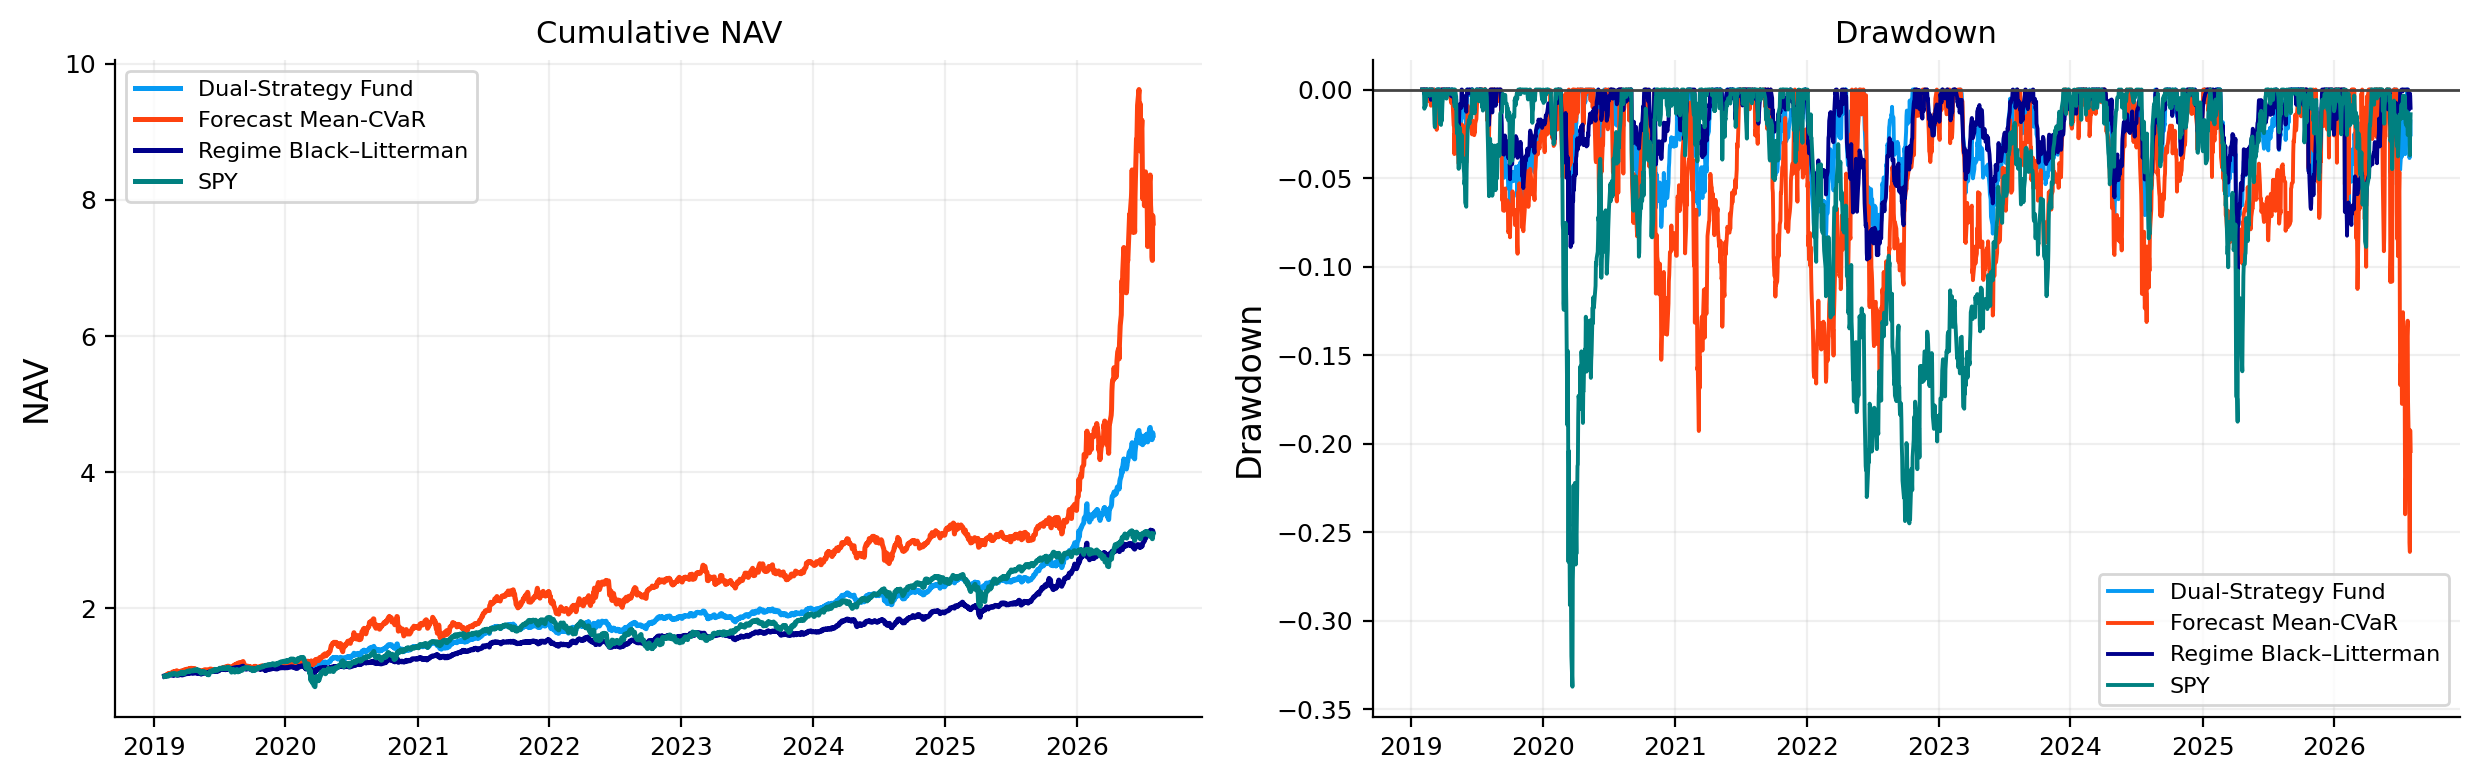

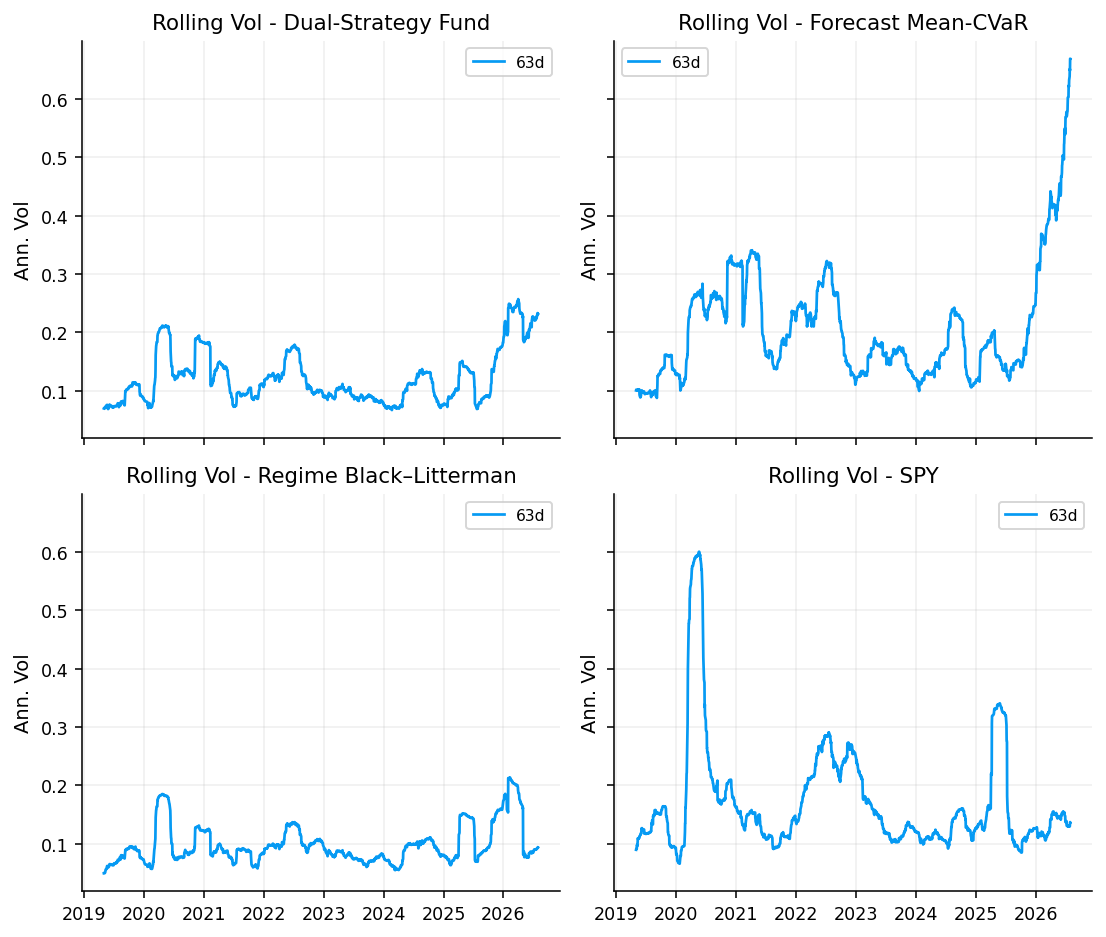

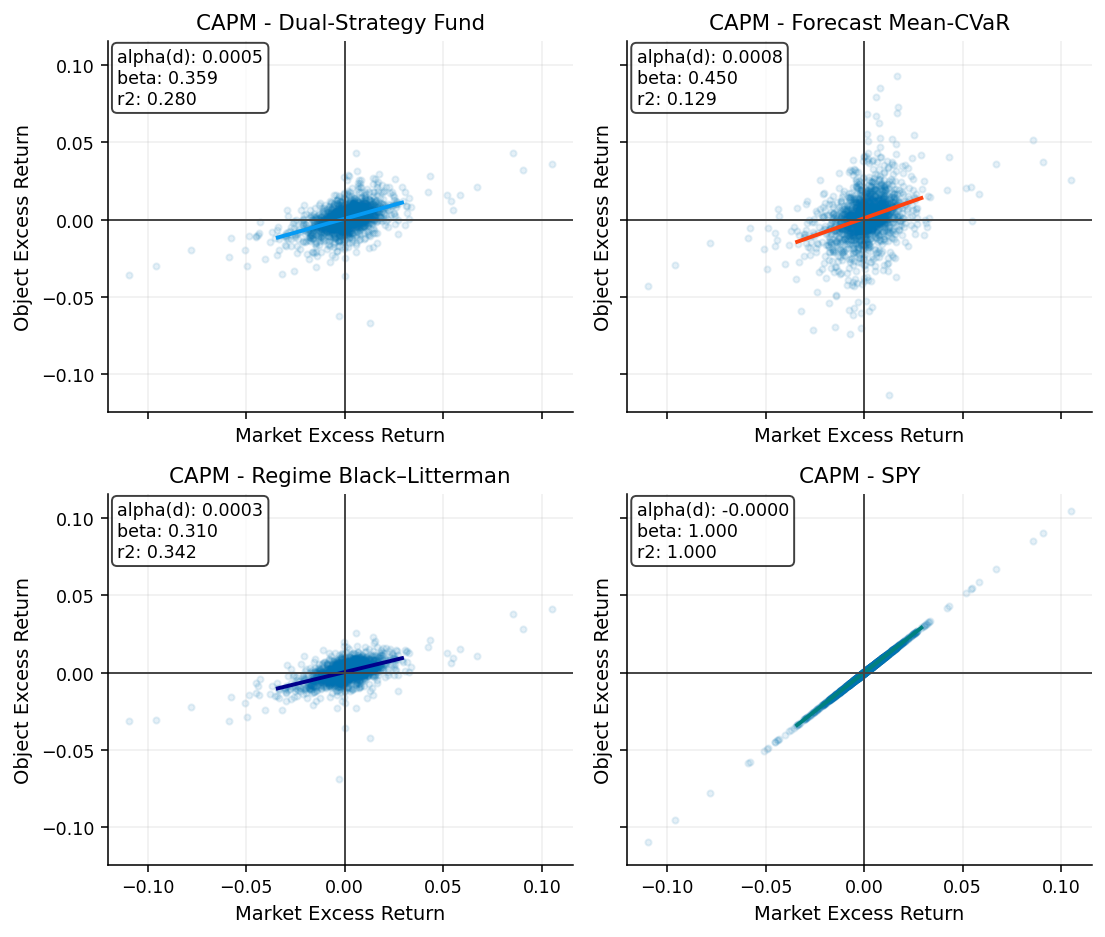

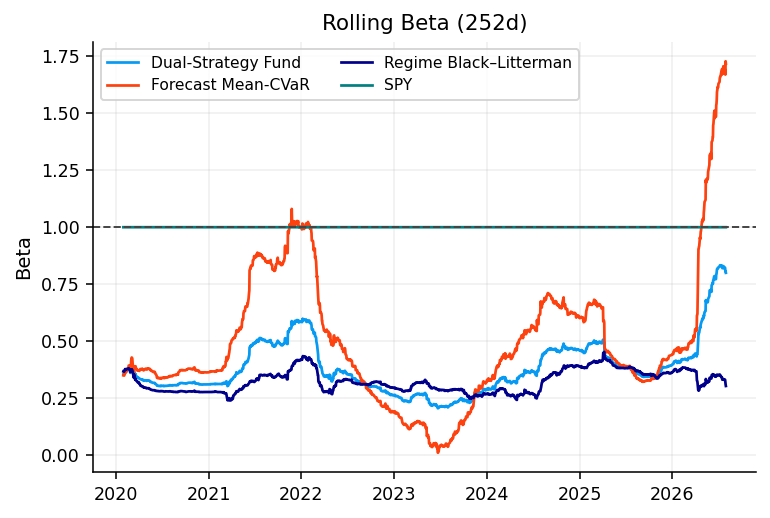

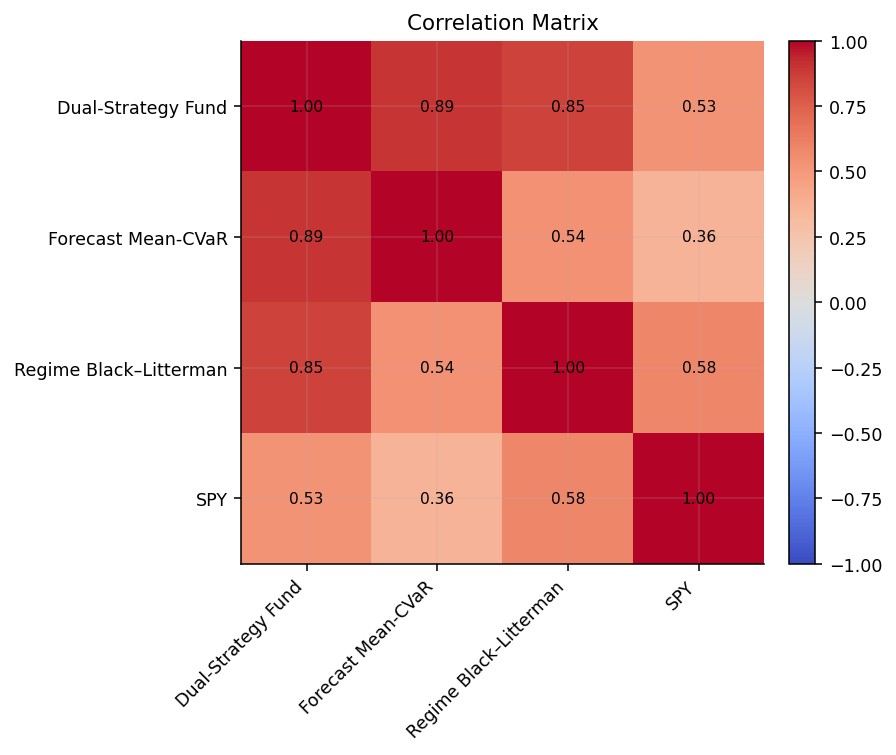

In [40]:
forecast_name = "Forecast Mean-CVaR"
regime_name = "Regime Black–Litterman"
fund_name = "Dual-Strategy Fund"
fixed_fund_name = "Fixed 50/50 Fund"

sleeve_returns = pd.concat(
    {
        forecast_name: strategy1_result.net_returns,
        regime_name: strategy2_result.net_returns,
    },
    axis=1,
).loc[research_start:research_end].dropna()
top_level_dates = strategy1_weights.index.intersection(strategy2_weights.index)


def sleeve_allocation_weights(
    returns: pd.DataFrame,
    dates: pd.DatetimeIndex,
    *,
    lookback_days: int,
    minimum_observations: int,
    weight_bounds: tuple[float, float],
) -> pd.DataFrame:
    rows = {}
    for date in pd.DatetimeIndex(dates):
        history = returns.loc[:date].tail(lookback_days).dropna()
        if len(history) < minimum_observations:
            weights = pd.Series(0.50, index=returns.columns)
        else:
            inverse_volatility = 1.0 / history.std(ddof=1).clip(lower=1e-06)
            weights = inverse_volatility / inverse_volatility.sum()
            weights = weights.clip(
                lower=weight_bounds[0],
                upper=weight_bounds[1],
            )
            weights = weights / weights.sum()
        rows[pd.Timestamp(date)] = weights
    output = pd.DataFrame.from_dict(rows, orient="index").sort_index()
    output.index = pd.DatetimeIndex(output.index, name="decision_date")
    return output


def sleeve_allocation_backtest(
    returns: pd.DataFrame,
    weights: pd.DataFrame,
):
    result = run_weights_backtest(
        returns=returns,
        weights=weights,
        cost_bps=trading_cost_bps,
        long_only=True,
        normalize=True,
        weight_timing="next_close",
    )
    adjusted_returns = result.net_returns.copy()
    if not adjusted_returns.empty:
        adjusted_returns.iloc[0] = float(result.net_values.iloc[0]) - 1.0
    return result, adjusted_returns


risk_parity_weights = sleeve_allocation_weights(
    sleeve_returns,
    top_level_dates,
    lookback_days=fund_lookback,
    minimum_observations=fund_minimum_observations,
    weight_bounds=fund_weight_bounds,
)
fixed_50_50_weights = pd.DataFrame(
    0.50,
    index=top_level_dates,
    columns=sleeve_returns.columns,
)
fixed_50_50_weights.index.name = "decision_date"
risk_parity_result, fund_returns = sleeve_allocation_backtest(
    sleeve_returns,
    risk_parity_weights,
)
fixed_50_50_result, fixed_50_50_returns = sleeve_allocation_backtest(
    sleeve_returns,
    fixed_50_50_weights,
)


def sleeve_risk_contributions(
    returns: pd.DataFrame,
    weights: pd.DataFrame,
    *,
    lookback_days: int,
    minimum_observations: int,
) -> pd.DataFrame:
    rows = {}
    for date, current_weights in weights.iterrows():
        history = returns.loc[:date].tail(lookback_days).dropna()
        if len(history) < minimum_observations:
            continue
        covariance_matrix = history.cov().to_numpy(dtype=float)
        vector = current_weights.reindex(returns.columns).to_numpy(dtype=float)
        variance = float(vector @ covariance_matrix @ vector)
        if variance <= 1e-12:
            continue
        rows[pd.Timestamp(date)] = vector * (covariance_matrix @ vector) / variance
    return pd.DataFrame.from_dict(
        rows,
        orient="index",
        columns=returns.columns,
    ).sort_index()


risk_parity_contributions = sleeve_risk_contributions(
    sleeve_returns,
    risk_parity_weights,
    lookback_days=fund_lookback,
    minimum_observations=fund_minimum_observations,
)
allocation_summary = pd.DataFrame(
    {
        "average weight": risk_parity_weights.mean(),
        "latest weight": risk_parity_weights.iloc[-1],
        "average risk contribution": risk_parity_contributions.mean(),
    }
)
display(
    allocation_summary.style.format("{:.2%}").set_caption(
        "252-day inverse-volatility sleeve allocation"
    )
)

primary_returns = pd.concat(
    {
        fund_name: fund_returns,
        forecast_name: strategy1_result.net_returns,
        regime_name: strategy2_result.net_returns,
        "SPY": inputs["etf_returns"]["SPY"],
    },
    axis=1,
    sort=False,
).sort_index().loc[research_start:research_end]
common_benchmark_returns = primary_returns.dropna(how="any")

primary_turnover = {
    fund_name: risk_parity_result.turnover,
    forecast_name: strategy1_result.turnover,
    regime_name: strategy2_result.turnover,
    "SPY": None,
}
primary_performance = pd.DataFrame({
    name: portfolio_summary(
        common_benchmark_returns[name],
        inputs["rf_daily"],
        primary_turnover[name],
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    )
    for name in common_benchmark_returns
}).T
display(
    primary_performance[performance_columns]
    .style.format(performance_format)
    .set_caption("2019–2026 primary portfolio comparison")
)

fixed_50_50_performance = portfolio_summary(
    fixed_50_50_returns,
    inputs["rf_daily"],
    fixed_50_50_result.turnover,
    research_start=research_start,
    research_end=research_end,
    annualization=annualization,
)
fund_allocation_performance = pd.DataFrame(
    {
        fund_name: primary_performance.loc[fund_name],
        fixed_fund_name: fixed_50_50_performance,
    }
).T
display(
    fund_allocation_performance[performance_columns]
    .style.format(performance_format)
    .set_caption("Risk-parity fund versus fixed 50/50 benchmark")
)

project21_comparison = pd.DataFrame({
    f"Project 21 {name}": portfolio_summary(
        project21_benchmark_returns[name],
        inputs["rf_daily"],
        research_start=research_start,
        research_end=research_end,
        annualization=annualization,
    )
    for name in ("MinVar", "NCO")
}).T
display(
    pd.concat(
        [primary_performance.loc[[fund_name]], project21_comparison],
        axis=0,
    )[performance_columns]
    .style.format(performance_format)
    .set_caption("Dual-Strategy Fund versus rebuilt Project 21 references")
)

risk_report_artifacts = risk_report(
    objects=common_benchmark_returns,
    market_ret=common_benchmark_returns["SPY"],
    rf_daily=inputs["rf_daily"].reindex(
        common_benchmark_returns.index
    ).fillna(0.0),
    include={
        "performance_tables": True,
        "shape_tables": True,
        "drawdowns": True,
        "rolling_vol": True,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": False,
        "stress": False,
        "capm": True,
        "rolling_beta": True,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    rolling_settings={"vol_windows": [63], "beta_windows": [252]},
    output={
        "display_tables": False,
        "show_figures": False,
        "print_exec_bullets": False,
        "short_labels": False,
    },
)
risk_report_table = pd.concat(
    {
        "Performance": risk_report_artifacts.tables["performance"],
        "Shape": risk_report_artifacts.tables["shape"],
        "Drawdown": risk_report_artifacts.tables["drawdown_summary"],
        "VaR and ES": risk_report_artifacts.tables["var_es"],
        "CAPM": risk_report_artifacts.tables["capm"],
    },
    axis=1,
)
display(
    risk_report_table.style.format("{:.3f}").set_caption(
        "QuantFinLab full-sample risk report"
    )
)
display(
    risk_report_artifacts.tables["corr"]
    .style.format("{:.3f}")
    .set_caption("Full-sample return correlations")
)

ytd_year = int(common_benchmark_returns.index.max().year)
ytd_performance_table = pd.DataFrame({
    name: ytd_summary(
        common_benchmark_returns[name],
        inputs["rf_daily"],
        ytd_year,
        annualization=annualization,
    )
    for name in common_benchmark_returns
}).T
ytd_format = {
    "YTD return": "{:.2%}",
    "annualized volatility": "{:.2%}",
    "annualized Sharpe": "{:.3f}",
    "maximum drawdown": "{:.2%}",
    "best day": "{:.2%}",
    "worst day": "{:.2%}",
    "positive days": "{:.2%}",
}
display(
    ytd_performance_table.style.format(ytd_format).set_caption(
        f"{ytd_year} YTD performance through "
        f"{common_benchmark_returns.index.max():%Y-%m-%d}"
    )
)


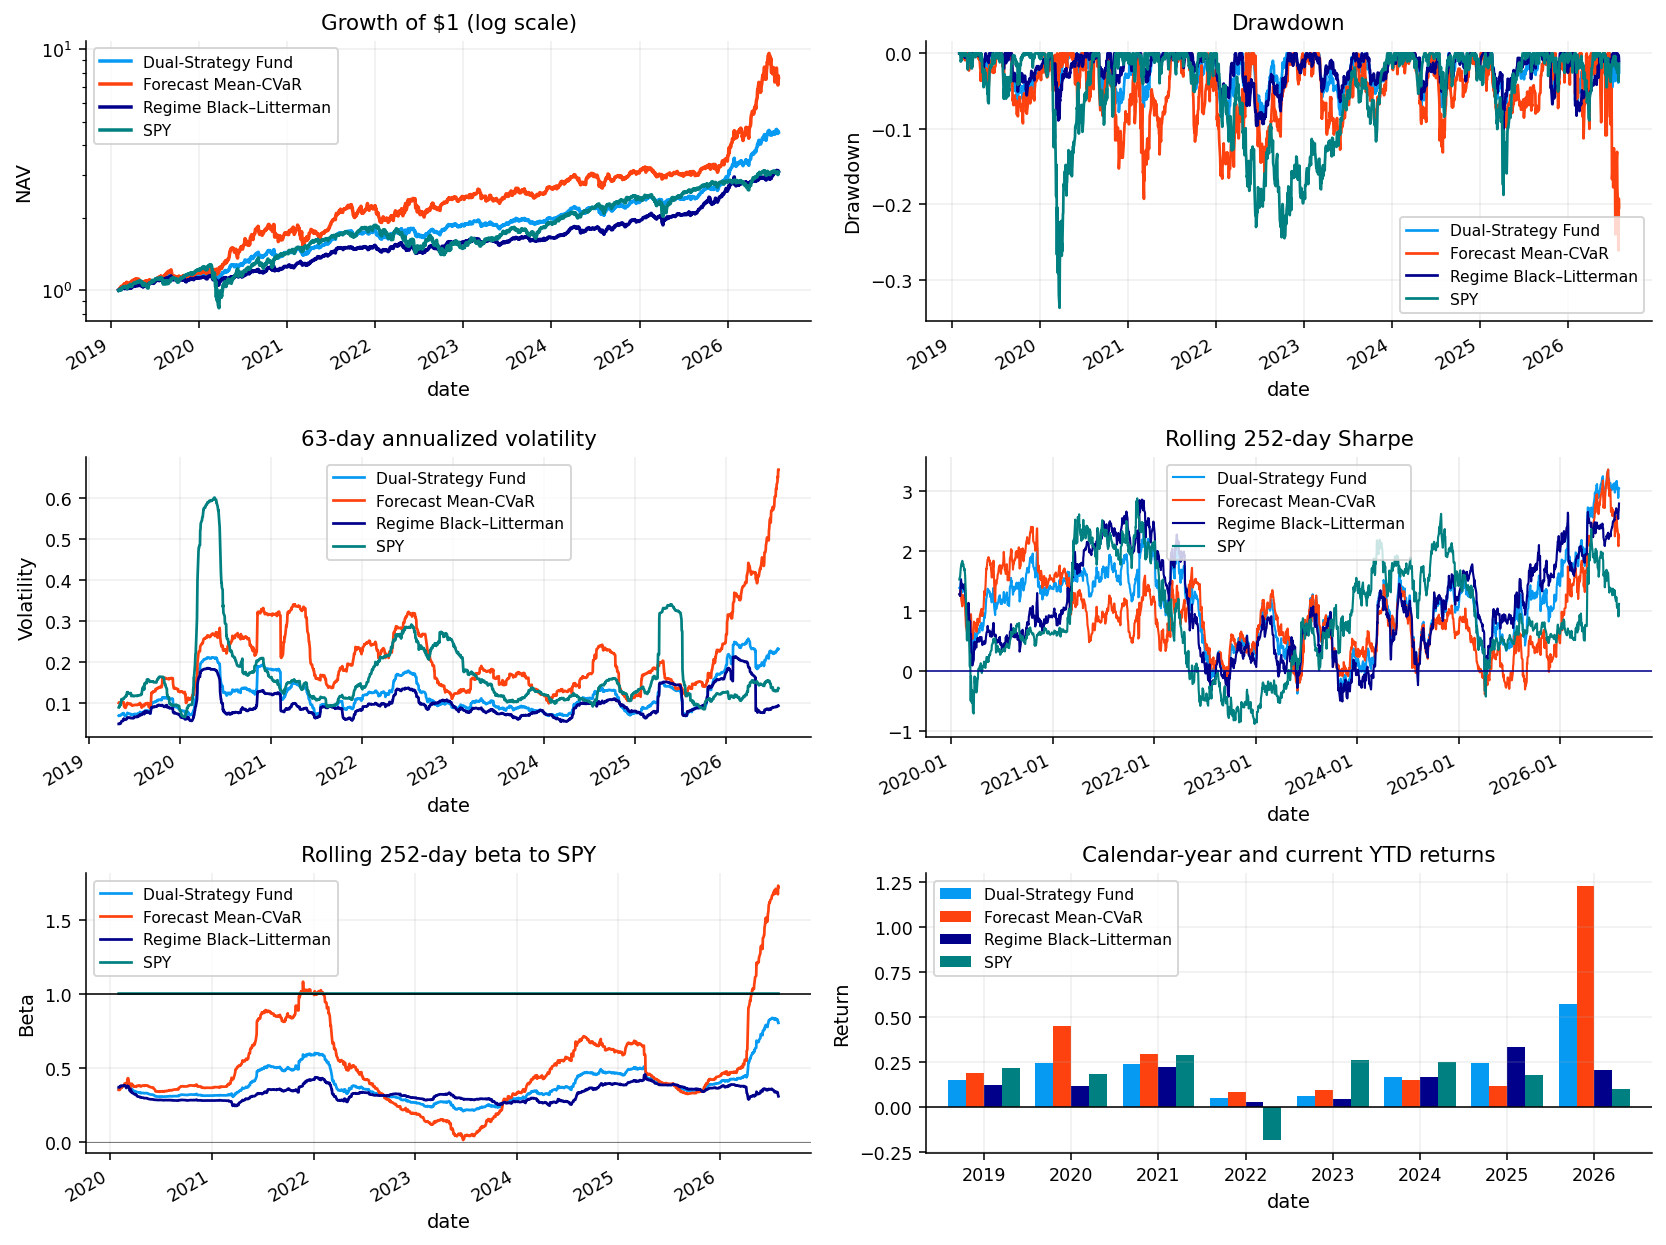

In [41]:
benchmark_nav = (1.0 + common_benchmark_returns).cumprod()
benchmark_drawdowns = benchmark_nav.apply(calc_drawdown)
rolling_volatility_table = library_rolling_volatility(common_benchmark_returns, windows=(63,), annualization=annualization).xs('vol_63', level=1, axis=1)
rolling_beta_table = pd.DataFrame({name: library_rolling_beta(common_benchmark_returns[name], common_benchmark_returns['SPY'], window=252) for name in common_benchmark_returns})
calendar_year_returns = (1.0 + common_benchmark_returns).groupby(common_benchmark_returns.index.year).prod().sub(1.0)
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
benchmark_nav.plot(ax=axes[0, 0], linewidth=1.8)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Growth of $1 (log scale)')
axes[0, 0].set_ylabel('NAV')
benchmark_drawdowns.plot(ax=axes[0, 1], linewidth=1.4)
axes[0, 1].set_title('Drawdown')
axes[0, 1].set_ylabel('Drawdown')
rolling_volatility_table.plot(ax=axes[1, 0], linewidth=1.4)
axes[1, 0].set_title('63-day annualized volatility')
axes[1, 0].set_ylabel('Volatility')
plot_rolling_sharpe(axes[1, 1], common_benchmark_returns, window=252, rf_daily=inputs['rf_daily'], title='Rolling 252-day Sharpe')
rolling_beta_table.plot(ax=axes[2, 0], linewidth=1.4)
axes[2, 0].axhline(1.0, color='black', linewidth=0.8)
axes[2, 0].axhline(0.0, color='black', linewidth=0.5, alpha=0.5)
axes[2, 0].set_title('Rolling 252-day beta to SPY')
axes[2, 0].set_ylabel('Beta')
calendar_year_returns.plot.bar(ax=axes[2, 1], width=0.82, edgecolor='none')
axes[2, 1].axhline(0.0, color='black', linewidth=0.8)
axes[2, 1].set_title('Calendar-year and current YTD returns')
axes[2, 1].set_ylabel('Return')
axes[2, 1].tick_params(axis='x', rotation=0)
for axis in axes.flat:
    handles, labels = axis.get_legend_handles_labels()
    if handles:
        axis.legend()
plt.tight_layout()
plt.show()


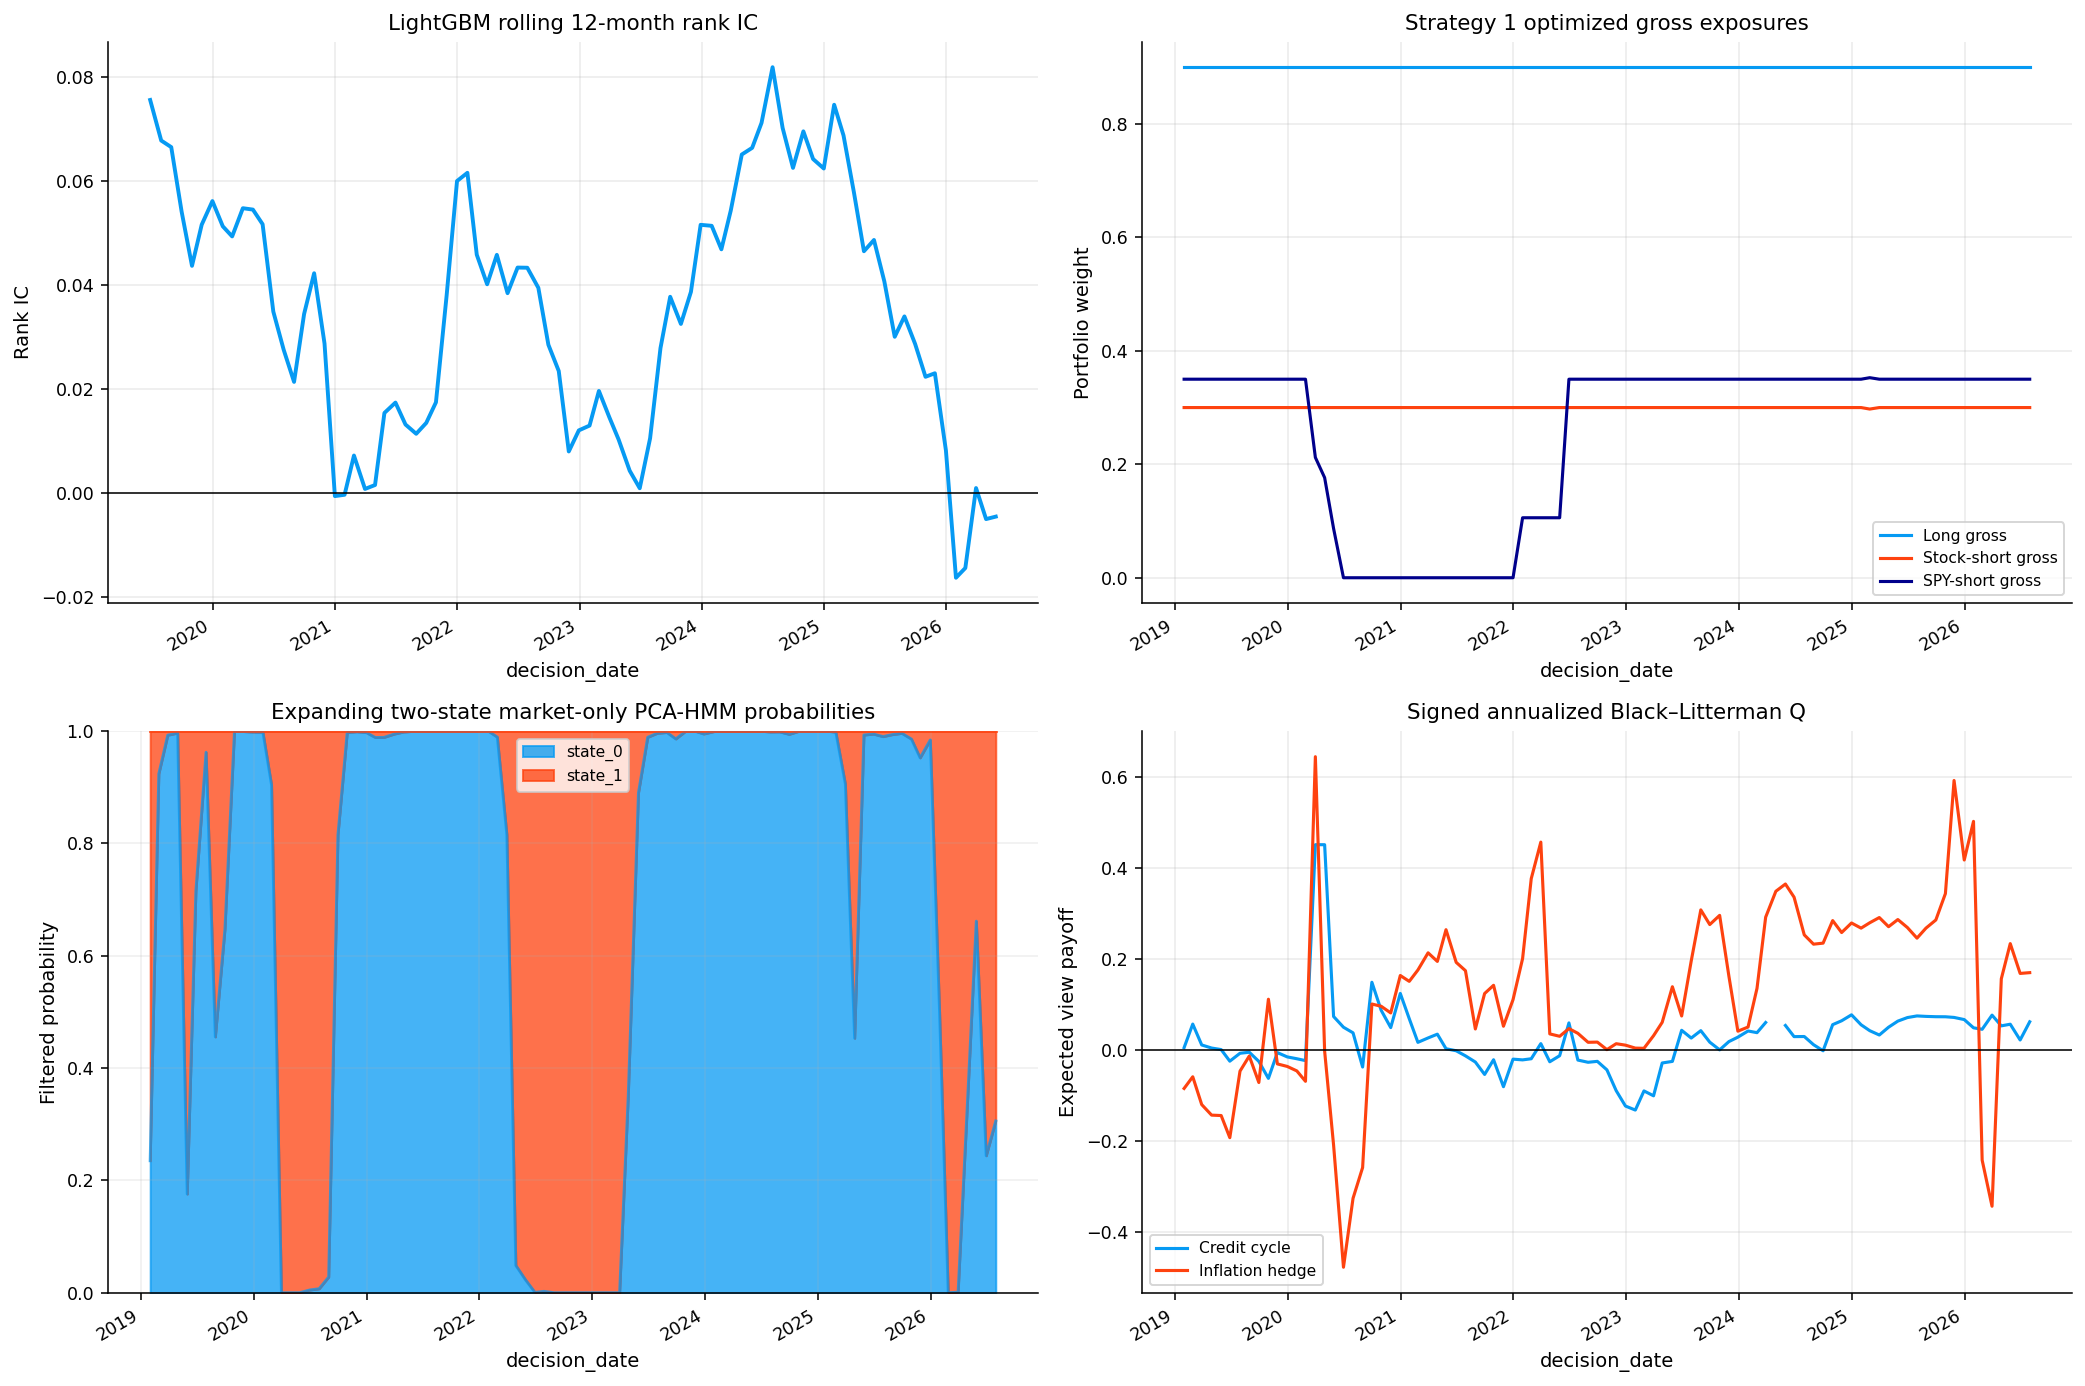

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
monthly_forecast_ic.rolling(12, min_periods=6).mean().plot(ax=axes[0, 0], color=palette[0], linewidth=2.0)
axes[0, 0].axhline(0.0, color='black', linewidth=0.8)
axes[0, 0].set_title('LightGBM rolling 12-month rank IC')
axes[0, 0].set_ylabel('Rank IC')
axes[0, 0].grid(alpha=0.25)
s1_exposures = strategy1_diagnostics.set_index('decision_date')[['long_gross', 'stock_short_gross', 'spy_short_gross']].rename(columns={'long_gross': 'Long gross', 'stock_short_gross': 'Stock-short gross', 'spy_short_gross': 'SPY-short gross'})
s1_exposures.plot(ax=axes[0, 1], linewidth=1.6)
axes[0, 1].set_title('Strategy 1 optimized gross exposures')
axes[0, 1].set_ylabel('Portfolio weight')
axes[0, 1].grid(alpha=0.25)
state_probabilities.set_index('decision_date')[['state_0', 'state_1']].loc[research_start:research_end].plot.area(ax=axes[1, 0], alpha=0.75)
axes[1, 0].set_title('Expanding two-state market-only PCA-HMM probabilities')
axes[1, 0].set_ylabel('Filtered probability')
axes[1, 0].set_ylim(0.0, 1.0)
q_plot = q_predictions.pivot_table(index='decision_date', columns='view_family', values='predicted_q', aggfunc='last').loc[research_start:research_end]
q_plot.rename(columns={family: specification['label'] for family, specification in selected_views.items()}).plot(ax=axes[1, 1], linewidth=1.6)
axes[1, 1].axhline(0.0, color='black', linewidth=0.8)
axes[1, 1].set_title('Signed annualized Black–Litterman Q')
axes[1, 1].set_ylabel('Expected view payoff')
axes[1, 1].grid(alpha=0.25)
for axis in axes.flat:
    handles, labels = axis.get_legend_handles_labels()
    if handles:
        axis.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Factor Attribution

,start,end,months,annual alpha,alpha HAC t-stat,R-squared,beta Mkt-RF,beta SMB,beta HML,beta RMW,beta CMA
portfolio,,,,,,,,,,,
Dual-Strategy Fund,2019-02-28,2026-04-30,87,11.94%,2.70,0.237,0.370,-0.080,-0.070,-0.063,0.170
Forecast Mean-CVaR,2019-02-28,2026-04-30,87,18.10%,2.32,0.154,0.510,-0.115,-0.272,-0.114,0.271
Regime Black–Litterman,2019-02-28,2026-04-30,87,8.29%,2.63,0.276,0.290,-0.069,0.042,-0.034,0.109
SPY,2019-02-28,2026-04-30,87,-0.13%,-0.40,0.996,0.983,-0.111,0.029,0.065,0.013


,alpha,Mkt-RF contribution,SMB contribution,HML contribution,RMW contribution,CMA contribution,fitted annual excess return,realized annual excess return
portfolio,,,,,,,,
Dual-Strategy Fund,11.94%,5.04%,0.21%,-0.06%,-0.24%,-0.01%,16.89%,16.89%
Forecast Mean-CVaR,18.10%,6.96%,0.30%,-0.24%,-0.44%,-0.01%,24.67%,24.67%
Regime Black–Litterman,8.29%,3.96%,0.18%,0.04%,-0.13%,-0.01%,12.34%,12.34%
SPY,-0.13%,13.41%,0.29%,0.03%,0.25%,-0.00%,13.84%,13.84%


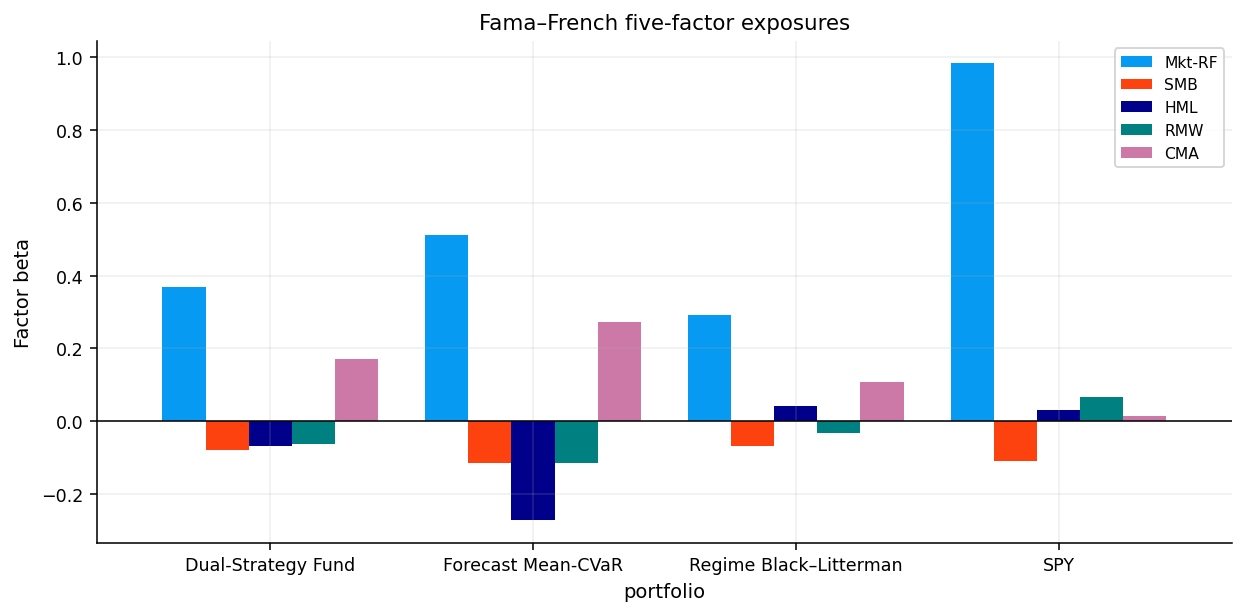

In [43]:
factor_data = (
    pd.read_csv(factor_path, parse_dates=["date"])
    .set_index("date")
    .sort_index()
)
factor_columns = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
factor_models = {}
factor_rows = []
attribution_rows = []
for portfolio_name in common_benchmark_returns.columns:
    monthly_returns = (
        (1.0 + common_benchmark_returns[portfolio_name])
        .resample("ME")
        .prod()
        .sub(1.0)
        .rename("portfolio")
    )
    factor_sample = factor_data.join(monthly_returns, how="inner").dropna()
    excess_returns = factor_sample["portfolio"] - factor_sample["RF"]
    design = sm.add_constant(
        factor_sample[factor_columns],
        has_constant="add",
    )
    model = sm.OLS(excess_returns, design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3},
    )
    factor_models[portfolio_name] = model
    exposure_row = {
        "portfolio": portfolio_name,
        "start": factor_sample.index.min(),
        "end": factor_sample.index.max(),
        "months": len(factor_sample),
        "annual alpha": float(model.params["const"] * 12.0),
        "alpha HAC t-stat": float(model.tvalues["const"]),
        "R-squared": float(model.rsquared),
    }
    exposure_row.update(
        {
            f"beta {factor}": float(model.params[factor])
            for factor in factor_columns
        }
    )
    factor_rows.append(exposure_row)
    annual_factor_premia = factor_sample[factor_columns].mean() * 12.0
    contributions = model.params.reindex(factor_columns) * annual_factor_premia
    attribution_row = {
        "portfolio": portfolio_name,
        "alpha": float(model.params["const"] * 12.0),
        **{
            f"{factor} contribution": float(contributions[factor])
            for factor in factor_columns
        },
        "fitted annual excess return": float(
            model.params["const"] * 12.0 + contributions.sum()
        ),
        "realized annual excess return": float(excess_returns.mean() * 12.0),
    }
    attribution_rows.append(attribution_row)

factor_exposure_table = pd.DataFrame(factor_rows).set_index("portfolio")
factor_attribution_table = pd.DataFrame(attribution_rows).set_index("portfolio")
factor_window_start = factor_exposure_table["start"].max()
factor_window_end = factor_exposure_table["end"].min()
display(
    factor_exposure_table.style.format(
        {
            "start": lambda value: f"{value:%Y-%m-%d}",
            "end": lambda value: f"{value:%Y-%m-%d}",
            "annual alpha": "{:.2%}",
            "alpha HAC t-stat": "{:.2f}",
            "R-squared": "{:.3f}",
            **{f"beta {factor}": "{:.3f}" for factor in factor_columns},
        }
    ).set_caption(
        f"Fama–French five-factor exposures, "
        f"{factor_window_start:%Y-%m} to {factor_window_end:%Y-%m}"
    )
)
display(
    factor_attribution_table.style.format("{:.2%}").set_caption(
        "Arithmetic annualized five-factor return attribution"
    )
)

factor_beta_columns = [f"beta {factor}" for factor in factor_columns]
factor_exposure_table[factor_beta_columns].rename(
    columns=lambda name: name.removeprefix("beta ")
).plot.bar(figsize=(9, 4.5), width=0.82, edgecolor="none")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Fama–French five-factor exposures")
plt.ylabel("Factor beta")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [44]:
strategy2_full_metrics = strategy2_metric_rows[
    "Regime Black–Litterman"
]
strategy2_no_regime_metrics = strategy2_metric_rows["No regime Q"]
strategy2_no_view_metrics = strategy2_metric_rows["No views"]
fund_metrics = primary_performance.loc[fund_name]
fixed_fund_metrics = fund_allocation_performance.loc[fixed_fund_name]
final_executed_summary = pd.DataFrame([
    {"result": "Forecast Mean-CVaR Sharpe", "value": s1_full_metrics["sharpe"]},
    {
        "result": "Forecast Sharpe lift",
        "value": s1_full_metrics["sharpe"] - s1_neutral_metrics["sharpe"],
    },
    {
        "result": "Forecast / neutral weight distance",
        "value": forecast_weight_distances.mean(),
    },
    {
        "result": "Regime Black–Litterman Sharpe",
        "value": strategy2_full_metrics["sharpe"],
    },
    {
        "result": "Regime Sharpe lift",
        "value": (
            strategy2_full_metrics["sharpe"]
            - strategy2_no_regime_metrics["sharpe"]
        ),
    },
    {
        "result": "View Sharpe lift",
        "value": (
            strategy2_full_metrics["sharpe"]
            - strategy2_no_view_metrics["sharpe"]
        ),
    },
    {"result": "Dual-Strategy Fund Sharpe", "value": fund_metrics["sharpe"]},
    {
        "result": "Risk-parity Sharpe lift over 50/50",
        "value": fund_metrics["sharpe"] - fixed_fund_metrics["sharpe"],
    },
    {
        "result": "Average Forecast Mean-CVaR fund weight",
        "value": allocation_summary.loc[forecast_name, "average weight"],
    },
    {
        "result": "Average Forecast Mean-CVaR risk contribution",
        "value": allocation_summary.loc[
            forecast_name,
            "average risk contribution",
        ],
    },
    {
        "result": "Dual-Strategy Fund 2019–2022 Sharpe",
        "value": fund_metrics["2019–2022 sharpe"],
    },
    {
        "result": "Dual-Strategy Fund 2023–2026 Sharpe",
        "value": fund_metrics["2023–2026 sharpe"],
    },
    {
        "result": "Dual-Strategy Fund maximum drawdown",
        "value": fund_metrics["max_drawdown"],
    },
    {
        "result": f"Dual-Strategy Fund {ytd_year} YTD return",
        "value": ytd_performance_table.loc[fund_name, "YTD return"],
    },
    {
        "result": "Dual-Strategy Fund five-factor annual alpha",
        "value": factor_exposure_table.loc[fund_name, "annual alpha"],
    },
    {
        "result": "Dual-Strategy Fund market beta",
        "value": factor_exposure_table.loc[fund_name, "beta Mkt-RF"],
    },
]).set_index("result")
display(
    final_executed_summary.style.format("{:.4f}").set_caption(
        "Final executed results"
    )
)


,value
result,
Forecast Mean-CVaR Sharpe,1.1263
Forecast Sharpe lift,0.3211
Forecast / neutral weight distance,0.4534
Regime Black–Litterman Sharpe,1.2561
Regime Sharpe lift,0.1408
View Sharpe lift,0.1988
Dual-Strategy Fund Sharpe,1.3929
Risk-parity Sharpe lift over 50/50,0.0921
Average Forecast Mean-CVaR fund weight,0.3436


## Live portfolio targets


In [45]:
from datetime import datetime, timezone
live_target_directory = root / "workspace" / "project22_live_targets"
live_target_directory.mkdir(parents=True, exist_ok=True)
live_dates = strategy1_weights.index.intersection(strategy2_weights.index)
live_assets = strategy1_weights.columns.union(strategy2_weights.columns)
live_strategy1 = strategy1_weights.reindex(
    index=live_dates,
    columns=live_assets,
    fill_value=0.0,
)
live_strategy2 = strategy2_weights.reindex(
    index=live_dates,
    columns=live_assets,
    fill_value=0.0,
)
live_sleeve_weights = risk_parity_weights.reindex(live_dates)
if live_sleeve_weights.isna().any().any():
    raise AssertionError("risk-parity live sleeve weights are incomplete")
live_fund = (
    live_strategy1.mul(live_sleeve_weights[forecast_name], axis=0)
    + live_strategy2.mul(live_sleeve_weights[regime_name], axis=0)
)
live_histories = {
    "strategy1": live_strategy1,
    "strategy2": live_strategy2,
    "fund": live_fund,
}
for portfolio_name, history in live_histories.items():
    if history.empty or not np.isfinite(history.to_numpy(dtype=float)).all():
        raise AssertionError(f"invalid {portfolio_name} live history")
    if not np.allclose(history.sum(axis=1), 1.0, atol=2e-05):
        raise AssertionError(f"{portfolio_name} live weights do not net to one")
    destination = live_target_directory / f"{portfolio_name}_weights.parquet"
    temporary = destination.with_suffix(".tmp.parquet")
    history.to_parquet(temporary)
    temporary.replace(destination)
manifest = {
    "schema_version": 1,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "research_start": str(pd.Timestamp(research_start).date()),
    "research_end": str(pd.Timestamp(research_end).date()),
    "source_data_end": str(pd.Timestamp(common_data_end).date()),
    "latest_decision_date": str(pd.Timestamp(live_dates.max()).date()),
    "fund_allocator": {
        "method": "inverse_volatility_risk_parity",
        "lookback_trading_days": fund_lookback,
        "minimum_observations": fund_minimum_observations,
        "weight_bounds": list(fund_weight_bounds),
        "latest_sleeve_weights": {
            name: float(value)
            for name, value in live_sleeve_weights.iloc[-1].items()
        },
    },
    "portfolios": {
        name: {
            "months": int(len(history)),
            "latest_net": float(history.iloc[-1].sum()),
            "latest_gross": float(history.iloc[-1].abs().sum()),
            "latest_active_assets": int(
                history.iloc[-1].abs().gt(1e-06).sum()
            ),
        }
        for name, history in live_histories.items()
    },
}
manifest_path = live_target_directory / "manifest.json"
manifest_temporary = manifest_path.with_suffix(".tmp.json")
manifest_temporary.write_text(
    json.dumps(manifest, indent=2, sort_keys=True),
    encoding="utf-8",
)
manifest_temporary.replace(manifest_path)
display(
    pd.DataFrame(
        {
            name: {
                "decision date": history.index.max().date(),
                "net": history.iloc[-1].sum(),
                "gross": history.iloc[-1].abs().sum(),
                "active assets": history.iloc[-1].abs().gt(1e-06).sum(),
            }
            for name, history in live_histories.items()
        }
    ).T
)
display(
    live_sleeve_weights.tail(12).style.format("{:.2%}").set_caption(
        "Latest 12 monthly fund sleeve weights"
    )
)


,decision date,net,gross,active assets
strategy1,2026-07-31,1.0,2.3,23
strategy2,2026-07-31,1.0,1.0,19
fund,2026-07-31,1.0,1.325,27


,Forecast Mean-CVaR,Regime Black–Litterman
2025-08-29 00:00:00,40.78%,59.22%
2025-09-30 00:00:00,40.94%,59.06%
2025-10-31 00:00:00,42.48%,57.52%
2025-11-28 00:00:00,40.52%,59.48%
2025-12-31 00:00:00,41.06%,58.94%
2026-01-30 00:00:00,41.02%,58.98%
2026-02-27 00:00:00,39.54%,60.46%
2026-03-31 00:00:00,36.52%,63.48%
2026-04-30 00:00:00,32.75%,67.25%
2026-05-29 00:00:00,30.60%,69.40%
